# Prédiction de la consommation énergétique et des émissions de CO₂ des bâtiments non résidentiels de Seattle

## 1. Contexte du projet

La ville de Seattle met à disposition des données de benchmarking énergétique sur les bâtiments.  
L’objectif de ce projet est d’exploiter ces données afin de mieux comprendre et prédire :

- la consommation énergétique totale des bâtiments,
- les émissions totales de CO₂ associées.

L’étude porte uniquement sur les **bâtiments non résidentiels**, conformément à l’énoncé du projet.

## 2. Objectif du notebook

L’objectif de ce notebook est de construire une démarche complète de data science pour prédire deux variables cibles :

- `SiteEnergyUse(kBtu)` : consommation énergétique totale,
- `TotalGHGEmissions` : émissions totales de CO₂.

Pour cela, nous allons :

1. charger et comprendre les données ;
2. nettoyer le dataset et définir le bon périmètre d’étude ;
3. analyser les variables et leurs relations ;
4. créer de nouvelles variables pertinentes ;
5. comparer plusieurs modèles de régression ;
6. tester également un modèle **multi-output** capable de prédire les deux cibles simultanément ;
7. interpréter les résultats obtenus.

## 3. Nature du problème

Il s’agit d’un problème de **régression supervisée**.

- **Régression**, car les deux cibles à prédire sont des variables numériques continues.
- **Supervisée**, car les valeurs réelles des cibles sont déjà présentes dans le jeu de données, ce qui permet d’entraîner et d’évaluer des modèles.

Même si les deux cibles sont liées, elles ne représentent pas exactement le même phénomène.  
Nous adopterons donc une double démarche :

- une approche **cible par cible** pour comparer précisément les performances,
- une approche **multi-output** pour tester un modèle unique prédisant l’énergie et le CO₂ en même temps.

## 4. Organisation de l’analyse

Le notebook est organisé selon les grandes étapes suivantes :

1. chargement et inspection des données ;
2. nettoyage et filtrage du périmètre ;
3. analyse exploratoire des variables ;
4. étude des relations entre variables et entre les deux cibles ;
5. feature engineering ;
6. préparation des données pour la modélisation ;
7. comparaison de modèles mono-sortie ;
8. test d’un modèle multi-output ;
9. interprétation et conclusion.

## 5. Import des bibliothèques

Nous commençons par importer les bibliothèques nécessaires pour :

- manipuler les données ;
- visualiser les distributions et relations entre variables ;
- préparer les données pour la modélisation ;
- entraîner et évaluer plusieurs modèles de régression ;
- interpréter les résultats.

In [110]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from folium import Map
from folium.plugins import HeatMap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.inspection import permutation_importance
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Analyse Exploratoire

## 6. Chargement du jeu de données

Nous chargeons maintenant le jeu de données de benchmarking énergétique de Seattle.

L’objectif de cette étape est de :

- vérifier que les données sont bien accessibles ;
- observer la taille du dataset ;
- visualiser les premières lignes ;
- identifier les types de variables et la présence éventuelle de valeurs manquantes.

In [111]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

building_consumption.shape

(3376, 46)

**Interprétation :**

La commande `shape` permet de connaître la dimension brute du dataset.

- Le nombre de lignes correspond au nombre de bâtiments observés.
- Le nombre de colonnes correspond au nombre de variables disponibles.

Le dataset contient 3376 observations et 46 variables. Chaque ligne correspond à un bâtiment, et chaque colonne correspond à une caractéristique ou une mesure liée à ce bâtiment.

Cette information est importante pour suivre ensuite l’impact des différentes étapes de nettoyage et de filtrage.

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


**Interprétation :**

L’affichage des premières lignes permet de comprendre concrètement la structure d’une observation.

On voit que chaque ligne correspond à un bâtiment, décrit par :

- des informations générales (`BuildingType`, `PrimaryPropertyType`) ;
- des variables de surface (`PropertyGFATotal`, `PropertyGFAParking`) ;
- des informations structurelles (`YearBuilt`, `NumberofFloors`) ;
- des informations géographiques (`Neighborhood`, `Latitude`, `Longitude`) ;
- des variables cibles comme la consommation énergétique et les émissions de CO₂.

In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

**Interprétation :**

La méthode `info()` permet d’identifier :

- le type de chaque variable ;
- le nombre de valeurs non nulles ;
- la présence de variables numériques et catégorielles.

Cette étape est essentielle pour préparer la suite :

- les variables numériques seront étudiées par des statistiques, histogrammes et corrélations ;
- les variables catégorielles nécessiteront un encodage spécifique avant la modélisation ;
- les colonnes avec valeurs manquantes devront être traitées avec attention.

In [5]:
building_consumption.columns.tolist()

['OSEBuildingID',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'PropertyName',
 'Address',
 'City',
 'State',
 'ZipCode',
 'TaxParcelIdentificationNumber',
 'CouncilDistrictCode',
 'Neighborhood',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'Comments',
 'ComplianceStatus',
 'Outlier',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

**Interprétation :**

La liste des colonnes permet de repérer rapidement :

- les variables explicatives disponibles ;
- les deux variables cibles ;
- les colonnes de qualité des données (`DefaultData`, `ComplianceStatus`, `Outlier`) ;
- les colonnes potentiellement sensibles au data leakage, qui devront être examinées avec prudence.

## 7. Analyse initiale des deux variables cibles

Ici, on commence à étudier les deux sorties du problème :

- **SiteEnergyUse(kBtu)** pour la consommation énergétique,
- **TotalGHGEmissions** pour les émissions de CO₂.

L’objectif de cette étape est de répondre à plusieurs questions :

- les deux cibles sont-elles complètes ?
- leurs distributions semblent-elles équilibrées ou asymétriques ?
- y a-t-il déjà des valeurs incohérentes ou suspectes ?
- faut-il prévoir un nettoyage ou une transformation ?

## 7.1. Analyse descriptive de SiteEnergyUse(kBtu)

In [6]:
building_consumption["SiteEnergyUse(kBtu)"].describe()

count    3.371000e+03
mean     5.403667e+06
std      2.161063e+07
min      0.000000e+00
25%      9.251286e+05
50%      1.803753e+06
75%      4.222455e+06
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64

L’analyse descriptive de `SiteEnergyUse(kBtu)` montre une distribution très asymétrique, avec quelques bâtiments très énergivores. On observe aussi quelques valeurs manquantes et des valeurs nulles, ce qui indique qu’un nettoyage sera nécessaire avant la modélisation.

## 7.2. Analyse descriptive de TotalGHGEmissions

In [7]:
building_consumption["TotalGHGEmissions"].describe()

count     3367.000000
mean       119.723971
std        538.832227
min         -0.800000
25%          9.495000
50%         33.920000
75%         93.940000
max      16870.980000
Name: TotalGHGEmissions, dtype: float64

La variable `TotalGHGEmissions` est elle aussi très asymétrique, avec des valeurs extrêmes importantes. On note en plus une valeur négative incohérente, ce qui confirme la nécessité d’un nettoyage spécifique sur cette cible.

## 7.3. Vérification des plus petites valeurs de SiteEnergyUse(kBtu)

In [8]:
building_consumption["SiteEnergyUse(kBtu)"].sort_values().head(10)

760     0.0
1894    0.0
95      0.0
85      0.0
614     0.0
133     0.0
746     0.0
139     0.0
1361    0.0
152     0.0
Name: SiteEnergyUse(kBtu), dtype: float64

Cela confirme que la cible `SiteEnergyUse(kBtu)` contient plusieurs consommations nulles.

Dans le cadre de bâtiments non résidentiels, ces zéros sont très suspects, car un bâtiment actif consomme normalement de l’énergie.

Il faudra donc :

- quantifier combien il y en a,
- vérifier leur proportion,
- puis décider s’il faut les supprimer.

## 7.4. Vérification des plus petites valeurs de TotalGHGEmissions

In [9]:
building_consumption["TotalGHGEmissions"].sort_values().head(10)

3206   -0.8
28      0.0
304     0.0
513     0.0
1549    0.0
746     0.0
760     0.0
1323    0.0
1361    0.0
152     0.0
Name: TotalGHGEmissions, dtype: float64

Cette sortie confirme deux problèmes :

**1. Une valeur négative**

La valeur -0.8 est incohérente pour une émission de CO₂.

**2. Plusieurs valeurs nulles**

Les zéros peuvent être réels dans des cas très particuliers, mais ici ils doivent être examinés avec prudence, surtout si la consommation énergétique n’est pas nulle.

Cette cible nécessitera donc un nettoyage plus délicat que la première.

**Conclusion intermédiaire :**

L’analyse descriptive des deux variables cibles montre qu’elles sont toutes les deux très asymétriques et contiennent des valeurs extrêmes.  
On observe en outre :

- des valeurs nulles pour `SiteEnergyUse(kBtu)` ;
- des valeurs nulles et une valeur négative pour `TotalGHGEmissions`.

Ces résultats justifient une étape de nettoyage spécifique sur les deux cibles avant toute modélisation.

## 7.6. Quantification des valeurs incohérentes dans les deux cibles

À cette étape, on ne se contente plus d’observer quelques valeurs suspectes :
on cherche à mesurer précisément leur présence dans les deux variables cibles.

L’objectif est de répondre aux questions suivantes :

- combien de consommations énergétiques nulles contient le dataset ?
- combien d’émissions de CO₂ nulles contient-il ?
- combien de valeurs négatives apparaissent dans TotalGHGEmissions ?
- quelle proportion ces observations représentent-elles ?

Cette quantification est importante car elle permet de décider si ces lignes doivent être supprimées ou non, tout en évaluant l’impact de ce choix sur la taille du dataset.

In [10]:
(building_consumption["SiteEnergyUse(kBtu)"] == 0).sum()

np.int64(18)

In [11]:
(building_consumption["SiteEnergyUse(kBtu)"] == 0).mean()

np.float64(0.00533175355450237)

In [12]:
(building_consumption["TotalGHGEmissions"] == 0).sum()

np.int64(9)

In [13]:
(building_consumption["TotalGHGEmissions"] == 0).mean()

np.float64(0.002665876777251185)

In [14]:
(building_consumption["TotalGHGEmissions"] < 0).sum()

np.int64(1)

In [15]:
(building_consumption["TotalGHGEmissions"] < 0).mean()

np.float64(0.0002962085308056872)

**Interprétation :**

La quantification des valeurs incohérentes montre que :

- `SiteEnergyUse(kBtu)` contient **18 valeurs nulles**, soit environ **0.53 %** du dataset ;
- `TotalGHGEmissions` contient **9 valeurs nulles**, soit environ **0.27 %** du dataset ;
- `TotalGHGEmissions` contient également **1 valeur négative**, soit environ **0.03 %** du dataset.

Ces observations restent très minoritaires, ce qui signifie qu’un éventuel filtrage n’aura qu’un impact limité sur la taille du jeu de données.

D’un point de vue métier, une consommation énergétique nulle pour un bâtiment non résidentiel paraît peu réaliste, et une émission négative de CO₂ est incohérente dans ce contexte.  
Ces résultats justifient donc une étape de nettoyage spécifique sur les deux variables cibles avant la modélisation.

## 7.7. Nettoyage des deux variables cibles

L’analyse précédente a montré la présence de quelques valeurs incohérentes dans les cibles :

- des consommations énergétiques nulles dans `SiteEnergyUse(kBtu)` ;
- une valeur négative dans `TotalGHGEmissions` ;
- ainsi que plusieurs valeurs nulles dans `TotalGHGEmissions`.

Dans cette étape, nous choisissons de supprimer :

- les observations dont la consommation énergétique est inférieure ou égale à 0 ;
- les observations dont les émissions de CO₂ sont strictement négatives.

Ces observations étant très peu nombreuses, leur suppression ne modifie pas significativement la taille du dataset, tout en améliorant la cohérence des cibles pour la modélisation.

In [16]:
n_before_targets = building_consumption.shape[0]

building_consumption = building_consumption[
    (building_consumption["SiteEnergyUse(kBtu)"] > 0) &
    (building_consumption["TotalGHGEmissions"] >= 0)
].copy()

n_after_targets = building_consumption.shape[0]
n_removed_targets = n_before_targets - n_after_targets

print("Nombre de lignes avant nettoyage des cibles :", n_before_targets)
print("Nombre de lignes après nettoyage des cibles :", n_after_targets)
print("Nombre de lignes supprimées :", n_removed_targets)

Nombre de lignes avant nettoyage des cibles : 3376
Nombre de lignes après nettoyage des cibles : 3348
Nombre de lignes supprimées : 28


**Interprétation :**

Le nettoyage des deux variables cibles réduit le dataset de **3376 à 3348 lignes**, soit une suppression de **28 observations** (environ **0.83 %** du dataset).

Cette perte reste très faible, ce qui signifie que le nettoyage améliore la cohérence des cibles sans compromettre le volume de données disponible pour la suite.

On obtient ainsi un dataset plus propre, dans lequel :

- `SiteEnergyUse(kBtu)` est strictement positive ;
- `TotalGHGEmissions` ne contient plus de valeur négative.

Cette étape constitue donc un nettoyage raisonnable et justifié avant de poursuivre l’analyse.

## 8. Définition du périmètre non résidentiel

Après le nettoyage des variables cibles, il faut maintenant vérifier que le dataset correspond bien au périmètre métier du projet.

L’énoncé porte sur les bâtiments non résidentiels.
Il est donc nécessaire d’examiner la variable BuildingType afin de voir :

- quelles grandes catégories de bâtiments sont présentes ;
- si le dataset contient encore des bâtiments résidentiels ;
- quelles catégories doivent être conservées pour rester cohérent avec l’objectif du projet.

Pour affiner cette analyse, on regarde aussi la relation entre :

`BuildingType`
`PrimaryPropertyType`

Cela permet de mieux comprendre la composition réelle du dataset et d’identifier les usages dominants dans chaque grande catégorie de bâtiment.

## 8.1. Répartition des grandes catégories de bâtiments

In [17]:
building_consumption["BuildingType"].value_counts(dropna=False)

BuildingType
NonResidential          1455
Multifamily LR (1-4)    1009
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
Nonresidential COS        85
SPS-District K-12         84
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

**Interprétation :**

La variable `BuildingType` montre que le dataset contient à la fois :

- des bâtiments non résidentiels ;
- des bâtiments résidentiels de type multifamilial.

Les catégories `Multifamily LR (1-4)`, `Multifamily MR (5-9)` et `Multifamily HR (10+)` correspondent à des bâtiments résidentiels collectifs, qui ne relèvent pas du périmètre de l’étude.

À l’inverse, les catégories `NonResidential`, `Nonresidential COS`, `SPS-District K-12`, `Campus` et `Nonresidential WA` correspondent à des bâtiments non résidentiels ou institutionnels, cohérents avec l’objectif du projet.

Cette analyse justifie donc un filtrage du dataset afin de ne conserver que les catégories non résidentielles.

In [18]:
building_consumption[["BuildingType", "PrimaryPropertyType"]].value_counts().head(20)

BuildingType          PrimaryPropertyType        
Multifamily LR (1-4)  Low-Rise Multifamily           976
Multifamily MR (5-9)  Mid-Rise Multifamily           563
NonResidential        Small- and Mid-Sized Office    286
                      Other                          183
                      Warehouse                      180
                      Large Office                   168
Multifamily HR (10+)  High-Rise Multifamily          105
NonResidential        Mixed Use Property             101
                      Retail Store                    91
SPS-District K-12     K-12 School                     82
NonResidential        Hotel                           76
                      Worship Facility                71
Nonresidential COS    Other                           56
NonResidential        Distribution Center             51
                      Supermarket / Grocery Store     40
                      K-12 School                     39
                      Medical Office  

**Interprétation :**

L’analyse croisée entre `BuildingType` et `PrimaryPropertyType` confirme que les catégories multifamiliales correspondent à des usages résidentiels (`Low-Rise`, `Mid-Rise`, `High-Rise Multifamily`) et doivent donc être exclues du périmètre de l’étude.

À l’inverse, la catégorie `NonResidential` regroupe des usages variés mais cohérents avec le projet : bureaux, entrepôts, commerces, hôtels, établissements scolaires ou encore lieux de culte.

Cette analyse permet donc de confirmer que `BuildingType` doit être utilisé pour filtrer le périmètre, tandis que `PrimaryPropertyType` pourra être conservé comme variable explicative pour la suite.

**Conclusion intermédiaire :**

L’analyse de `BuildingType` et de sa relation avec `PrimaryPropertyType` montre que le dataset contient encore de nombreux bâtiments résidentiels collectifs, qui ne correspondent pas au périmètre du projet.

La prochaine étape consiste donc à filtrer explicitement le dataset afin de ne conserver que les catégories non résidentielles pertinentes.

## 8.3. Filtrage du périmètre non résidentiel

Après avoir identifié les différentes catégories de bâtiments présentes dans le dataset, nous filtrons maintenant explicitement les observations afin de ne conserver que les catégories non résidentielles pertinentes pour le projet.

Les catégories résidentielles multifamiliales sont exclues, car elles ne correspondent pas au périmètre métier de l’étude.

In [19]:
building_types_to_keep = [
    "NonResidential",
    "Campus",
    "SPS-District K-12",
    "Nonresidential COS",
    "Nonresidential WA"
]

n_before_building_filter = building_consumption.shape[0]

building_consumption = building_consumption[
    building_consumption["BuildingType"].isin(building_types_to_keep)
].copy()

n_after_building_filter = building_consumption.shape[0]
n_removed_building_filter = n_before_building_filter - n_after_building_filter

print("Nombre de lignes avant filtrage des types de bâtiments :", n_before_building_filter)
print("Nombre de lignes après filtrage des types de bâtiments :", n_after_building_filter)
print("Nombre de lignes supprimées :", n_removed_building_filter)

Nombre de lignes avant filtrage des types de bâtiments : 3348
Nombre de lignes après filtrage des types de bâtiments : 1649
Nombre de lignes supprimées : 1699


In [20]:
building_consumption["BuildingType"].value_counts(dropna=False)

BuildingType
NonResidential        1455
Nonresidential COS      85
SPS-District K-12       84
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

**Interprétation :**

Le filtrage par `BuildingType` réduit le dataset de **3348 à 1649 lignes**, soit une suppression de **1699 observations**.

Cette baisse importante s’explique par la présence initiale de nombreux bâtiments résidentiels multifamiliaux, qui ne relèvent pas du périmètre du projet.

Après filtrage, seules les catégories non résidentielles ou institutionnelles restent présentes :

- `NonResidential`
- `Nonresidential COS`
- `SPS-District K-12`
- `Campus`
- `Nonresidential WA`

Le dataset est donc maintenant cohérent avec l’objectif de l’étude, tout en conservant un nombre d’observations suffisant pour la suite de l’analyse et de la modélisation.

## 9. Contrôle qualité des données

Après avoir défini le bon périmètre non résidentiel, nous examinons maintenant certaines colonnes de qualité des données.

L’objectif est d’identifier des observations potentiellement peu fiables à partir de trois variables :

- `DefaultData`
- `ComplianceStatus`
- `Outlier`

Ces informations permettront de décider si un filtrage supplémentaire est nécessaire avant de poursuivre l’analyse.

### 9.1. Analyse des colonnes de qualité des données et des combinaisons de qualité observées

In [21]:
building_consumption[["DefaultData", "ComplianceStatus", "Outlier"]].nunique(dropna=False)

DefaultData         2
ComplianceStatus    3
Outlier             3
dtype: int64

In [22]:
building_consumption[["DefaultData", "ComplianceStatus", "Outlier"]].value_counts(dropna=False)

DefaultData  ComplianceStatus              Outlier     
False        Compliant                     NaN             1547
True         Error - Correct Default Data  NaN               85
False        Non-Compliant                 Low outlier       13
                                           High outlier       2
True         Error - Correct Default Data  Low outlier        2
Name: count, dtype: int64

**Interprétation :**

L’analyse des combinaisons entre `DefaultData`, `ComplianceStatus` et `Outlier` montre que la très grande majorité des observations restantes sont :

- non issues de données par défaut ;
- conformes ;
- non signalées comme outliers.

Cependant, on observe aussi un petit nombre de lignes :

- marquées comme données par défaut ;
- non conformes ;
- ou explicitement identifiées comme outliers.

Ces observations semblent moins fiables pour la modélisation et justifient un filtrage qualité supplémentaire.

**Conclusion intermédiaire :**

Les colonnes `DefaultData`, `ComplianceStatus` et `Outlier` confirment que le dataset contient encore un petit nombre d’observations potentiellement peu fiables.

La prochaine étape consiste donc à appliquer un filtrage qualité afin de conserver uniquement les observations les plus cohérentes pour la suite de l’analyse et de la modélisation.

### 9.2. Filtrage qualité des données

Après avoir identifié les différentes modalités de `DefaultData`, `ComplianceStatus` et `Outlier`, nous appliquons maintenant un filtrage qualité.

Nous conservons uniquement les observations :

- avec `DefaultData = False` ;
- avec `ComplianceStatus = "Compliant"` ;
- sans valeur renseignée dans `Outlier`.

Ce choix permet de restreindre l’analyse aux observations les plus fiables du dataset.

In [23]:
n_before_quality_filter = building_consumption.shape[0]

building_consumption = building_consumption[
    (building_consumption["DefaultData"] == False) &
    (building_consumption["ComplianceStatus"] == "Compliant") &
    (building_consumption["Outlier"].isna())
].copy()

n_after_quality_filter = building_consumption.shape[0]
n_removed_quality_filter = n_before_quality_filter - n_after_quality_filter

print("Nombre de lignes avant filtrage qualité :", n_before_quality_filter)
print("Nombre de lignes après filtrage qualité :", n_after_quality_filter)
print("Nombre de lignes supprimées :", n_removed_quality_filter)

Nombre de lignes avant filtrage qualité : 1649
Nombre de lignes après filtrage qualité : 1547
Nombre de lignes supprimées : 102


**Interprétation :**

Le filtrage qualité réduit le dataset de **1649 à 1547 lignes**, soit une suppression de **102 observations**.

Cette réduction reste raisonnable et s’explique par l’exclusion :

- des données par défaut ;
- des observations non conformes ;
- des lignes explicitement signalées comme outliers.

Le dataset obtenu est donc plus fiable pour la suite de l’analyse, tout en conservant un nombre d’observations suffisant pour l’exploration et la modélisation.

## 10. Analyse exploratoire univariée des variables

L’objectif de cette nouvelle grande partie est de comprendre la distribution des variables une par une, avant d’étudier leurs relations entre elles.

On commence logiquement par les deux variables cibles, car ce sont elles que l’on veut prédire :

`SiteEnergyUse(kBtu)`
`TotalGHGEmissions`

Cette étape permettra de :

- visualiser leur distribution après nettoyage ;
- vérifier si elles restent asymétriques ;
- repérer la présence éventuelle de valeurs extrêmes ;
- préparer la réflexion sur une éventuelle transformation logarithmique.

## 10.1. Analyse univariée de `SiteEnergyUse(kBtu)`

Nous commençons l’analyse exploratoire univariée par la variable `SiteEnergyUse(kBtu)`, qui représente la consommation énergétique totale des bâtiments.

L’objectif est de visualiser sa distribution après nettoyage, de repérer d’éventuelles asymétries et de vérifier si des valeurs extrêmes restent présentes.

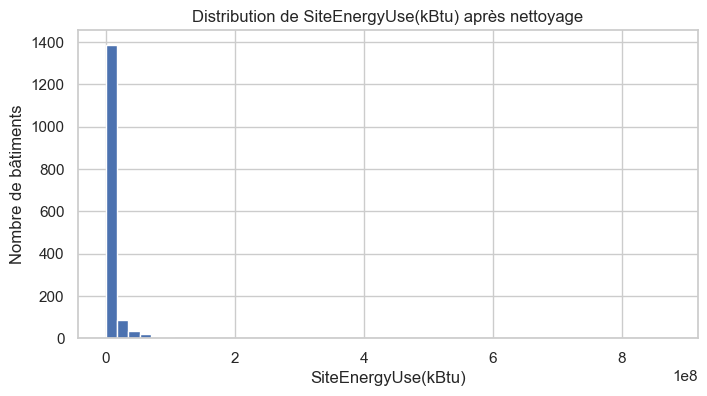

In [24]:
plt.figure(figsize=(8, 4))
building_consumption["SiteEnergyUse(kBtu)"].hist(bins=50)
plt.title("Distribution de SiteEnergyUse(kBtu) après nettoyage")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.ylabel("Nombre de bâtiments")
plt.show()

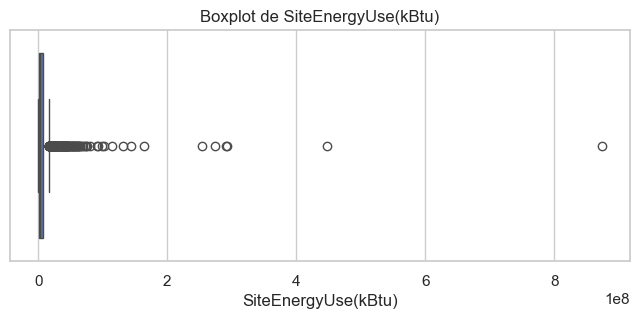

In [25]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["SiteEnergyUse(kBtu)"])
plt.title("Boxplot de SiteEnergyUse(kBtu)")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.show()

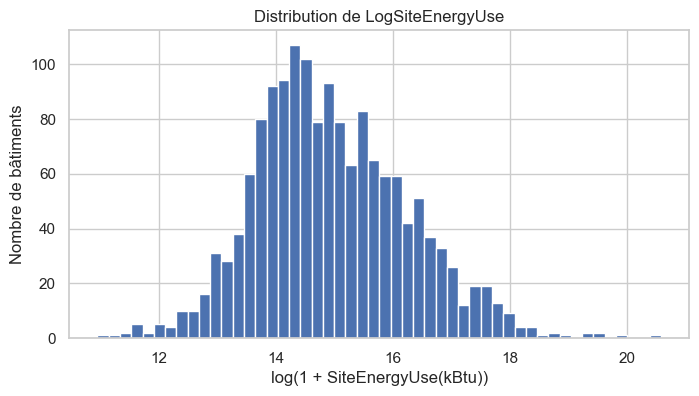

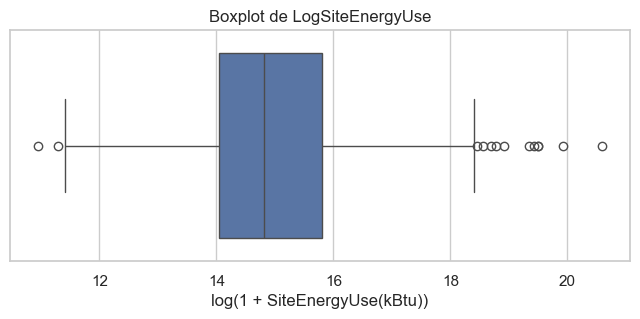

In [26]:
# Création de la variable transformée
building_consumption["LogSiteEnergyUse"] = np.log1p(building_consumption["SiteEnergyUse(kBtu)"])

# Histogramme
plt.figure(figsize=(8, 4))
building_consumption["LogSiteEnergyUse"].hist(bins=50)
plt.title("Distribution de LogSiteEnergyUse")
plt.xlabel("log(1 + SiteEnergyUse(kBtu))")
plt.ylabel("Nombre de bâtiments")
plt.show()

# Boxplot
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["LogSiteEnergyUse"])
plt.title("Boxplot de LogSiteEnergyUse")
plt.xlabel("log(1 + SiteEnergyUse(kBtu))")
plt.show()

**Interprétation :**

L’analyse conjointe de `SiteEnergyUse(kBtu)` avant et après transformation logarithmique met clairement en évidence l’intérêt de cette transformation.

Dans sa forme initiale, l’histogramme montre une distribution extrêmement asymétrique à droite : la très grande majorité des bâtiments présente des consommations relativement faibles, tandis qu’un petit nombre d’observations atteint des valeurs très élevées. Cette forte concentration des données près de zéro rend la lecture de la distribution difficile à l’échelle brute.

Le boxplot de la variable initiale confirme cette situation en faisant apparaître de nombreux outliers, parfois très éloignés du reste des observations. Cela traduit une forte dispersion et l’existence de bâtiments particulièrement énergivores, qui dominent visuellement la distribution.

Après application de la transformation logarithmique, la distribution devient beaucoup plus lisible et nettement moins asymétrique. L’histogramme de `LogSiteEnergyUse` présente une forme plus équilibrée, centrée sur un intervalle de valeurs plus resserré. Le boxplot associé montre que des valeurs atypiques subsistent, mais qu’elles sont désormais beaucoup moins extrêmes relativement au cœur de la distribution.

Ainsi, la transformation logarithmique ne supprime pas totalement les valeurs atypiques, mais elle réduit fortement leur influence et améliore la structure globale de la variable. `SiteEnergyUse(kBtu)` transformée devient donc plus adaptée aux analyses statistiques et aux modèles de prédiction, tout en conservant l’information portée par les écarts entre bâtiments.

## 10.2. Analyse univariée de `TotalGHGEmissions`

Nous poursuivons l’analyse univariée avec `TotalGHGEmissions`, qui représente les émissions totales de CO₂ des bâtiments.

Comme pour la consommation énergétique, l’objectif est de visualiser la forme de la distribution, de vérifier sa dispersion et de repérer d’éventuelles valeurs extrêmes après nettoyage.

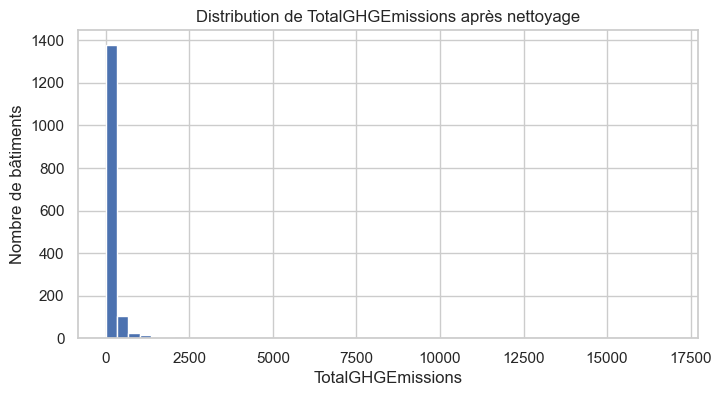

In [27]:
plt.figure(figsize=(8, 4))
building_consumption["TotalGHGEmissions"].hist(bins=50)
plt.title("Distribution de TotalGHGEmissions après nettoyage")
plt.xlabel("TotalGHGEmissions")
plt.ylabel("Nombre de bâtiments")
plt.show()

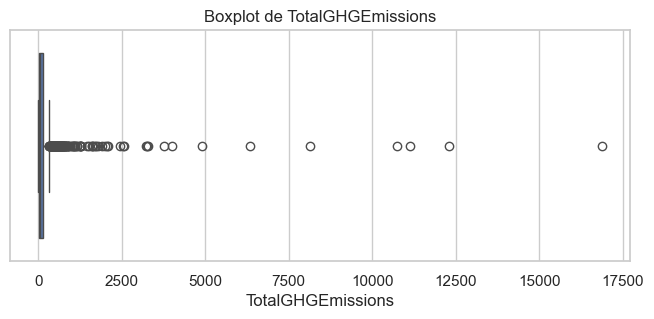

In [28]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["TotalGHGEmissions"])
plt.title("Boxplot de TotalGHGEmissions")
plt.xlabel("TotalGHGEmissions")
plt.show()

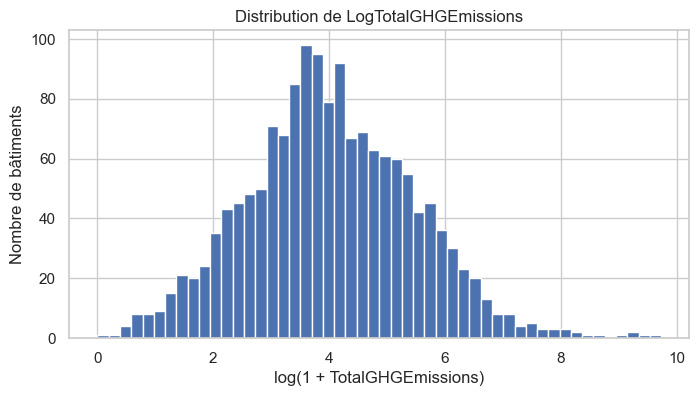

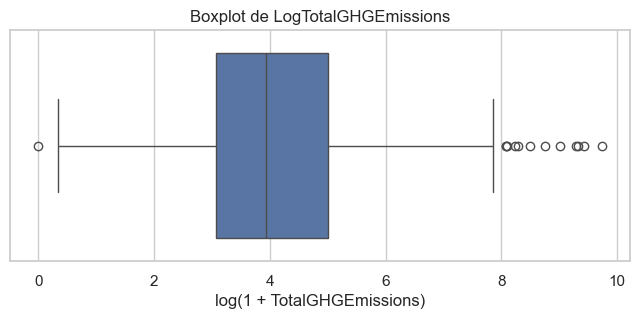

In [29]:
# Création de la variable transformée
building_consumption["LogTotalGHGEmissions"] = np.log1p(building_consumption["TotalGHGEmissions"])

# Histogramme
plt.figure(figsize=(8, 4))
building_consumption["LogTotalGHGEmissions"].hist(bins=50)
plt.title("Distribution de LogTotalGHGEmissions")
plt.xlabel("log(1 + TotalGHGEmissions)")
plt.ylabel("Nombre de bâtiments")
plt.show()

# Boxplot
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["LogTotalGHGEmissions"])
plt.title("Boxplot de LogTotalGHGEmissions")
plt.xlabel("log(1 + TotalGHGEmissions)")
plt.show()

**Interprétation :**

L’analyse de `TotalGHGEmissions` avant et après transformation logarithmique met en évidence une structure très proche de celle observée pour `SiteEnergyUse(kBtu)`.

Dans sa forme brute, l’histogramme montre une distribution extrêmement asymétrique à droite. La très grande majorité des bâtiments présente de faibles niveaux d’émissions, tandis qu’un petit nombre d’observations atteint des valeurs très élevées. Cette concentration massive des données sur les petites valeurs écrase visuellement le reste de la distribution et limite la lecture fine de sa forme.

Le boxplot de la variable initiale confirme cette forte dispersion en révélant de nombreux outliers, dont certains sont très éloignés du noyau principal des observations. Cela traduit la présence de bâtiments particulièrement émetteurs, qui exercent une influence importante sur la représentation globale de la variable.

Après application de la transformation logarithmique, la distribution devient nettement plus lisible et plus équilibrée. L’histogramme de `LogTotalGHGEmissions` présente une forme plus régulière, avec une concentration centrale mieux visible et une asymétrie fortement réduite, même si elle n’est pas totalement supprimée.

Le boxplot associé montre que quelques valeurs atypiques subsistent encore, mais qu’elles sont désormais beaucoup moins extrêmes relativement à l’ensemble des données. La dispersion paraît donc mieux maîtrisée et la structure générale de la variable devient plus exploitable.

Ainsi, la transformation logarithmique améliore fortement la représentation de `TotalGHGEmissions` en réduisant l’effet des valeurs extrêmes sans perdre l’information portée par les écarts entre bâtiments. La variable transformée apparaît donc plus adaptée aux analyses statistiques ultérieures ainsi qu’aux modèles de prédiction.

Les deux variables cibles présentant des comportements très similaires avant et après transformation, il sera pertinent de conserver cette logique pour la suite de l’étude, notamment lors de l’analyse des corrélations et de la phase de modélisation.

### 10.3. Comparaison visuelle des deux cibles avant et après transformation logarithmique

Afin de comparer les deux variables cibles de manière plus complète, nous représentons pour chacune d’elles la distribution et le boxplot à l’échelle initiale, puis après transformation logarithmique.

Cette visualisation permet d’évaluer l’effet de la transformation sur l’asymétrie, la dispersion et la présence de valeurs extrêmes, tout en comparant les comportements de `SiteEnergyUse(kBtu)` et `TotalGHGEmissions`.

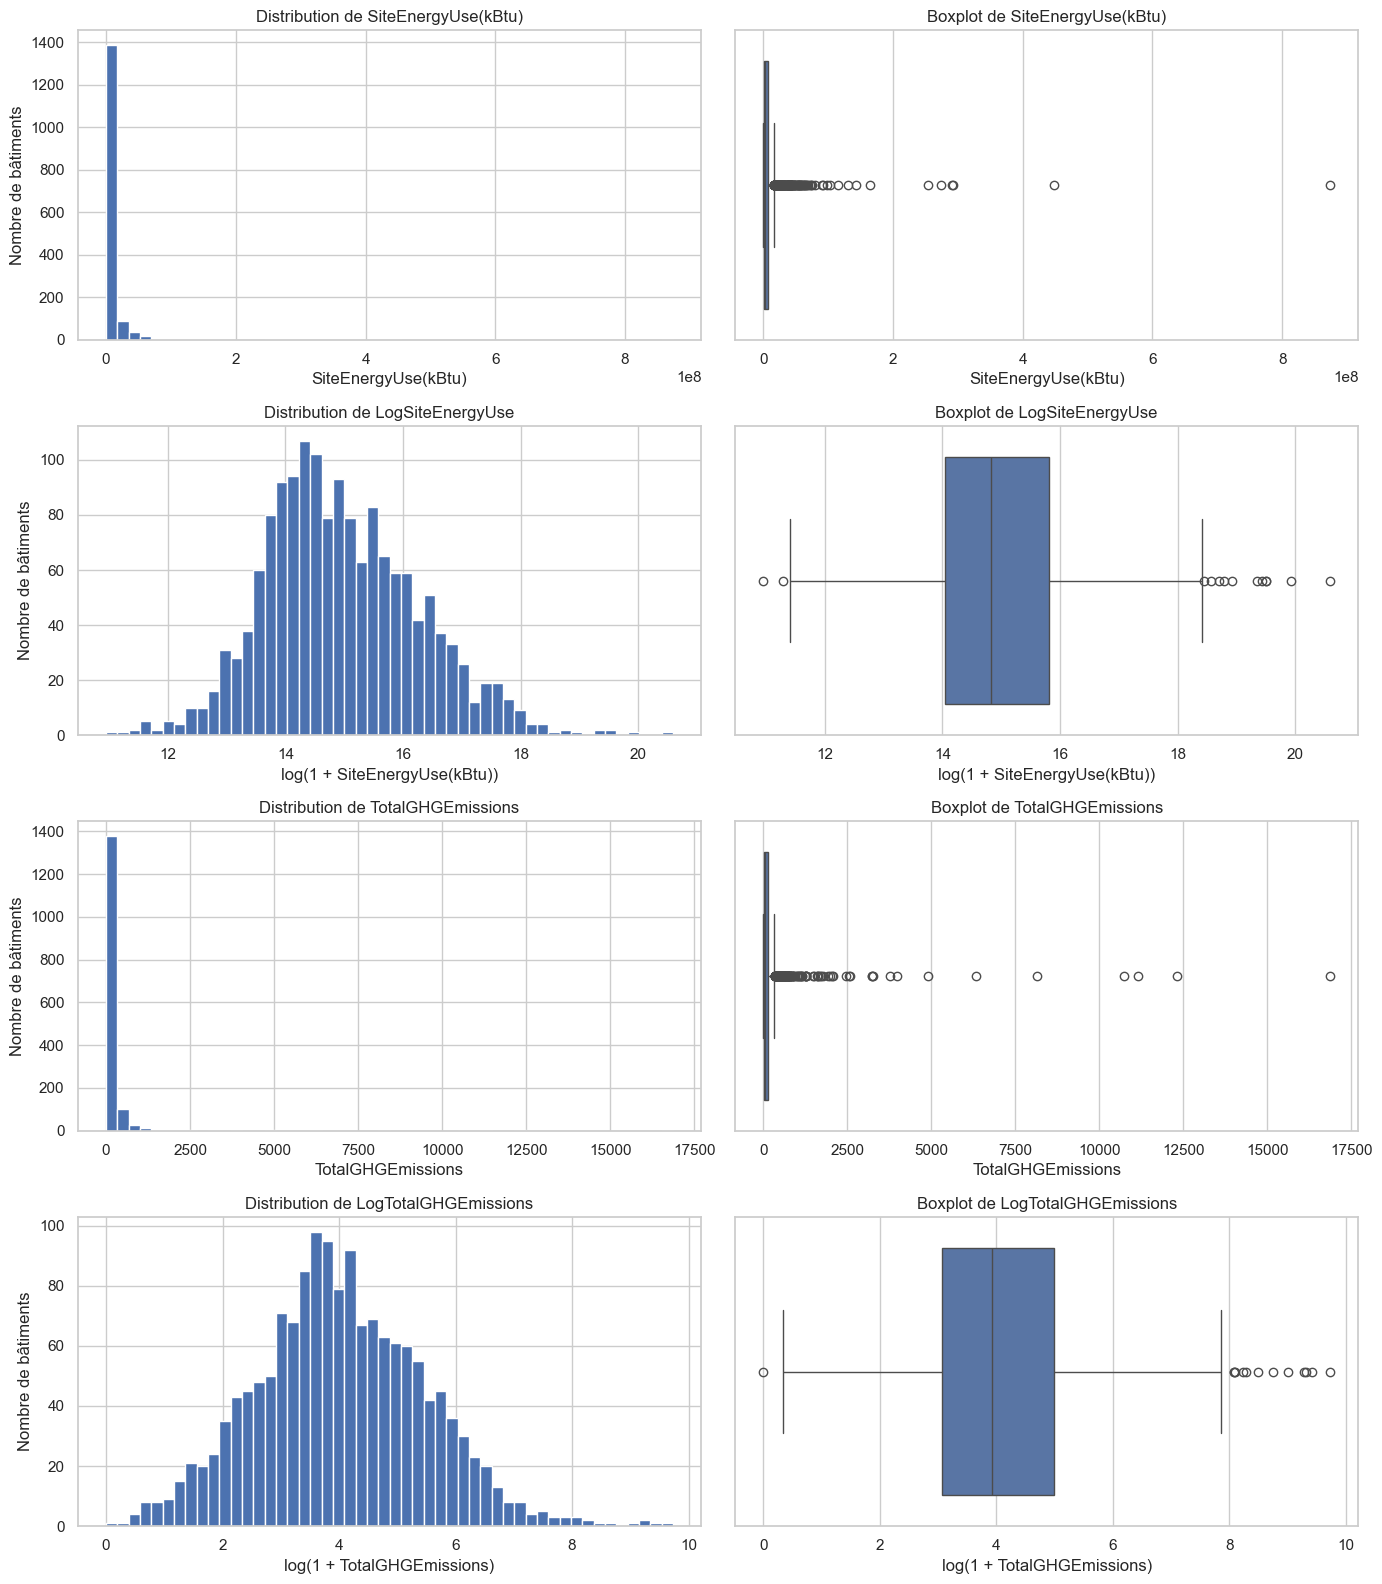

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Création des variables log si ce n'est pas déjà fait
building_consumption["LogSiteEnergyUse"] = np.log1p(building_consumption["SiteEnergyUse(kBtu)"])
building_consumption["LogTotalGHGEmissions"] = np.log1p(building_consumption["TotalGHGEmissions"])

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

# 1. SiteEnergyUse brut - histogramme
building_consumption["SiteEnergyUse(kBtu)"].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Distribution de SiteEnergyUse(kBtu)")
axes[0, 0].set_xlabel("SiteEnergyUse(kBtu)")
axes[0, 0].set_ylabel("Nombre de bâtiments")

# 2. TotalGHGEmissions brut - histogramme
building_consumption["TotalGHGEmissions"].hist(bins=50, ax=axes[2, 0])
axes[2, 0].set_title("Distribution de TotalGHGEmissions")
axes[2, 0].set_xlabel("TotalGHGEmissions")
axes[2, 0].set_ylabel("Nombre de bâtiments")

# 3. SiteEnergyUse brut - boxplot
sns.boxplot(x=building_consumption["SiteEnergyUse(kBtu)"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de SiteEnergyUse(kBtu)")
axes[0, 1].set_xlabel("SiteEnergyUse(kBtu)")

# 4. TotalGHGEmissions brut - boxplot
sns.boxplot(x=building_consumption["TotalGHGEmissions"], ax=axes[2, 1])
axes[2, 1].set_title("Boxplot de TotalGHGEmissions")
axes[2, 1].set_xlabel("TotalGHGEmissions")

# 5. SiteEnergyUse log - histogramme
building_consumption["LogSiteEnergyUse"].hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Distribution de LogSiteEnergyUse")
axes[1, 0].set_xlabel("log(1 + SiteEnergyUse(kBtu))")
axes[1, 0].set_ylabel("Nombre de bâtiments")

# 6. TotalGHGEmissions log - histogramme
building_consumption["LogTotalGHGEmissions"].hist(bins=50, ax=axes[3, 0])
axes[3, 0].set_title("Distribution de LogTotalGHGEmissions")
axes[3, 0].set_xlabel("log(1 + TotalGHGEmissions)")
axes[3, 0].set_ylabel("Nombre de bâtiments")

# 7. SiteEnergyUse log - boxplot
sns.boxplot(x=building_consumption["LogSiteEnergyUse"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de LogSiteEnergyUse")
axes[1, 1].set_xlabel("log(1 + SiteEnergyUse(kBtu))")

# 8. TotalGHGEmissions log - boxplot
sns.boxplot(x=building_consumption["LogTotalGHGEmissions"], ax=axes[3, 1])
axes[3, 1].set_title("Boxplot de LogTotalGHGEmissions")
axes[3, 1].set_xlabel("log(1 + TotalGHGEmissions)")

plt.tight_layout()
plt.show()

**Interprétation :**

La comparaison visuelle des deux cibles, avant et après transformation logarithmique, montre que `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` présentent des comportements statistiques très proches.

À l’échelle initiale, les deux variables ont des distributions fortement asymétriques à droite, avec une forte concentration des observations sur de faibles valeurs et la présence de nombreux outliers. Cette structure traduit une dispersion importante et la présence de quelques bâtiments aux niveaux de consommation ou d’émissions particulièrement élevés.

Après transformation logarithmique, les distributions deviennent nettement plus lisibles et plus équilibrées. L’asymétrie reste présente, mais elle est fortement réduite, et les valeurs extrêmes exercent une influence visuelle beaucoup moins marquée. Les boxplots montrent que des observations atypiques subsistent, sans toutefois dominer autant la distribution qu’à l’échelle brute.

Cette comparaison confirme donc que les deux variables suivent une logique statistique similaire, aussi bien avant qu’après transformation. Elle justifie de les traiter de manière cohérente dans la suite de l’analyse, notamment pour l’étude de leur relation, l’analyse des corrélations et la construction éventuelle d’un modèle capable de prédire simultanément les deux cibles.

## 10.4. Analyse univariée des principales variables explicatives numériques

Dans cette sous-section, on s’intéresse à plusieurs variables numériques importantes pour la suite du projet :

`PropertyGFATotal`
`NumberofFloors`
`YearBuilt`
`ENERGYSTARScore`

Ces variables sont intéressantes car elles décrivent :

- la taille du bâtiment ;
- sa structure ;
- son ancienneté ;
- son niveau de performance énergétique.

Avant de les relier aux cibles, il faut d’abord comprendre :

- leur distribution ;
- la présence éventuelle de valeurs extrêmes ;
- d’éventuelles incohérences.

### 10.4.1. Analyse univariée de `PropertyGFATotal`

La variable `PropertyGFATotal` représente la surface totale du bâtiment.  
Elle est potentiellement très importante, car la taille d’un bâtiment influence directement sa consommation énergétique et ses émissions de CO₂.

Nous cherchons ici à visualiser sa distribution et à repérer la présence éventuelle de très grandes surfaces.

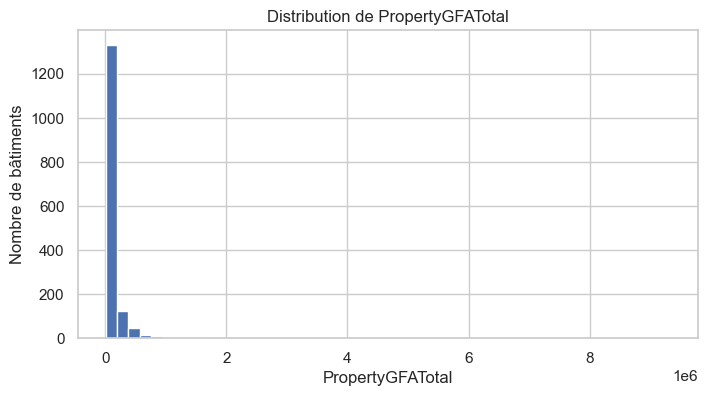

In [31]:
plt.figure(figsize=(8, 4))
building_consumption["PropertyGFATotal"].hist(bins=50)
plt.title("Distribution de PropertyGFATotal")
plt.xlabel("PropertyGFATotal")
plt.ylabel("Nombre de bâtiments")
plt.show()

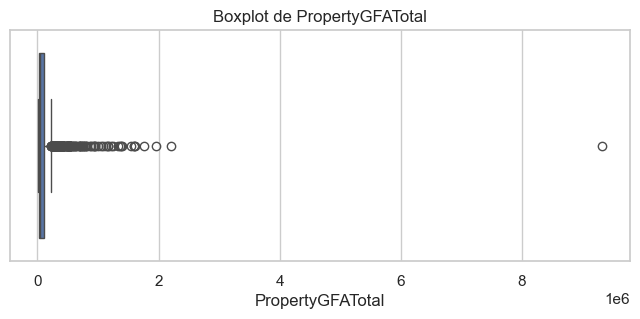

In [32]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["PropertyGFATotal"])
plt.title("Boxplot de PropertyGFATotal")
plt.xlabel("PropertyGFATotal")
plt.show()

**Interprétation :**

La variable `PropertyGFATotal` présente une distribution très asymétrique à droite. La majorité des bâtiments possède une surface totale relativement modérée, tandis qu’un petit nombre de bâtiments présente des surfaces extrêmement élevées.

Le boxplot confirme la présence de nombreux outliers, dont certains très éloignés du reste des observations.

Cette variable semble donc fortement dispersée, mais elle est aussi potentiellement très informative pour expliquer la consommation énergétique et les émissions de CO₂, car la taille d’un bâtiment influence directement ses besoins énergétiques.

### 10.4.2. Analyse univariée de `NumberofFloors`

La variable `NumberofFloors` indique le nombre d’étages du bâtiment.  
Elle apporte une information structurelle importante, qui peut être liée au volume du bâtiment et à sa consommation.

Nous cherchons ici à examiner la forme de sa distribution et à vérifier la présence de valeurs atypiques.

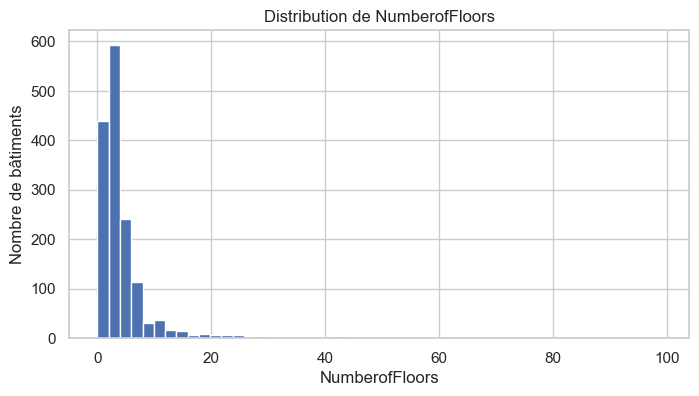

In [33]:
plt.figure(figsize=(8, 4))
building_consumption["NumberofFloors"].hist(bins=50)
plt.title("Distribution de NumberofFloors")
plt.xlabel("NumberofFloors")
plt.ylabel("Nombre de bâtiments")
plt.show()

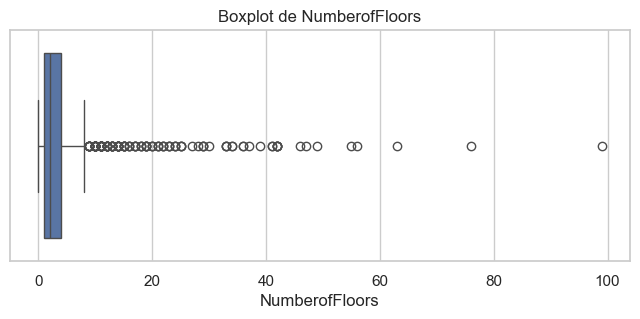

In [34]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["NumberofFloors"])
plt.title("Boxplot de NumberofFloors")
plt.xlabel("NumberofFloors")
plt.show()

**Interprétation :**

La variable `NumberofFloors` est fortement concentrée sur les petites valeurs, ce qui montre que la majorité des bâtiments du dataset possède peu d’étages.

Le boxplot met en évidence plusieurs outliers, avec quelques bâtiments extrêmement hauts. Cela indique que la variable est asymétrique à droite et comporte quelques cas structurellement atypiques.

Même si ces valeurs extrêmes sont rares, `NumberofFloors` reste une variable pertinente pour décrire la structure du bâtiment et potentiellement expliquer ses besoins énergétiques.

### 10.4.3. Analyse univariée de `YearBuilt`

La variable `YearBuilt` correspond à l’année de construction du bâtiment.  
Elle peut être importante, car l’ancienneté d’un bâtiment peut influencer ses performances énergétiques.

Nous cherchons ici à observer la répartition des années de construction et à repérer d’éventuelles concentrations sur certaines périodes.

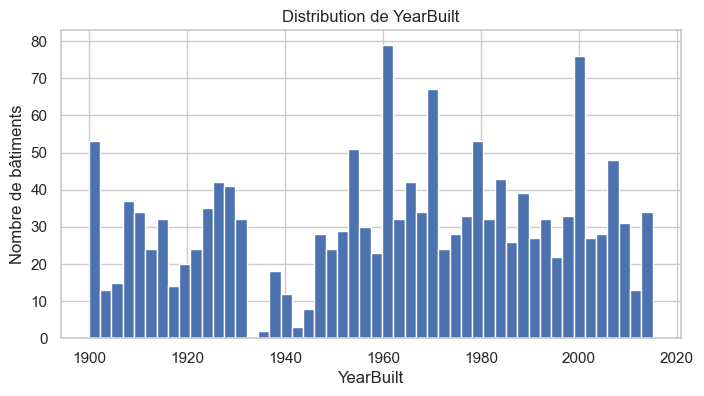

In [35]:
plt.figure(figsize=(8, 4))
building_consumption["YearBuilt"].hist(bins=50)
plt.title("Distribution de YearBuilt")
plt.xlabel("YearBuilt")
plt.ylabel("Nombre de bâtiments")
plt.show()

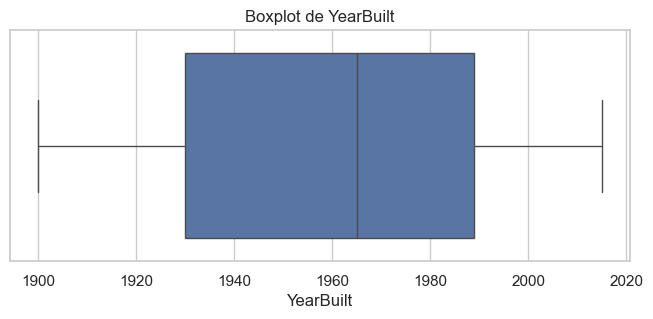

In [36]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["YearBuilt"])
plt.title("Boxplot de YearBuilt")
plt.xlabel("YearBuilt")
plt.show()

**Interprétation :**

La variable `YearBuilt` présente une répartition étendue sur plus d’un siècle, sans forte asymétrie ni valeurs extrêmes problématiques.

La distribution suggère que le dataset contient à la fois des bâtiments anciens et des bâtiments plus récents, ce qui est intéressant pour étudier l’effet de l’ancienneté sur la consommation énergétique et les émissions de CO₂.

Le boxplot ne met pas en évidence d’anomalie majeure, ce qui rend cette variable directement exploitable dans la suite de l’analyse.

### 10.4.4. Analyse univariée de `ENERGYSTARScore`

La variable `ENERGYSTARScore` mesure la performance énergétique du bâtiment sur une échelle standardisée.  
Elle peut être très informative pour expliquer les différences de consommation ou d’émissions entre bâtiments.

Nous cherchons ici à visualiser sa distribution parmi les observations renseignées.

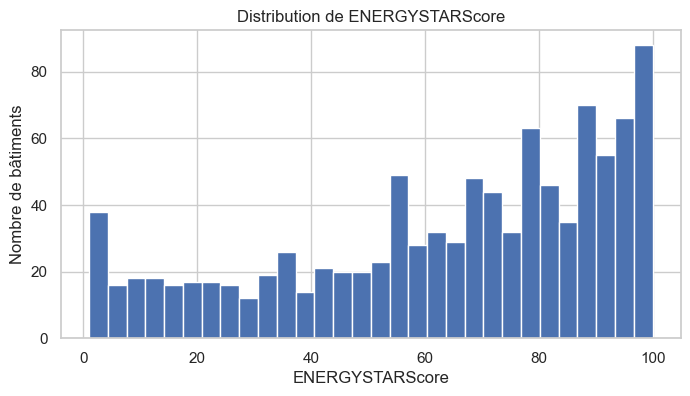

In [37]:
plt.figure(figsize=(8, 4))
building_consumption["ENERGYSTARScore"].dropna().hist(bins=30)
plt.title("Distribution de ENERGYSTARScore")
plt.xlabel("ENERGYSTARScore")
plt.ylabel("Nombre de bâtiments")
plt.show()

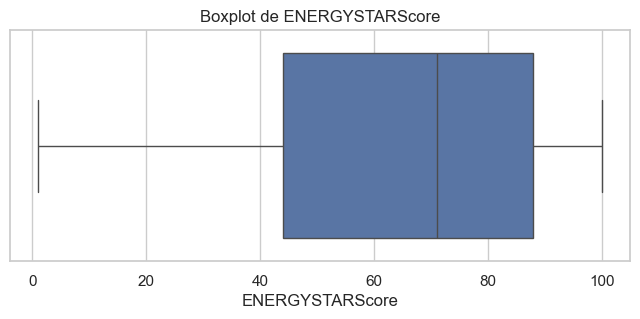

In [38]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=building_consumption["ENERGYSTARScore"].dropna())
plt.title("Boxplot de ENERGYSTARScore")
plt.xlabel("ENERGYSTARScore")
plt.show()

**Interprétation :**

La variable `ENERGYSTARScore` présente une distribution globalement concentrée vers les scores élevés, ce qui suggère qu’une part importante des bâtiments renseignés possède une performance énergétique relativement correcte.

Le boxplot ne met pas en évidence d’outliers majeurs, et la dispersion reste raisonnable.

Cette variable semble donc particulièrement intéressante pour la suite de l’analyse, car elle apporte une information directement liée à l’efficacité énergétique du bâtiment.

## 10.4.5. Vue d’ensemble des principales variables numériques

Afin d’avoir une vision synthétique des distributions des principales variables explicatives numériques, nous affichons leurs histogrammes et boxplots dans une figure d’ensemble.

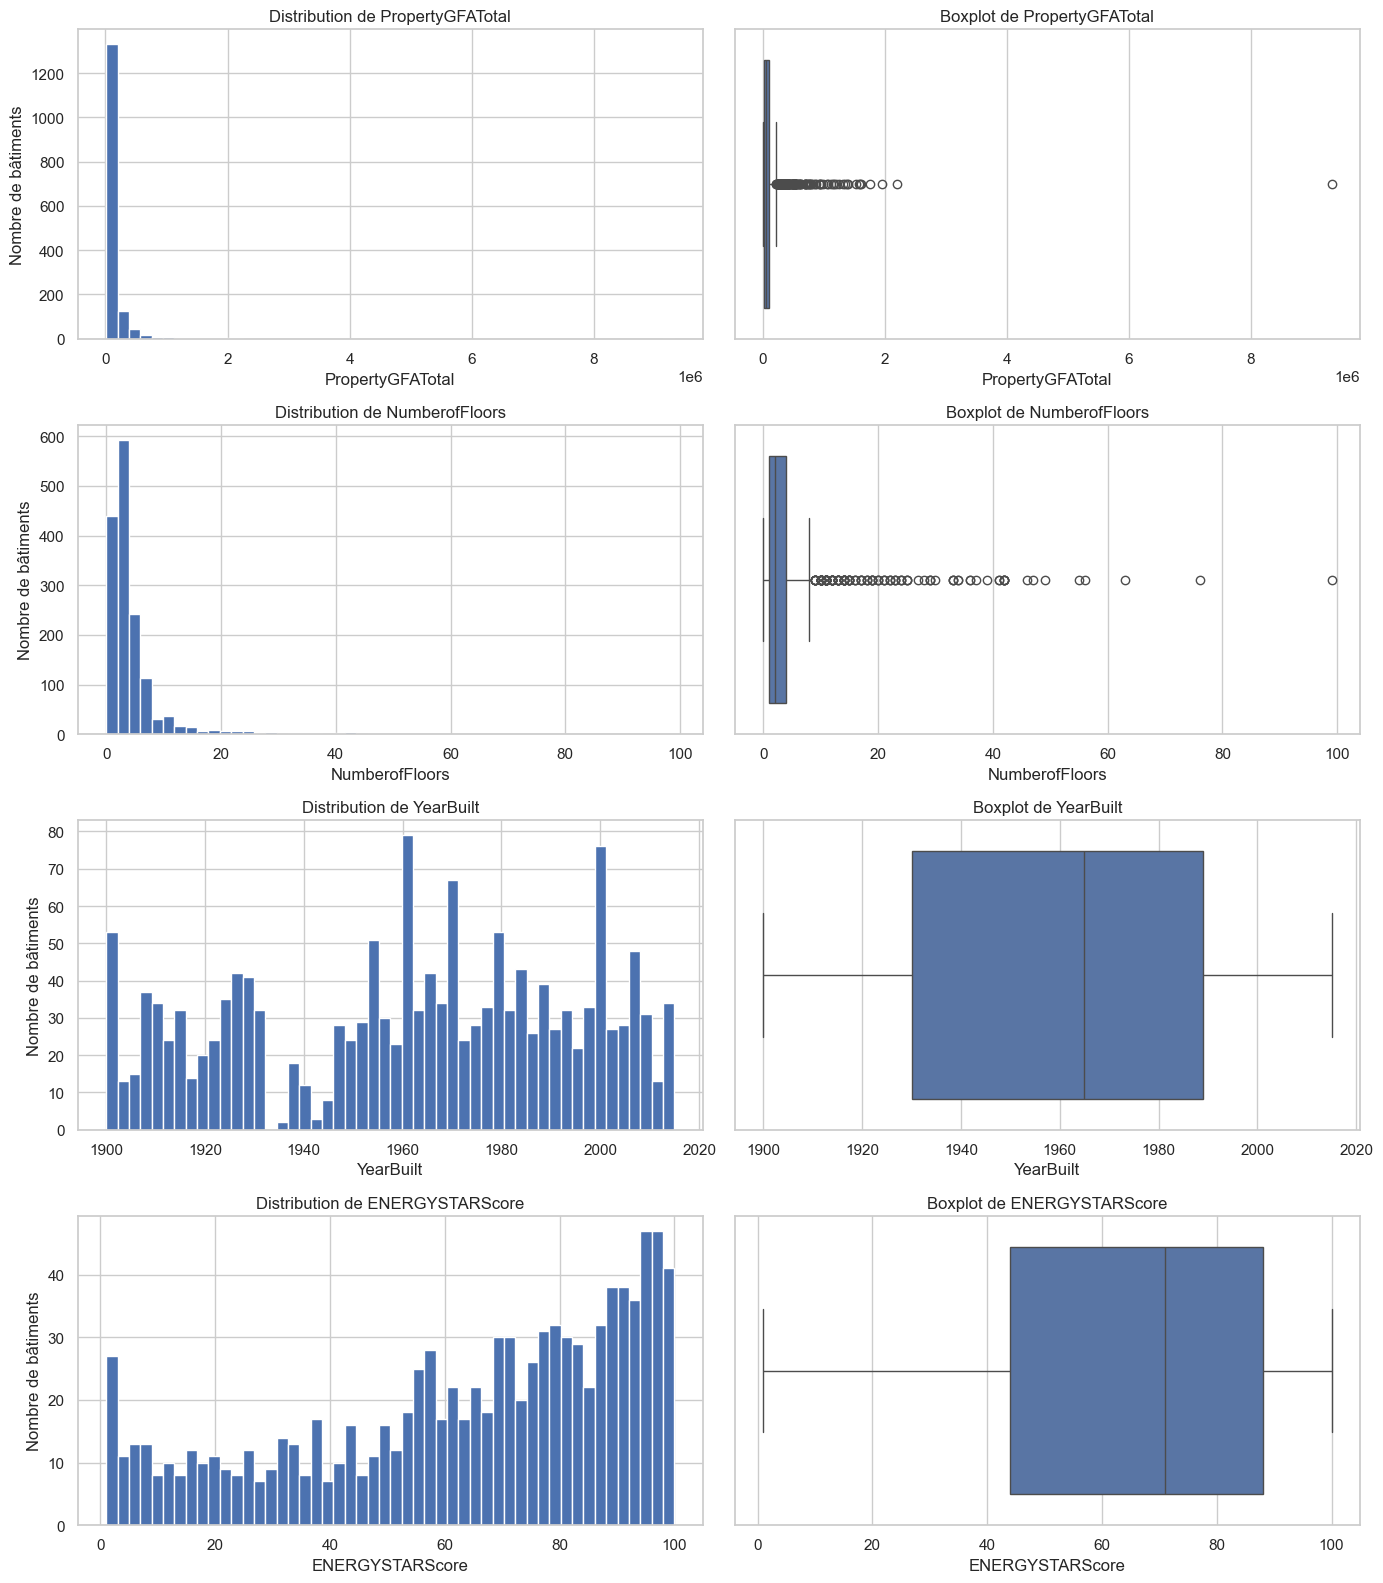

In [39]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

# PropertyGFATotal
building_consumption["PropertyGFATotal"].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Distribution de PropertyGFATotal")
axes[0, 0].set_xlabel("PropertyGFATotal")
axes[0, 0].set_ylabel("Nombre de bâtiments")

sns.boxplot(x=building_consumption["PropertyGFATotal"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de PropertyGFATotal")
axes[0, 1].set_xlabel("PropertyGFATotal")

# NumberofFloors
building_consumption["NumberofFloors"].hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Distribution de NumberofFloors")
axes[1, 0].set_xlabel("NumberofFloors")
axes[1, 0].set_ylabel("Nombre de bâtiments")

sns.boxplot(x=building_consumption["NumberofFloors"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de NumberofFloors")
axes[1, 1].set_xlabel("NumberofFloors")

# YearBuilt
building_consumption["YearBuilt"].hist(bins=50, ax=axes[2, 0])
axes[2, 0].set_title("Distribution de YearBuilt")
axes[2, 0].set_xlabel("YearBuilt")
axes[2, 0].set_ylabel("Nombre de bâtiments")

sns.boxplot(x=building_consumption["YearBuilt"], ax=axes[2, 1])
axes[2, 1].set_title("Boxplot de YearBuilt")
axes[2, 1].set_xlabel("YearBuilt")

# ENERGYSTARScore
building_consumption["ENERGYSTARScore"].dropna().hist(bins=50, ax=axes[3, 0])
axes[3, 0].set_title("Distribution de ENERGYSTARScore")
axes[3, 0].set_xlabel("ENERGYSTARScore")
axes[3, 0].set_ylabel("Nombre de bâtiments")

sns.boxplot(x=building_consumption["ENERGYSTARScore"].dropna(), ax=axes[3, 1])
axes[3, 1].set_title("Boxplot de ENERGYSTARScore")
axes[3, 1].set_xlabel("ENERGYSTARScore")

plt.tight_layout()
plt.show()

**Interprétation globale :**

Les principales variables explicatives numériques présentent des comportements très différents :

- `PropertyGFATotal` et `NumberofFloors` sont fortement asymétriques et contiennent plusieurs outliers ;
- `YearBuilt` présente une répartition plus régulière, sans valeur extrême problématique ;
- `ENERGYSTARScore` est une variable bornée et relativement stable, potentiellement très informative pour la performance énergétique.

Cette diversité de distributions confirme l’intérêt d’une analyse exploratoire détaillée avant d’étudier les relations entre variables et de passer au feature engineering.

##  Conclusion de la section 10.4

- À ce stade, on a une bonne compréhension des principales variables numériques :

- les variables de taille sont très asymétriques ;

- les variables structurelles ne se comportent pas toutes de la même manière ;

- certaines variables semblent naturellement plus “propres” que d’autres ;

- plusieurs d’entre elles paraissent déjà très prometteuses pour expliquer les deux cibles.

## 10.5. Analyse univariée des principales variables explicatives catégorielles

L’objectif de cette sous-section est de comprendre :

quelles catégories sont les plus représentées ;
si certaines catégories dominent fortement le dataset ;
si certaines modalités sont très rares ;
quelles variables catégorielles seront pertinentes pour la suite de l’analyse et de la modélisation.

On va commencer par les variables les plus informatives :

`PrimaryPropertyType`
`Neighborhood`

et on pourra aussi jeter un œil à `BuildingType` après filtrage, même si cette variable est maintenant beaucoup moins variée.

### 10.5.1. Analyse univariée de `PrimaryPropertyType`

La variable `PrimaryPropertyType` décrit l’usage principal du bâtiment (bureaux, hôtels, écoles, entrepôts, commerces, etc.).

Elle est potentiellement très importante, car le type d’activité exercée dans un bâtiment influence directement son profil énergétique et ses émissions de CO₂.

Nous cherchons ici à identifier les catégories les plus fréquentes et à évaluer l’hétérogénéité des usages représentés dans le dataset.

In [40]:
#fréquences des catégories
building_consumption["PrimaryPropertyType"].value_counts().head(15)

PrimaryPropertyType
Small- and Mid-Sized Office    285
Other                          245
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     50
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Name: count, dtype: int64

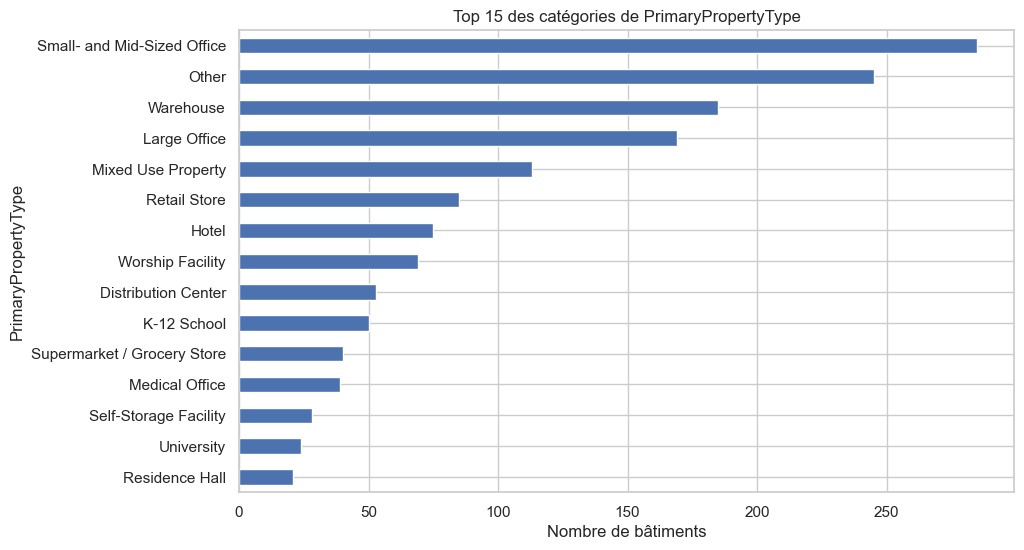

In [41]:
#barplot des catégories les plus fréquentes
plt.figure(figsize=(10, 6))
building_consumption["PrimaryPropertyType"].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 des catégories de PrimaryPropertyType")
plt.xlabel("Nombre de bâtiments")
plt.ylabel("PrimaryPropertyType")
plt.show()

**Interprétation :**

La variable `PrimaryPropertyType` montre que le dataset est dominé par quelques usages principaux, en particulier les bureaux de taille petite ou moyenne, les entrepôts et les grands bureaux.

Cependant, les catégories restent variées : commerces, hôtels, écoles, bâtiments religieux ou encore bâtiments mixtes sont également représentés. Cette diversité confirme que le dataset couvre plusieurs profils énergétiques potentiellement très différents.

La catégorie `Other` est particulièrement fréquente, ce qui montre qu’une part non négligeable des bâtiments n’est pas décrite par un usage principal très précis. Malgré cette limite, `PrimaryPropertyType` reste une variable catégorielle importante pour la suite de l’analyse et de la modélisation.

### 10.5.2. Analyse univariée de `Neighborhood`

La variable `Neighborhood` indique le quartier dans lequel se situe le bâtiment.

Même si cette variable est moins directement liée au fonctionnement du bâtiment que `PrimaryPropertyType`, elle peut apporter une information utile sur le contexte urbain, la densité ou la structure du bâti.

Nous cherchons ici à repérer les quartiers les plus représentés dans le dataset.

In [42]:
# fréquences des quartiers
building_consumption["Neighborhood"].value_counts().head(15)

Neighborhood
DOWNTOWN                 351
GREATER DUWAMISH         328
MAGNOLIA / QUEEN ANNE    144
LAKE UNION               143
NORTHEAST                117
EAST                     116
NORTHWEST                 74
BALLARD                   58
NORTH                     51
CENTRAL                   41
DELRIDGE                  36
SOUTHEAST                 31
SOUTHWEST                 31
North                      8
Ballard                    5
Name: count, dtype: int64

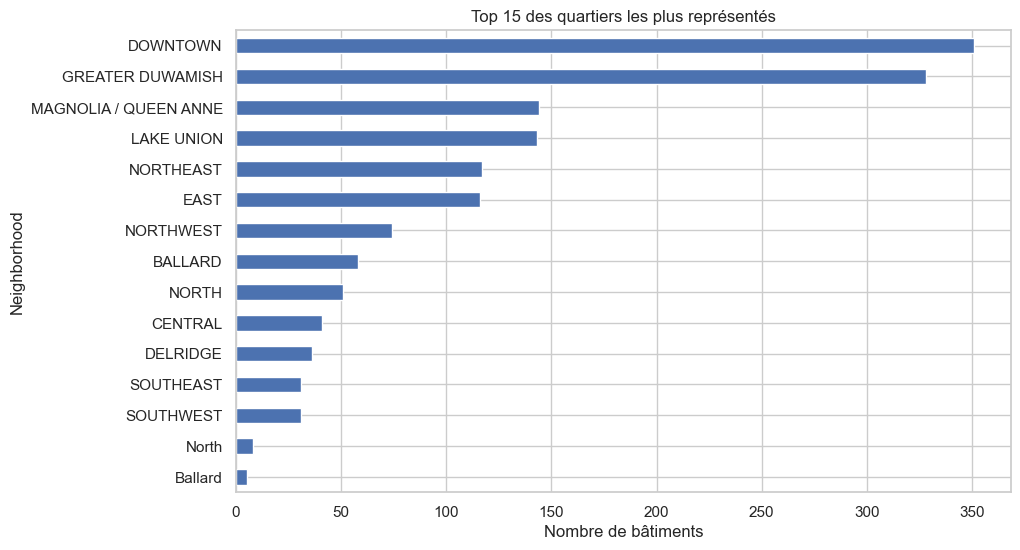

In [43]:
# barplot des quartiers les plus fréquents
plt.figure(figsize=(10, 6))
building_consumption["Neighborhood"].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 des quartiers les plus représentés")
plt.xlabel("Nombre de bâtiments")
plt.ylabel("Neighborhood")
plt.show()

**Interprétation :**

La variable `Neighborhood` montre que les bâtiments du dataset sont inégalement répartis dans l’espace urbain. Les quartiers `DOWNTOWN` et `GREATER DUWAMISH` sont nettement surreprésentés, ce qui reflète probablement la concentration des bâtiments non résidentiels dans les zones centrales, commerciales ou industrielles.

La distribution géographique n’est donc pas homogène, ce qui suggère que la localisation pourrait jouer un rôle dans les comportements énergétiques.

On remarque également quelques incohérences d’écriture, comme `NORTH` / `North` ou `BALLARD` / `Ballard`, qui traduisent une légère absence de normalisation dans cette variable.

### 10.5.3. Vérification finale de `BuildingType`

Après le filtrage du périmètre non résidentiel, la variable `BuildingType` contient beaucoup moins de catégories qu’au départ.

Cette vérification permet simplement de confirmer les types de bâtiments encore présents dans le dataset final nettoyé.

In [44]:
building_consumption["BuildingType"].value_counts(dropna=False)

BuildingType
NonResidential        1431
Nonresidential COS      81
Campus                  24
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64

**Interprétation :**

Elle ne sert plus à définir le périmètre, car cela a déjà été fait, mais à rappeler qu’après nettoyage, le dataset final est composé uniquement de catégories compatibles avec le projet.

Après filtrage du périmètre non résidentiel et contrôle qualité, la variable `BuildingType` contient désormais uniquement des catégories compatibles avec l’objectif du projet.

La catégorie `NonResidential` domine très largement le dataset final, ce qui signifie que cette variable est devenue moins informative qu’au départ. Les catégories institutionnelles spécifiques (`Campus`, `SPS-District K-12`, `Nonresidential COS`, `Nonresidential WA`) restent présentes mais en effectifs beaucoup plus faibles.

Ainsi, `BuildingType` peut encore être conservée comme variable explicative, mais elle sera probablement moins discriminante que `PrimaryPropertyType`.

### 10.5.4. Vue d’ensemble des principales variables catégorielles

Afin d’obtenir une lecture synthétique des catégories les plus fréquentes, nous représentons côte à côte les principales modalités de `PrimaryPropertyType` et `Neighborhood`.

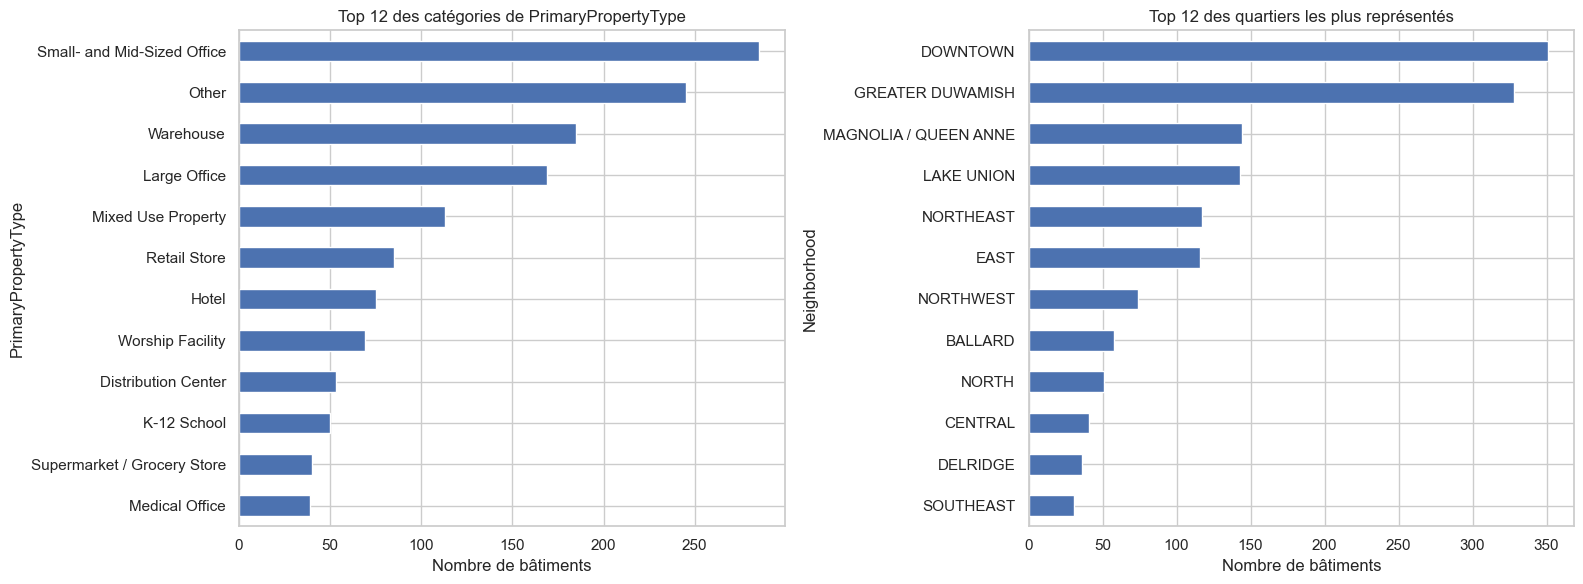

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

building_consumption["PrimaryPropertyType"].value_counts().head(12).sort_values().plot(
    kind="barh", ax=axes[0]
)
axes[0].set_title("Top 12 des catégories de PrimaryPropertyType")
axes[0].set_xlabel("Nombre de bâtiments")
axes[0].set_ylabel("PrimaryPropertyType")

building_consumption["Neighborhood"].value_counts().head(12).sort_values().plot(
    kind="barh", ax=axes[1]
)
axes[1].set_title("Top 12 des quartiers les plus représentés")
axes[1].set_xlabel("Nombre de bâtiments")
axes[1].set_ylabel("Neighborhood")

plt.tight_layout()
plt.show()

**Interprétation globale :**

Les variables catégorielles montrent que le dataset est à la fois :

- fonctionnellement hétérogène, avec plusieurs usages principaux représentés ;
- spatialement concentré, avec une forte présence de certains quartiers.

`PrimaryPropertyType` semble particulièrement importante pour expliquer les différences de consommation énergétique et d’émissions, tandis que `Neighborhood` apporte une information géographique complémentaire.

Ces variables devront donc être intégrées avec soin dans la suite de l’analyse et dans la préparation des modèles.

## 11. Analyse bivariée entre variables explicatives et variables cibles

Jusqu’ici, on a étudié les variables une par une.
Maintenant, on veut comprendre comment certaines variables explicatives sont liées aux deux cibles :

`SiteEnergyUse(kBtu)`
`TotalGHGEmissions`

Cette étape est essentielle car elle permet de :

détecter des relations visuelles ;
voir si certaines variables semblent très explicatives ;
repérer des structures non linéaires ;
préparer les choix de feature engineering et de modélisation.

On va commencer par la variable la plus naturelle :

`PropertyGFATotal`

car la surface totale du bâtiment a de fortes chances d’influencer directement :

la consommation énergétique ;
les émissions de CO₂.

## 11.1. Relation entre `PropertyGFATotal` et `SiteEnergyUse(kBtu)`

Nous commençons l’analyse bivariée par la relation entre la surface totale du bâtiment (`PropertyGFATotal`) et sa consommation énergétique totale (`SiteEnergyUse(kBtu)`).

Cette relation est importante à étudier, car on peut s’attendre à ce que les bâtiments les plus grands consomment davantage d’énergie.

L’objectif est ici de vérifier visuellement :

- s’il existe une relation croissante ;
- si cette relation semble linéaire ou non ;
- et si quelques observations extrêmes dominent le nuage de points.

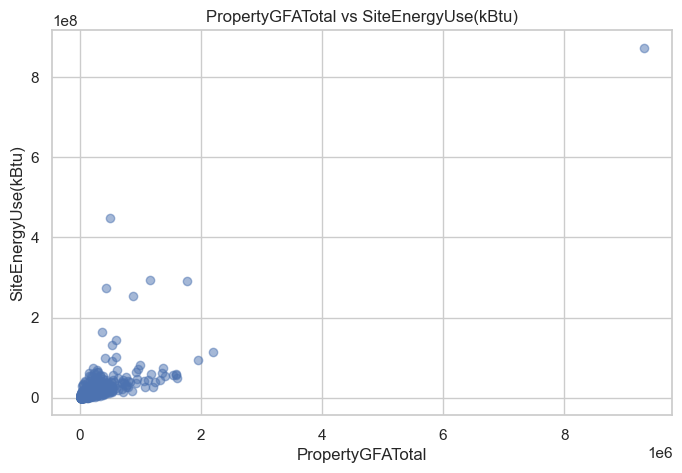

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["PropertyGFATotal"],
    building_consumption["SiteEnergyUse(kBtu)"],
    alpha=0.5
)
plt.title("PropertyGFATotal vs SiteEnergyUse(kBtu)")
plt.xlabel("PropertyGFATotal")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.show()

### Lecture complémentaire en échelle logarithmique

Comme `PropertyGFATotal` et `SiteEnergyUse(kBtu)` sont toutes deux très asymétriques, nous ajoutons une visualisation en échelle logarithmique afin de mieux lire la structure de la relation.

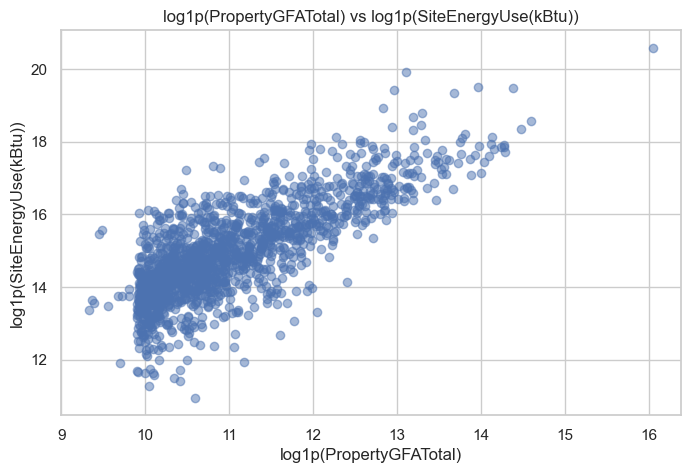

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(
    np.log1p(building_consumption["PropertyGFATotal"]),
    np.log1p(building_consumption["SiteEnergyUse(kBtu)"]),
    alpha=0.5
)
plt.title("log1p(PropertyGFATotal) vs log1p(SiteEnergyUse(kBtu))")
plt.xlabel("log1p(PropertyGFATotal)")
plt.ylabel("log1p(SiteEnergyUse(kBtu))")
plt.show()

**Interprétation :**

Le nuage de points en échelle brute est fortement dominé par quelques valeurs extrêmes, ce qui rend la relation difficile à lire. On observe néanmoins une tendance générale croissante : les bâtiments les plus grands tendent à consommer davantage d’énergie.

La représentation en échelle logarithmique permet de mieux visualiser cette relation. Le nuage devient alors beaucoup plus structuré et met en évidence une relation positive quasi linéaire entre la surface du bâtiment et sa consommation énergétique.

Cela suggère que `PropertyGFATotal` est une variable explicative importante pour prédire `SiteEnergyUse(kBtu)`.

## 11.2. Relation entre `PropertyGFATotal` et `TotalGHGEmissions`

Nous poursuivons l’analyse bivariée avec la relation entre la surface totale du bâtiment (`PropertyGFATotal`) et les émissions totales de CO₂ (`TotalGHGEmissions`).

Comme pour la consommation énergétique, on peut s’attendre à ce que les bâtiments les plus grands soient globalement plus émetteurs. Nous vérifions ici si cette tendance apparaît clairement dans les données.

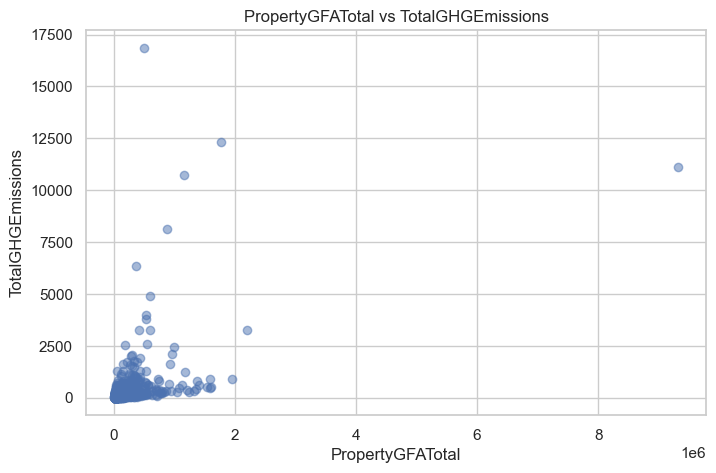

In [48]:
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["PropertyGFATotal"],
    building_consumption["TotalGHGEmissions"],
    alpha=0.5
)
plt.title("PropertyGFATotal vs TotalGHGEmissions")
plt.xlabel("PropertyGFATotal")
plt.ylabel("TotalGHGEmissions")
plt.show()

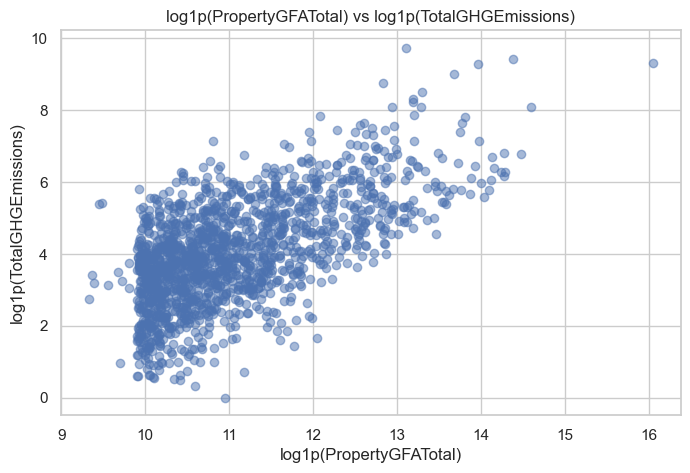

In [49]:
# Variante en log
plt.figure(figsize=(8, 5))
plt.scatter(
    np.log1p(building_consumption["PropertyGFATotal"]),
    np.log1p(building_consumption["TotalGHGEmissions"]),
    alpha=0.5
)
plt.title("log1p(PropertyGFATotal) vs log1p(TotalGHGEmissions)")
plt.xlabel("log1p(PropertyGFATotal)")
plt.ylabel("log1p(TotalGHGEmissions)")
plt.show()

**Interprétation :**

Comme pour la consommation énergétique, le nuage de points en échelle brute est fortement influencé par quelques valeurs extrêmes, ce qui rend la lecture difficile.

En revanche, la représentation en échelle logarithmique met en évidence une relation croissante claire entre la surface totale du bâtiment et les émissions de CO₂. Le nuage de points devient plus structuré et suggère une relation quasi linéaire en log.

Cela confirme que `PropertyGFATotal` est également une variable explicative pertinente pour prédire `TotalGHGEmissions`.

**Conclusion :**

L’analyse bivariée montre que `PropertyGFATotal` est fortement liée aux deux variables cibles (`SiteEnergyUse(kBtu)` et `TotalGHGEmissions`).

Dans les deux cas, la relation est positive : les bâtiments les plus grands tendent à consommer plus d’énergie et à émettre davantage de CO₂.

La transformation logarithmique permet de révéler une relation plus structurée et quasi linéaire, ce qui suggère que **la taille du bâtiment** est un facteur explicatif majeur dans le problème étudié.

## 11.3. Relation entre SiteEnergyUse(kBtu) et TotalGHGEmissions

Cette sous-section est centrale, car elle permet d’étudier directement le lien entre les deux variables cibles du projet :

`SiteEnergyUse(kBtu)` : consommation énergétique totale ;
`TotalGHGEmissions` : émissions totales de CO₂.

L’objectif est de vérifier :

- si les deux cibles évoluent dans le même sens ;
- si la relation est forte ou non ;
- si cette relation soutient l’idée d’un modèle multi-output prédisant les deux simultanément.

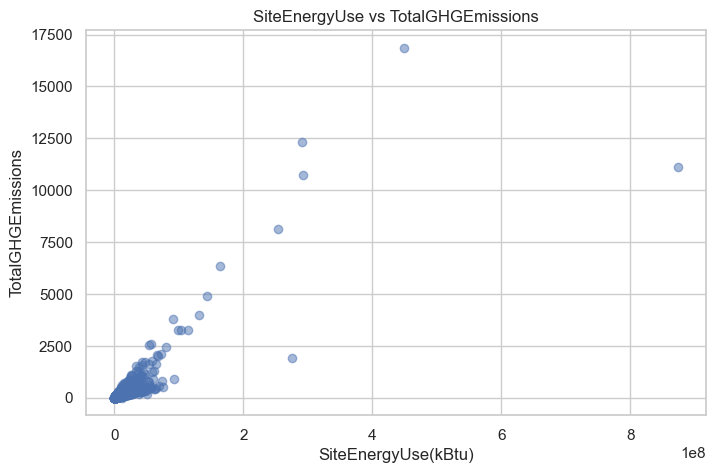

In [50]:
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["SiteEnergyUse(kBtu)"],
    building_consumption["TotalGHGEmissions"],
    alpha=0.5
)
plt.title("SiteEnergyUse vs TotalGHGEmissions")
plt.xlabel("SiteEnergyUse(kBtu)")
plt.ylabel("TotalGHGEmissions")
plt.show()

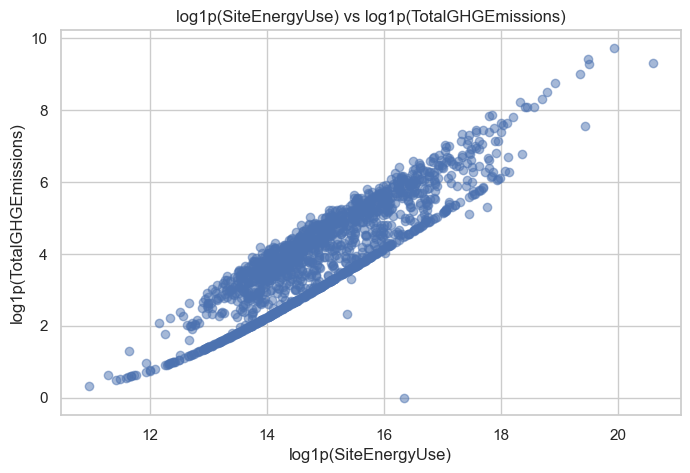

In [51]:
plt.figure(figsize=(8, 5))
plt.scatter(
    np.log1p(building_consumption["SiteEnergyUse(kBtu)"]),
    np.log1p(building_consumption["TotalGHGEmissions"]),
    alpha=0.5
)
plt.title("log1p(SiteEnergyUse) vs log1p(TotalGHGEmissions)")
plt.xlabel("log1p(SiteEnergyUse)")
plt.ylabel("log1p(TotalGHGEmissions)")
plt.show()

**Interprétation :**

Le nuage de points entre `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` met en évidence une relation croissante nette : les bâtiments qui consomment le plus d’énergie tendent aussi à être les plus émetteurs en CO₂.

En échelle brute, cette relation est visible mais partiellement écrasée par les valeurs extrêmes. La transformation logarithmique améliore fortement la lisibilité et fait apparaître une relation beaucoup plus structurée entre les deux cibles.

Cette observation est importante pour la suite du projet :

- elle montre que les deux variables cibles sont fortement liées ;
- elle justifie une analyse commune des deux sorties ;
- et elle soutient l’idée de tester un modèle multi-output capable de prédire simultanément la consommation énergétique et les émissions de CO₂.

La dispersion restante indique toutefois que les deux cibles ne sont pas parfaitement redondantes : les émissions dépendent aussi d’autres facteurs que la seule consommation énergétique.

**Conclusion intermédiaire :**

L’analyse bivariée réalisée jusqu’ici montre que certaines variables explicatives, comme `PropertyGFATotal`, entretiennent une relation claire avec les deux cibles. Elle montre aussi que `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` sont elles-mêmes fortement liées.

La prochaine étape consiste à poursuivre l’analyse bivariée avec d’autres variables explicatives importantes, notamment `NumberofFloors` et `YearBuilt`, afin d’identifier d’autres relations utiles avant le feature engineering.

## 11.4. Relation entre `NumberofFloors` et les deux cibles

Nous examinons maintenant la relation entre le nombre d’étages (`NumberofFloors`) et les deux variables cibles.

Cette variable décrit la structure verticale du bâtiment et peut influencer sa consommation énergétique ainsi que ses émissions de CO₂.

### 11.4.1. `NumberofFloors` vs `SiteEnergyUse(kBtu)`

Nous commençons par étudier la relation entre le nombre d’étages et la consommation énergétique totale du bâtiment.

L’objectif est de voir si les bâtiments les plus hauts tendent à consommer davantage d’énergie, et si cette relation apparaît clairement dans les données.

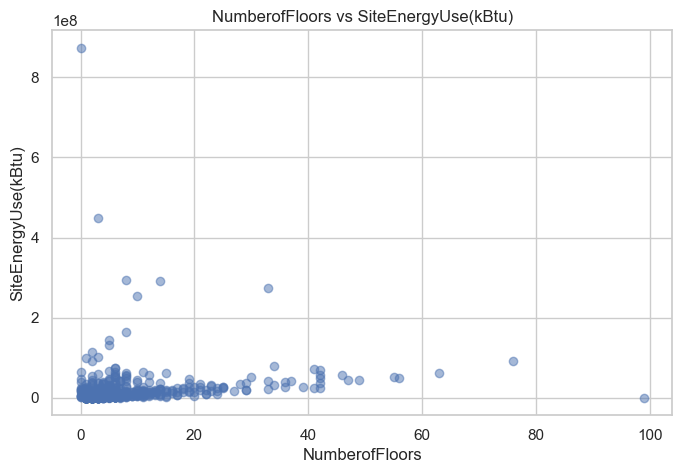

In [52]:
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["NumberofFloors"],
    building_consumption["SiteEnergyUse(kBtu)"],
    alpha=0.5
)
plt.title("NumberofFloors vs SiteEnergyUse(kBtu)")
plt.xlabel("NumberofFloors")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.show()

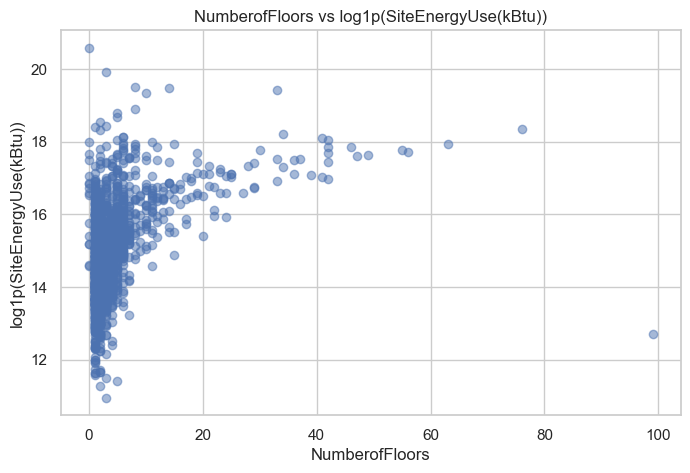

In [53]:
# Variante utile en log sur la cible

plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["NumberofFloors"],
    np.log1p(building_consumption["SiteEnergyUse(kBtu)"]),
    alpha=0.5
)
plt.title("NumberofFloors vs log1p(SiteEnergyUse(kBtu))")
plt.xlabel("NumberofFloors")
plt.ylabel("log1p(SiteEnergyUse(kBtu))")
plt.show()

**Interprétation :**

Le nuage de points entre `NumberofFloors` et `SiteEnergyUse(kBtu)` montre une tendance croissante globale, mais la relation reste assez dispersée.

La majorité des bâtiments possède peu d’étages, et pour un même nombre d’étages, on observe des niveaux de consommation très variés. La transformation logarithmique de la cible améliore la lisibilité, mais confirme que la relation reste plus faible et moins structurée que celle observée avec `PropertyGFATotal`.

Ainsi, `NumberofFloors` semble apporter une information utile sur la structure du bâtiment, mais son pouvoir explicatif paraît plus limité que celui de la surface totale.

### 11.4.2. `NumberofFloors` vs `TotalGHGEmissions`

Nous étudions ensuite la relation entre le nombre d’étages et les émissions totales de CO₂.

Comme pour la consommation énergétique, l’objectif est de vérifier si les bâtiments plus hauts tendent à être plus émetteurs.

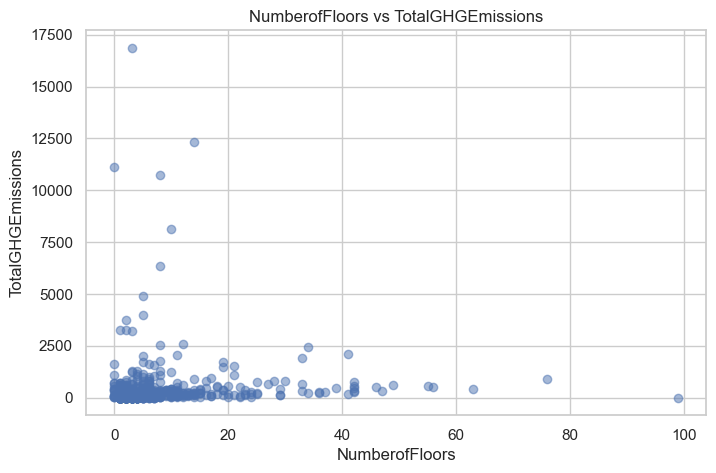

In [54]:
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["NumberofFloors"],
    building_consumption["TotalGHGEmissions"],
    alpha=0.5
)
plt.title("NumberofFloors vs TotalGHGEmissions")
plt.xlabel("NumberofFloors")
plt.ylabel("TotalGHGEmissions")
plt.show()

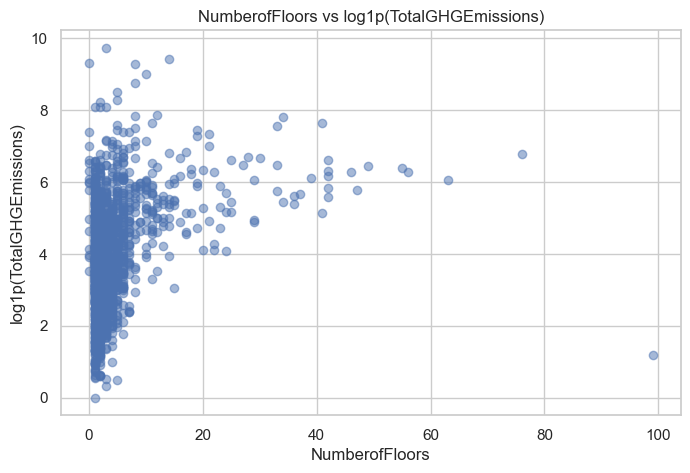

In [55]:
# Variante utile en log sur la cible

plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["NumberofFloors"],
    np.log1p(building_consumption["TotalGHGEmissions"]),
    alpha=0.5
)
plt.title("NumberofFloors vs log1p(TotalGHGEmissions)")
plt.xlabel("NumberofFloors")
plt.ylabel("log1p(TotalGHGEmissions)")
plt.show()

**Interprétation :**

Le nuage de points entre `NumberofFloors` et `TotalGHGEmissions` met en évidence une relation globale croissante, mais celle-ci reste très dispersée.

Même après transformation logarithmique des émissions, la tendance apparaît moins nette que pour la surface totale du bâtiment. Cela suggère que `NumberofFloors` contient une information structurelle utile, mais que cette variable seule n’explique qu’une partie limitée de la variabilité des émissions de CO₂.

Elle pourra donc être conservée dans la modélisation, mais plutôt comme variable complémentaire que comme facteur explicatif principal.

**Conclusion :**

L’analyse bivariée de `NumberofFloors` montre qu’il existe une relation croissante globale entre le nombre d’étages et les deux variables cibles, mais cette relation reste très dispersée.

Comparée à `PropertyGFATotal`, la variable `NumberofFloors` semble moins fortement liée à la consommation énergétique et aux émissions de CO₂. Elle conserve néanmoins un intérêt descriptif important, car elle apporte une information complémentaire sur la structure verticale du bâtiment.

Cette observation pourra justifier, dans la suite du projet, la conservation de `NumberofFloors` et éventuellement la création de variables dérivées combinant surface et hauteur du bâtiment.

**Conclusion intermédiaire :**

Les premières analyses bivariées montrent que la surface totale du bâtiment (`PropertyGFATotal`) est fortement liée aux deux cibles, tandis que le nombre d’étages (`NumberofFloors`) semble apporter une information plus secondaire mais néanmoins utile.

La prochaine étape consiste à examiner la variable `YearBuilt`, afin de vérifier si l’ancienneté du bâtiment entretient elle aussi une relation avec la consommation énergétique et les émissions de CO₂.

## 11.5. Relation entre `YearBuilt` et les deux cibles

L’objectif de cette sous-section est de vérifier si l’année de construction semble avoir un effet visible sur les deux variables cibles.

On cherche notamment à voir :

- si les bâtiments récents consomment moins ;
- si les bâtiments anciens émettent davantage ;
- si une tendance apparaît clairement ou si la relation reste diffuse.

### 11.5.1. `YearBuilt` vs `SiteEnergyUse(kBtu)`

Nous commençons par la relation entre l’année de construction et la consommation énergétique totale du bâtiment.

L’objectif est de vérifier si certaines générations de bâtiments semblent plus énergivores que d’autres, et si une tendance générale apparaît avec l’ancienneté.

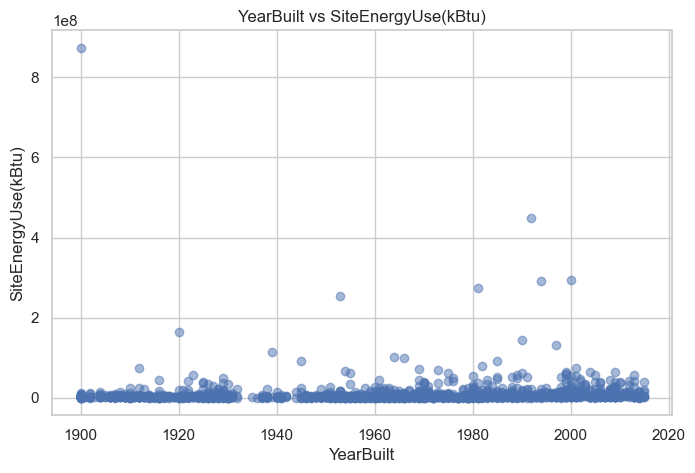

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["YearBuilt"],
    building_consumption["SiteEnergyUse(kBtu)"],
    alpha=0.5
)
plt.title("YearBuilt vs SiteEnergyUse(kBtu)")
plt.xlabel("YearBuilt")
plt.ylabel("SiteEnergyUse(kBtu)")
plt.show()

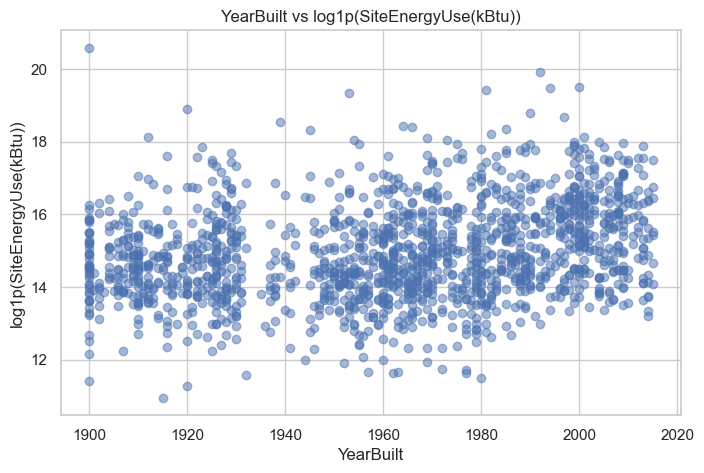

In [57]:
# Variante utile — log sur la cible
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["YearBuilt"],
    np.log1p(building_consumption["SiteEnergyUse(kBtu)"]),
    alpha=0.5
)
plt.title("YearBuilt vs log1p(SiteEnergyUse(kBtu))")
plt.xlabel("YearBuilt")
plt.ylabel("log1p(SiteEnergyUse(kBtu))")
plt.show()

**Interprétation :**

Le nuage de points entre `YearBuilt` et `SiteEnergyUse(kBtu)` ne fait pas apparaître de relation claire entre l’année de construction et la consommation énergétique.

Même après transformation logarithmique, la dispersion reste importante et aucune tendance nette ne se dégage. Des bâtiments anciens comme récents peuvent présenter des niveaux de consommation variés.

Cela suggère que `YearBuilt`, prise isolément, ne constitue pas un facteur explicatif majeur de la consommation énergétique.

### 11.5.2. `YearBuilt` vs `TotalGHGEmissions`

Nous poursuivons avec la relation entre l’année de construction du bâtiment et ses émissions totales de CO₂.

Comme pour la consommation énergétique, nous cherchons à voir si l’ancienneté semble liée au niveau d’émissions.

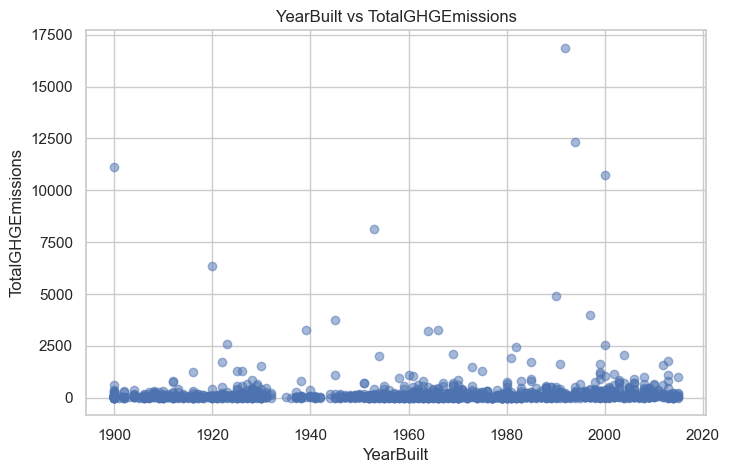

In [58]:
plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["YearBuilt"],
    building_consumption["TotalGHGEmissions"],
    alpha=0.5
)
plt.title("YearBuilt vs TotalGHGEmissions")
plt.xlabel("YearBuilt")
plt.ylabel("TotalGHGEmissions")
plt.show()

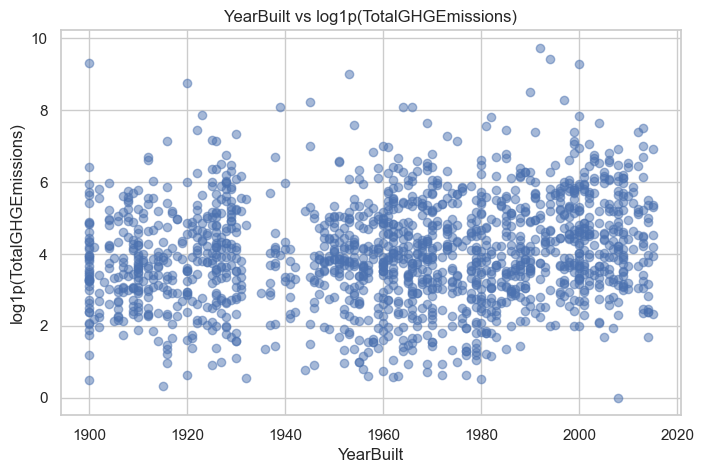

In [59]:
# Variante utile — log sur la cible

plt.figure(figsize=(8, 5))
plt.scatter(
    building_consumption["YearBuilt"],
    np.log1p(building_consumption["TotalGHGEmissions"]),
    alpha=0.5
)
plt.title("YearBuilt vs log1p(TotalGHGEmissions)")
plt.xlabel("YearBuilt")
plt.ylabel("log1p(TotalGHGEmissions)")
plt.show()

**Interprétation :**

Le nuage de points entre `YearBuilt` et `TotalGHGEmissions` ne met pas en évidence de relation claire entre l’année de construction et les émissions de CO₂.

Même après transformation logarithmique, la dispersion reste importante et aucune tendance nette ne se dégage. Les émissions élevées apparaissent à différentes périodes, sans structure particulière.

Cela indique que `YearBuilt` n’est pas une variable fortement explicative des émissions lorsqu’elle est considérée seule.

**Conclusion :**

L’analyse bivariée de `YearBuilt` montre qu’il n’existe pas de relation claire entre l’année de construction et les deux variables cibles.

Contrairement à `PropertyGFATotal`, qui présente une relation forte avec la consommation énergétique et les émissions, `YearBuilt` apparaît comme une variable faiblement explicative lorsqu’elle est considérée seule.

Cela suggère que l’effet de l’ancienneté du bâtiment est indirect et probablement médié par d’autres facteurs, comme les rénovations, les usages ou les équipements.

Dans la suite du projet, il pourra être pertinent de transformer cette variable (par exemple en âge du bâtiment) ou de l’utiliser en combinaison avec d’autres variables.

## Conclusion de l’analyse bivariée

L’analyse bivariée a permis d’identifier les relations principales entre les variables explicatives et les deux cibles.

- `PropertyGFATotal` apparaît comme la variable la plus fortement liée aux cibles ;
- `NumberofFloors` apporte une information complémentaire, mais plus diffuse ;
- `YearBuilt` semble avoir un effet indirect et peu marqué lorsqu’elle est considérée seule.

Ces observations vont maintenant guider les choix de feature engineering, afin de construire des variables plus pertinentes pour la modélisation.

## 11.6. Analyse spatiale des deux cibles

Afin de compléter l’analyse exploratoire, nous étudions ici la répartition spatiale des deux variables cibles dans Seattle :

- la consommation énergétique totale ;
- les émissions totales de CO₂.

Cette étape permet d’examiner si certaines zones géographiques concentrent davantage de bâtiments fortement consommateurs ou fortement émetteurs.

### 11.6.1. Carte de chaleur de la consommation énergétique

Nous construisons d’abord une carte de chaleur de `SiteEnergyUse(kBtu)` à partir des coordonnées géographiques des bâtiments.

Comme la variable présente une forte asymétrie, nous utilisons `log1p(SiteEnergyUse(kBtu))` comme poids dans la heatmap afin de réduire l’effet des valeurs extrêmes.

In [60]:
heatmap_energy_df = building_consumption[["Latitude", "Longitude", "SiteEnergyUse(kBtu)"]].copy()

heatmap_energy_df["EnergyWeight"] = np.log1p(heatmap_energy_df["SiteEnergyUse(kBtu)"])
heatmap_energy_df["EnergyWeight"] = (
    heatmap_energy_df["EnergyWeight"] / heatmap_energy_df["EnergyWeight"].max()
)

seattle_energy_map = Map(
    location=[heatmap_energy_df["Latitude"].mean(), heatmap_energy_df["Longitude"].mean()],
    zoom_start=11,
    tiles="cartodbpositron"
)

HeatMap(
    heatmap_energy_df[["Latitude", "Longitude", "EnergyWeight"]].values.tolist(),
    radius=18,
    blur=20,
    min_opacity=0.25
).add_to(seattle_energy_map)

seattle_energy_map

**Interprétation :**

La carte de chaleur de la consommation énergétique montre que les bâtiments les plus consommateurs ne sont pas répartis uniformément dans Seattle. Une concentration particulièrement marquée apparaît dans la zone centrale, avec d’autres zones secondaires au nord et au sud.

Cette visualisation suggère que la dimension géographique joue un rôle descriptif important dans le problème étudié. Elle est cohérente avec l’idée que les zones les plus denses ou les plus riches en bâtiments tertiaires importants concentrent davantage de consommations élevées.

### 11.6.2. Carte de chaleur des émissions de CO₂

Nous construisons ensuite une carte de chaleur de `TotalGHGEmissions`, afin d’examiner si la répartition spatiale des émissions présente des similitudes ou des différences avec celle de la consommation énergétique.

Comme pour l’énergie, nous utilisons `log1p(TotalGHGEmissions)` afin de rendre la visualisation plus lisible.

In [61]:
heatmap_ghg_df = building_consumption[["Latitude", "Longitude", "TotalGHGEmissions"]].copy()

heatmap_ghg_df["GHGWeight"] = np.log1p(heatmap_ghg_df["TotalGHGEmissions"])
heatmap_ghg_df["GHGWeight"] = (
    heatmap_ghg_df["GHGWeight"] / heatmap_ghg_df["GHGWeight"].max()
)

seattle_ghg_map = Map(
    location=[heatmap_ghg_df["Latitude"].mean(), heatmap_ghg_df["Longitude"].mean()],
    zoom_start=11,
    tiles="cartodbpositron"
)

HeatMap(
    heatmap_ghg_df[["Latitude", "Longitude", "GHGWeight"]].values.tolist(),
    radius=18,
    blur=20,
    min_opacity=0.25
).add_to(seattle_ghg_map)

seattle_ghg_map

**Interprétation :**

La carte de chaleur des émissions de CO₂ présente une structure spatiale proche de celle observée pour la consommation énergétique : une zone centrale dominante, complétée par plusieurs concentrations secondaires.

Cette similarité est cohérente avec la forte relation observée entre `SiteEnergyUse(kBtu)` et `TotalGHGEmissions`. Elle suggère que les bâtiments fortement émetteurs sont souvent localisés dans les mêmes zones que les bâtiments les plus énergivores.

**Conclusion de l’analyse spatiale :**

L’analyse spatiale des deux cibles complète utilement l’analyse exploratoire. Elle montre que la consommation énergétique et les émissions de CO₂ présentent des concentrations géographiques similaires, avec une forte intensité dans la zone centrale de Seattle.

Ces résultats renforcent l’intérêt descriptif des variables de localisation dans le projet et sont cohérents avec la forte corrélation observée entre les deux cibles.

Cette lecture spatiale complète l’analyse exploratoire. Nous pouvons maintenant poursuivre avec la création de nouvelles variables et l’étude plus systématique des relations entre variables explicatives et variables cibles.

#### TERMINER L'ANALYSE EXPLORATOIRE 

**FAIT**

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Quelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

# Modélisation 

## 12. Feature engineering

L’objectif du feature engineering est de créer des variables plus informatives à partir des données disponibles, afin d’aider les modèles à mieux expliquer la consommation énergétique et les émissions de CO₂.

Les nouvelles variables créées doivent respecter plusieurs principes :

- avoir un sens métier clair ;
- être potentiellement utiles pour les deux cibles ;
- ne pas introduire de data leakage ;
- apporter une information complémentaire aux variables déjà présentes.

Dans cette partie, nous construisons progressivement plusieurs variables dérivées liées :

- à l’ancienneté du bâtiment ;
- à sa structure ;
- à sa répartition de surface ;
- et à l’échelle de certaines grandeurs.

### 12.1. Création de `BuildingAge`

Plutôt que d’utiliser directement `YearBuilt`, nous créons une variable `BuildingAge`, qui représente l’âge du bâtiment au moment du relevé.

Cette transformation est plus intuitive que l’année brute : elle permet d’interpréter plus facilement l’effet de l’ancienneté sur la consommation énergétique et les émissions.

In [62]:
building_consumption["BuildingAge"] = (
    building_consumption["DataYear"] - building_consumption["YearBuilt"]
)

building_consumption[["YearBuilt", "DataYear", "BuildingAge"]].head()

,YearBuilt,DataYear,BuildingAge
0,1927,2016,89
1,1996,2016,20
2,1969,2016,47
3,1926,2016,90
4,1980,2016,36


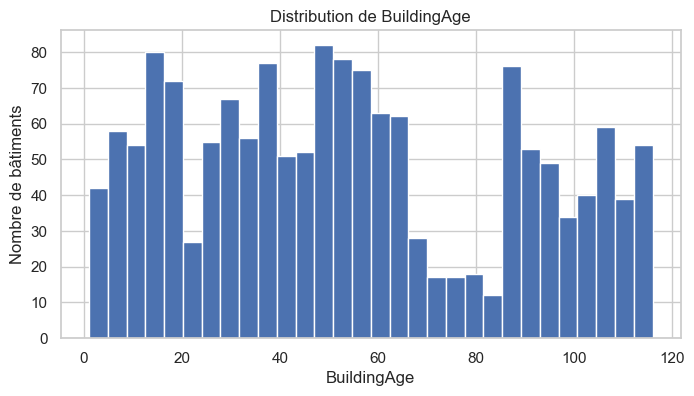

In [63]:
# On peut regarder rapidement sa distribution.

plt.figure(figsize=(8, 4))
building_consumption["BuildingAge"].hist(bins=30)
plt.title("Distribution de BuildingAge")
plt.xlabel("BuildingAge")
plt.ylabel("Nombre de bâtiments")
plt.show()

**Interprétation :**

La variable `BuildingAge` traduit directement l’ancienneté du bâtiment au moment du relevé. Elle est plus simple à interpréter que `YearBuilt`, car elle permet d’étudier directement l’effet de l’âge sur les deux cibles.

Cette transformation est cohérente avec l’analyse bivariée précédente, qui suggérait que l’année de construction brute n’était pas la forme la plus pertinente pour capter l’effet temporel.

Sa distribution montre que le dataset contient à la fois des bâtiments très récents et des bâtiments très anciens, avec une plage d’âges large allant approximativement de 1 à 116 ans. Cette variable semble donc pertinente pour représenter l’effet potentiel de l’ancienneté sur la consommation énergétique et les émissions de CO₂.

### 12.2. Création de `GFA_per_floor`

Nous créons une variable `GFA_per_floor`, qui représente la surface moyenne par étage.

Cette variable combine la taille totale du bâtiment et sa structure verticale. Elle peut permettre de distinguer différents profils de bâtiments ayant une surface totale similaire mais une organisation spatiale différente.

In [64]:
building_consumption["GFA_per_floor"] = (
    building_consumption["PropertyGFATotal"] / building_consumption["NumberofFloors"]
)

building_consumption["GFA_per_floor"] = building_consumption["GFA_per_floor"].replace(
    [np.inf, -np.inf], np.nan
)

building_consumption[["PropertyGFATotal", "NumberofFloors", "GFA_per_floor"]].head()

,PropertyGFATotal,NumberofFloors,GFA_per_floor
0,88434,12,7369.500000
1,103566,11,9415.090909
2,956110,41,23319.756098
3,61320,10,6132.000000
4,175580,18,9754.444444


**Interprétation :**

La variable `GFA_per_floor` représente une mesure simplifiée de la surface moyenne par étage. Elle apporte une information complémentaire à `PropertyGFATotal` et `NumberofFloors`, en combinant la taille du bâtiment et sa structure verticale.

Cette variable peut être utile pour distinguer des bâtiments de même taille globale mais d’organisation différente.

Les statistiques descriptives montrent toutefois une forte dispersion et la présence de valeurs extrêmes, ce qui suggère que certains bâtiments ont une surface moyenne par étage très importante. Cette variable reste néanmoins pertinente pour distinguer différents profils structurels de bâtiments.

### 12.3. Création de `ParkingRatio`

Nous créons une variable `ParkingRatio`, qui mesure la part de la surface totale occupée par le parking.

Cette variable peut apporter une information utile sur la structure du bâtiment et sur son usage, en distinguant par exemple des bâtiments fortement liés à l’automobile ou à de grandes zones de stationnement.

In [65]:
building_consumption["ParkingRatio"] = (
    building_consumption["PropertyGFAParking"] / building_consumption["PropertyGFATotal"]
)

building_consumption["ParkingRatio"] = building_consumption["ParkingRatio"].replace(
    [np.inf, -np.inf], np.nan
)

building_consumption[["PropertyGFAParking", "PropertyGFATotal", "ParkingRatio"]].head()

,PropertyGFAParking,PropertyGFATotal,ParkingRatio
0,0,88434,0.000000
1,15064,103566,0.145453
2,196718,956110,0.205748
3,0,61320,0.000000
4,62000,175580,0.353115


**Interprétation :**

La variable `ParkingRatio` mesure la part relative du parking dans la surface totale du bâtiment. Elle peut aider à différencier des profils de bâtiments qui, à surface totale comparable, n’ont pas la même organisation spatiale ni les mêmes usages.

Les statistiques montrent que cette variable est nulle pour une grande partie des bâtiments, ce qui indique que beaucoup d’observations ne comportent pas de surface de parking significative.

En revanche, certaines observations présentent un ratio élevé, ce qui permet de distinguer des profils de bâtiments plus fortement associés au stationnement. Cette variable semble donc utile pour enrichir la description structurelle du site, même si son information est très concentrée sur une partie du dataset.

### 12.4. Création de `BuildingRatio`

Nous créons une variable `BuildingRatio`, qui mesure la part de la surface totale réellement occupée par les bâtiments eux-mêmes.

Cette variable complète `ParkingRatio` et permet de mieux décrire la composition globale de la surface du site.

In [66]:
building_consumption["BuildingRatio"] = (
    building_consumption["PropertyGFABuilding(s)"] / building_consumption["PropertyGFATotal"]
)

building_consumption["BuildingRatio"] = building_consumption["BuildingRatio"].replace(
    [np.inf, -np.inf], np.nan
)

building_consumption[["PropertyGFABuilding(s)", "PropertyGFATotal", "BuildingRatio"]].head()

,PropertyGFABuilding(s),PropertyGFATotal,BuildingRatio
0,88434,88434,1.000000
1,88502,103566,0.854547
2,759392,956110,0.794252
3,61320,61320,1.000000
4,113580,175580,0.646885


**Interprétation :**

La variable `BuildingRatio` mesure la part de la surface totale réellement occupée par les bâtiments. Elle permet de compléter la description du site en distinguant la part bâtie de la part dédiée au parking.

Les statistiques montrent que ce ratio est très souvent proche de 1, ce qui signifie que la majorité des sites du dataset est principalement composée de surface bâtie.

Cette variable est cohérente et complète `ParkingRatio`, mais sa faible variabilité relative suggère qu’elle pourrait être moins informative que d’autres variables issues du feature engineering.

### 12.5. Création de versions logarithmiques des surfaces

L’analyse exploratoire a montré que certaines variables de surface, en particulier `PropertyGFATotal`, sont très asymétriques. Nous créons donc des versions logarithmiques afin de réduire l’effet des valeurs extrêmes et de faciliter la modélisation.

In [67]:
building_consumption["LogPropertyGFATotal"] = np.log1p(building_consumption["PropertyGFATotal"])
building_consumption["LogLargestPropertyUseTypeGFA"] = np.log1p(
    building_consumption["LargestPropertyUseTypeGFA"]
)

building_consumption[[
    "PropertyGFATotal",
    "LogPropertyGFATotal",
    "LargestPropertyUseTypeGFA",
    "LogLargestPropertyUseTypeGFA"
]].head()

,PropertyGFATotal,LogPropertyGFATotal,LargestPropertyUseTypeGFA,LogLargestPropertyUseTypeGFA
0,88434,11.390023,88434.0,11.390023
1,103566,11.547974,83880.0,11.337154
2,956110,13.770629,756493.0,13.536450
3,61320,11.023878,61320.0,11.023878
4,175580,12.075856,123445.0,11.723559


**Interprétation :**

Les variables logarithmiques permettent de réduire l’effet des très grandes surfaces et de rendre les distributions plus régulières. Elles pourront être utiles pour certains modèles, notamment si les relations observées sont plus lisibles en échelle logarithmique.

Leur intérêt principal est de réduire l’effet des très grandes valeurs et de rendre les distributions plus régulières. Cela est cohérent avec l’analyse exploratoire précédente, qui avait montré une forte asymétrie pour les variables de surface.

Ces variables logarithmiques semblent donc particulièrement pertinentes pour la suite de la modélisation.

### 12.6. Vérification rapide des nouvelles variables

Avant de poursuivre, nous affichons un aperçu des nouvelles variables créées afin de vérifier qu’elles sont cohérentes et correctement calculées.

In [68]:
new_features = [
    "BuildingAge",
    "GFA_per_floor",
    "ParkingRatio",
    "BuildingRatio",
    "LogPropertyGFATotal",
    "LogLargestPropertyUseTypeGFA"
]

building_consumption[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
BuildingAge,1547.0,54.389140,32.871597,1.000000,27.000000,51.000000,86.000000,1.160000e+02
GFA_per_floor,1531.0,33316.711736,48616.298935,221.696970,12960.000000,22180.000000,36422.000000,1.100000e+06
ParkingRatio,1547.0,0.065377,0.144077,0.000000,0.000000,0.000000,0.000000,8.950225e-01
BuildingRatio,1547.0,0.934623,0.144077,0.104977,1.000000,1.000000,1.000000,1.000000e+00
LogPropertyGFATotal,1547.0,11.047564,0.973362,9.331318,10.269640,10.781869,11.587586,1.604769e+01
LogLargestPropertyUseTypeGFA,1543.0,10.846212,0.985345,8.640649,10.127091,10.644448,11.430288,1.604769e+01


**Interprétation globale :**

Les nouvelles variables créées dans cette étape de feature engineering sont globalement cohérentes et correctement calculées.

Elles apportent trois types d’information :

- une information temporelle avec `BuildingAge` ;
- une information structurelle avec `GFA_per_floor`, `ParkingRatio` et `BuildingRatio` ;
- une information d’échelle stabilisée avec `LogPropertyGFATotal` et `LogLargestPropertyUseTypeGFA`.

Toutes ces variables ont un sens métier ou statistique clair. Certaines, comme `LogPropertyGFATotal` ou `BuildingAge`, semblent particulièrement prometteuses pour la suite, tandis que d’autres devront être réévaluées plus finement pour vérifier qu’elles apportent bien une information complémentaire au modèle.

## 12.7. Vérification du sens des nouvelles variables pour le modèle

Après la création des nouvelles variables, nous vérifions ici qu’elles ont bien un sens pour la modélisation.

L’objectif n’est pas seulement de créer davantage de variables, mais de s’assurer que chacune d’elles :

- repose sur une intuition métier ou statistique claire ;
- peut aider à prédire les deux cibles ;
- n’introduit pas de fuite de données ;
- et apporte potentiellement une information complémentaire aux variables déjà présentes.

### 12.7.1. Analyse qualitative des nouvelles variables

- **`BuildingAge`** : variable temporelle plus intuitive que `YearBuilt`. Elle peut capter indirectement l’effet de l’ancienneté du bâtiment sur ses performances énergétiques.
- **`GFA_per_floor`** : combine la surface totale et le nombre d’étages. Elle peut distinguer des bâtiments étalés horizontalement de bâtiments plus compacts.
- **`ParkingRatio`** : mesure la part de la surface dédiée au parking. Elle peut apporter une information sur la structure du site et certains usages du bâtiment.
- **`BuildingRatio`** : mesure la part réellement bâtie dans la surface totale. Elle complète `ParkingRatio`, mais peut être partiellement redondante avec elle.
- **`LogPropertyGFATotal`** : version logarithmique de la surface totale, utile pour réduire l’effet des valeurs extrêmes.
- **`LogLargestPropertyUseTypeGFA`** : version logarithmique de la surface associée à l’usage principal. Elle peut compléter la variable de surface totale en se concentrant sur l’usage dominant.

### 12.7.2. Vérification du risque de data leakage

Les variables créées dans cette étape n’utilisent pas directement les variables cibles (`SiteEnergyUse(kBtu)` et `TotalGHGEmissions`), ni des colonnes qui en seraient des transformations directes.

Elles sont construites uniquement à partir de caractéristiques descriptives ou structurelles du bâtiment :

- année de construction ;
- surface totale ;
- surface bâtie ;
- surface de parking ;
- nombre d’étages ;
- surface liée à l’usage principal.

Ces variables sont donc compatibles avec une démarche de modélisation supervisée sans fuite de données.

### 12.7.3. Variables a priori les plus prometteuses

À ce stade de l’analyse, certaines nouvelles variables semblent particulièrement intéressantes :

- **`BuildingAge`**, car elle reformule `YearBuilt` de manière plus directement interprétable ;
- **`LogPropertyGFATotal`**, car la surface totale s’est révélée très liée aux deux cibles et sa version logarithmique réduit l’effet des valeurs extrêmes ;
- **`LogLargestPropertyUseTypeGFA`**, qui apporte une information complémentaire sur l’usage principal du bâtiment.

D’autres variables semblent utiles mais plus exploratoires :

- **`GFA_per_floor`**, qui combine taille et structure verticale ;
- **`ParkingRatio`**, qui distingue certains profils de sites.

Enfin, **`BuildingRatio`** est cohérente mais pourrait être partiellement redondante avec `ParkingRatio`, ce qui devra être vérifié dans la suite.

**Conclusion intermédiaire :**

Les nouvelles variables créées dans cette étape sont globalement cohérentes avec le problème étudié. Elles reposent sur des caractéristiques structurelles, spatiales ou temporelles du bâtiment, et ne présentent pas de risque direct de fuite de données.

Certaines variables, comme `BuildingAge` ou `LogPropertyGFATotal`, semblent particulièrement prometteuses, tandis que d’autres devront être évaluées plus finement pour vérifier qu’elles apportent une information réellement complémentaire.

La prochaine étape consiste maintenant à examiner les relations entre ces nouvelles variables et les cibles, puis à étudier les corrélations avant de passer à la préparation des données pour la modélisation.

## 13. Analyse des corrélations

Nous étudions maintenant les corrélations entre les principales variables numériques du dataset et les deux variables cibles.

L’objectif est de :

- identifier les variables les plus fortement liées à la consommation énergétique et aux émissions de CO₂ ;
- repérer d’éventuelles redondances entre variables ;
- vérifier si les nouvelles variables créées dans le feature engineering apportent une information complémentaire.

In [69]:
# sélection des colonnes numériques
numeric_corr_cols = [
    "PropertyGFATotal",
    "NumberofFloors",
    "YearBuilt",
    "ENERGYSTARScore",
    "LargestPropertyUseTypeGFA",
    "BuildingAge",
    "GFA_per_floor",
    "ParkingRatio",
    "BuildingRatio",
    "LogPropertyGFATotal",
    "LogLargestPropertyUseTypeGFA",
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]

corr_df = building_consumption[numeric_corr_cols].copy()
corr_df.head()

,PropertyGFATotal,NumberofFloors,YearBuilt,ENERGYSTARScore,LargestPropertyUseTypeGFA,BuildingAge,GFA_per_floor,ParkingRatio,BuildingRatio,LogPropertyGFATotal,LogLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions
0,88434,12,1927,60.0,88434.0,89,7369.500000,0.000000,1.000000,11.390023,11.390023,7226362.5,249.98
1,103566,11,1996,61.0,83880.0,20,9415.090909,0.145453,0.854547,11.547974,11.337154,8387933.0,295.86
2,956110,41,1969,43.0,756493.0,47,23319.756098,0.205748,0.794252,13.770629,13.536450,72587024.0,2089.28
3,61320,10,1926,56.0,61320.0,90,6132.000000,0.000000,1.000000,11.023878,11.023878,6794584.0,286.43
4,175580,18,1980,75.0,123445.0,36,9754.444444,0.353115,0.646885,12.075856,11.723559,14172606.0,505.01


**Interprétation :**

La table utilisée pour le calcul des corrélations regroupe les principales variables numériques initiales, les nouvelles variables issues du feature engineering, ainsi que les deux variables cibles.

Cette sélection permet d’évaluer à la fois :

- les relations entre variables explicatives ;
- les redondances éventuelles ;
- et surtout le lien entre chaque variable et les deux cibles du projet.

### 13.1. Matrice de corrélation des variables numériques

Nous calculons d’abord une matrice de corrélation sur les principales variables numériques, afin d’obtenir une vue d’ensemble des relations linéaires entre variables.

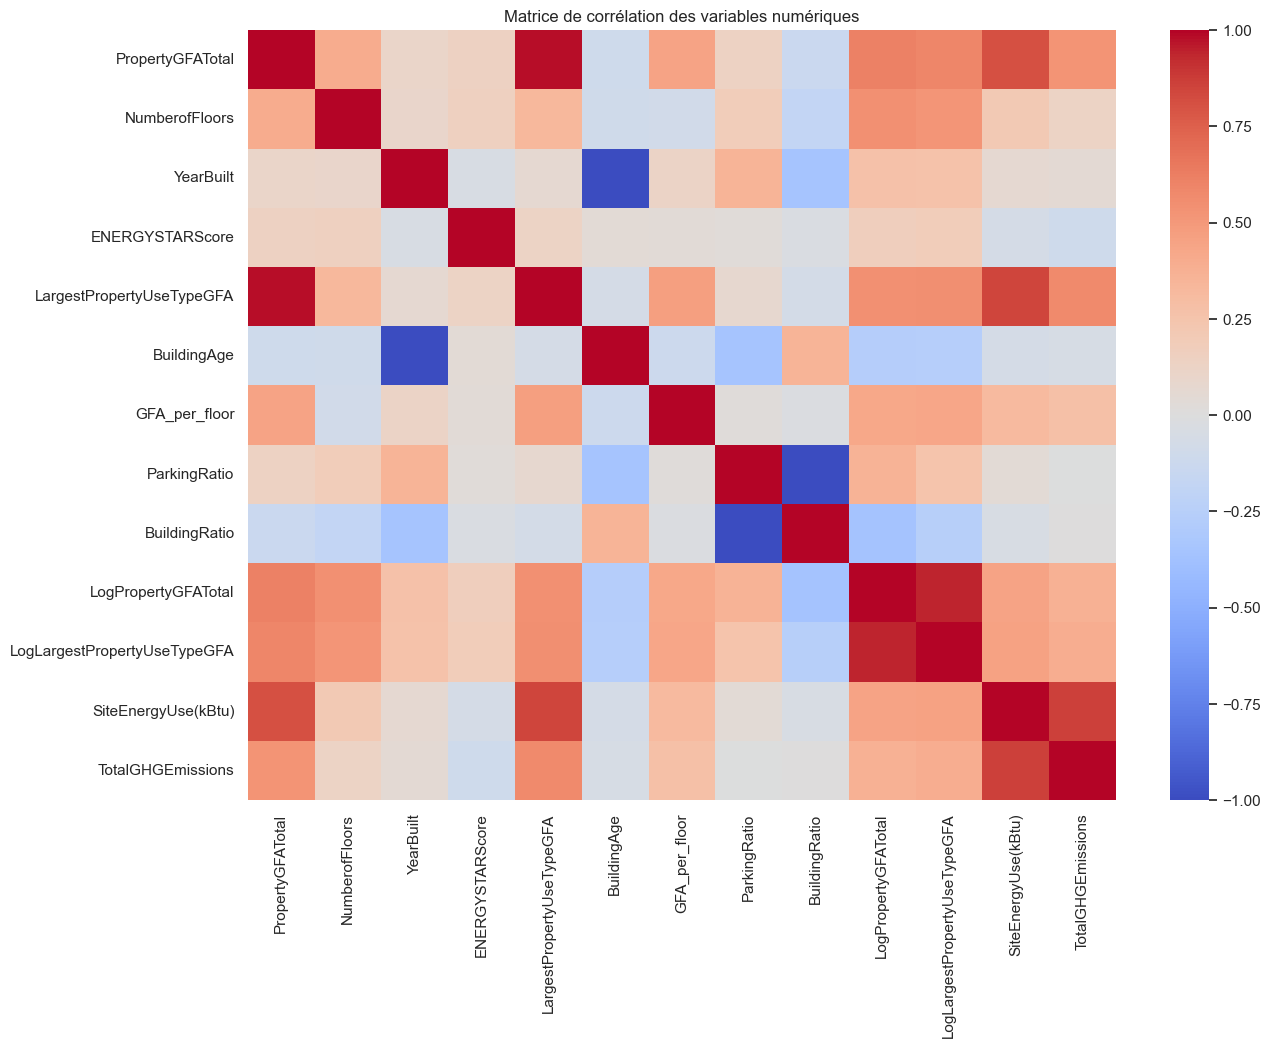

In [70]:
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

**Interprétation :**

La matrice de corrélation montre que les variables les plus fortement liées aux deux cibles sont principalement les variables de surface, en particulier `PropertyGFATotal` et `LargestPropertyUseTypeGFA`.

Elle montre également une forte corrélation entre les deux variables cibles (`SiteEnergyUse(kBtu)` et `TotalGHGEmissions`), ce qui confirme qu’elles évoluent globalement dans le même sens.

À l’inverse, `YearBuilt`, `BuildingAge`, `ParkingRatio` et `BuildingRatio` présentent des corrélations plus faibles avec les cibles. Enfin, certaines variables apparaissent fortement redondantes entre elles, comme `YearBuilt` et `BuildingAge`, ou encore `ParkingRatio` et `BuildingRatio`, ce qui devra être pris en compte dans la préparation des données pour la modélisation.

### 13.2. Corrélations des variables avec les deux cibles

Pour faciliter l’interprétation, nous extrayons maintenant les corrélations entre chaque variable numérique et les deux variables cibles :

- `SiteEnergyUse(kBtu)`
- `TotalGHGEmissions`

In [71]:
target_corr = corr_matrix[["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]].sort_values(
    by="SiteEnergyUse(kBtu)", ascending=False
)

target_corr

,SiteEnergyUse(kBtu),TotalGHGEmissions
SiteEnergyUse(kBtu),1.000000,0.860017
TotalGHGEmissions,0.860017,1.000000
LargestPropertyUseTypeGFA,0.846840,0.575097
PropertyGFATotal,0.809620,0.527101
LogLargestPropertyUseTypeGFA,0.456709,0.390638
LogPropertyGFATotal,0.452773,0.370051
GFA_per_floor,0.312560,0.274911
NumberofFloors,0.216410,0.127025
YearBuilt,0.065765,0.052727
ParkingRatio,0.042172,-0.001529


**Relation entre les deux cibles :**

La corrélation entre `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` est de **0.860**, ce qui indique une relation forte et positive entre les deux variables.

Ce résultat confirme que les bâtiments les plus consommateurs d’énergie sont généralement aussi les plus émetteurs de CO₂. Il justifie donc l’étude conjointe des deux cibles, ainsi que le test d’un modèle multi-output dans la suite du projet.

In [72]:
# variante plus lisible

target_corr.round(3)

,SiteEnergyUse(kBtu),TotalGHGEmissions
SiteEnergyUse(kBtu),1.000,0.860
TotalGHGEmissions,0.860,1.000
LargestPropertyUseTypeGFA,0.847,0.575
PropertyGFATotal,0.810,0.527
LogLargestPropertyUseTypeGFA,0.457,0.391
LogPropertyGFATotal,0.453,0.370
GFA_per_floor,0.313,0.275
NumberofFloors,0.216,0.127
YearBuilt,0.066,0.053
ParkingRatio,0.042,-0.002


**Variables les plus fortement liées aux cibles :**

Les corrélations montrent que les variables de surface sont les plus liées aux deux cibles. En particulier :

- `LargestPropertyUseTypeGFA` présente la corrélation la plus forte avec `SiteEnergyUse(kBtu)` (**0.847**) et `TotalGHGEmissions` (**0.575**) ;
- `PropertyGFATotal` suit de près, avec des corrélations de **0.810** et **0.527**.

Ces résultats confirment que la taille du bâtiment, et plus particulièrement la surface associée à son usage principal, constitue un déterminant majeur de la consommation énergétique et des émissions de CO₂.

### 13.3. Visualisation focalisée des corrélations avec les cibles

Nous représentons maintenant uniquement les corrélations entre les variables numériques et les deux cibles, afin de repérer plus facilement les variables les plus informatives.

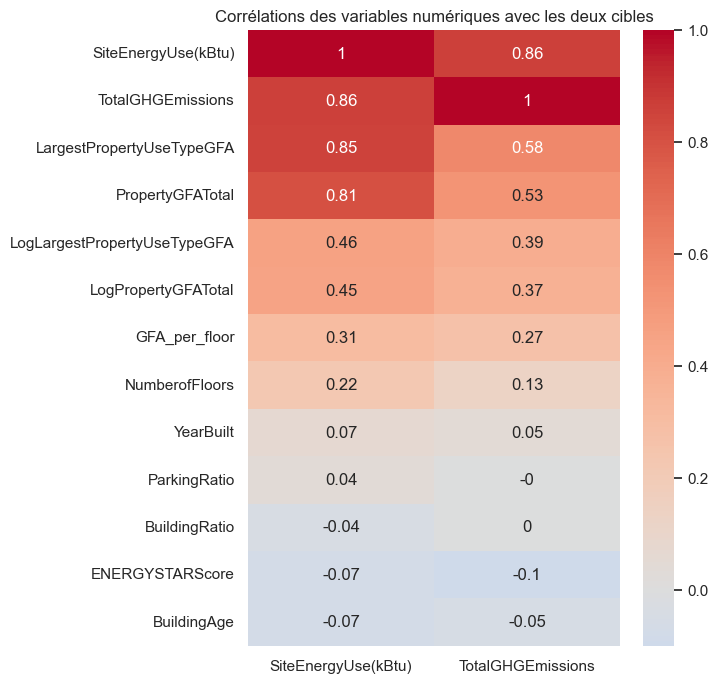

In [73]:
plt.figure(figsize=(6, 8))
sns.heatmap(
    target_corr.round(2),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Corrélations des variables numériques avec les deux cibles")
plt.show()

**Apport des variables créées :**

Les nouvelles variables issues du feature engineering n’apportent pas toutes la même quantité d’information.

- `GFA_per_floor` présente des corrélations modérées avec les deux cibles (**0.31** avec l’énergie, **0.27** avec le CO₂), ce qui suggère qu’elle capture une information structurelle complémentaire.
- `LogPropertyGFATotal` et `LogLargestPropertyUseTypeGFA` présentent des corrélations intermédiaires. Même si elles sont moins fortement corrélées que les variables brutes, elles restent intéressantes car elles réduisent l’effet des valeurs extrêmes.
- `BuildingAge` présente des corrélations faibles, ce qui confirme que l’effet de l’ancienneté du bâtiment est peu marqué lorsqu’il est considéré seul.
- `ParkingRatio` et `BuildingRatio` présentent des corrélations quasi nulles avec les deux cibles, ce qui suggère qu’elles sont moins informatives à ce stade.

**Redondances entre variables :**

La matrice de corrélation met en évidence plusieurs relations fortes entre variables explicatives :

- `PropertyGFATotal` et `LargestPropertyUseTypeGFA` sont très fortement corrélées ;
- `LogPropertyGFATotal` et `LogLargestPropertyUseTypeGFA` le sont également ;
- `YearBuilt` et `BuildingAge` sont logiquement fortement corrélées négativement ;
- `ParkingRatio` et `BuildingRatio` présentent une relation inverse marquée.

Ces résultats suggèrent que certaines variables sont partiellement redondantes. Il faudra en tenir compte dans la préparation des données pour la modélisation, en particulier pour les modèles sensibles à la colinéarité.

**Conclusion :**

L’analyse des corrélations confirme que les variables de surface sont les plus fortement liées aux deux cibles. En particulier, `LargestPropertyUseTypeGFA` et `PropertyGFATotal` apparaissent comme les variables les plus informatives.

Le feature engineering apporte également des variables intéressantes, notamment :

- `LogPropertyGFATotal`
- `LogLargestPropertyUseTypeGFA`
- `GFA_per_floor`

En revanche, certaines variables créées comme `ParkingRatio`, `BuildingRatio` ou `BuildingAge` présentent des corrélations faibles avec les cibles et devront être réévaluées plus finement dans la suite.

Cette étape permet donc d’orienter la sélection des variables pour la modélisation, tout en mettant en évidence certaines redondances à surveiller.

### Feature Engineering

**FAIT**

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

## 14. Préparation des données pour la modélisation

Après l’exploration des données et le feature engineering, nous préparons maintenant les variables qui seront utilisées dans les modèles.

Cette étape consiste à :

- sélectionner les variables explicatives les plus pertinentes ;
- distinguer les variables numériques et catégorielles ;
- définir une stratégie de prétraitement adaptée ;
- préparer une base commune pour la modélisation des deux cibles et pour le modèle multi-output.

### 14.1. Sélection des variables explicatives

Nous retenons ici un ensemble de variables explicatives fondé sur l’analyse exploratoire, les corrélations observées et le sens métier des variables.

L’objectif est de conserver des variables :

- suffisamment informatives ;
- non directement dérivées des cibles ;
- et raisonnables à interpréter pour la modélisation.

In [74]:
selected_features = [
    "PropertyGFATotal",
    "NumberofFloors",
    "ENERGYSTARScore",
    "LargestPropertyUseTypeGFA",
    "BuildingAge",
    "GFA_per_floor",
    "LogPropertyGFATotal",
    "LogLargestPropertyUseTypeGFA",
    "PrimaryPropertyType",
    "Neighborhood",
    "BuildingType"
]

model_df = building_consumption[selected_features + [
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]].copy()

model_df.head()

,PropertyGFATotal,NumberofFloors,ENERGYSTARScore,LargestPropertyUseTypeGFA,BuildingAge,GFA_per_floor,LogPropertyGFATotal,LogLargestPropertyUseTypeGFA,PrimaryPropertyType,Neighborhood,BuildingType,SiteEnergyUse(kBtu),TotalGHGEmissions
0,88434,12,60.0,88434.0,89,7369.500000,11.390023,11.390023,Hotel,DOWNTOWN,NonResidential,7226362.5,249.98
1,103566,11,61.0,83880.0,20,9415.090909,11.547974,11.337154,Hotel,DOWNTOWN,NonResidential,8387933.0,295.86
2,956110,41,43.0,756493.0,47,23319.756098,13.770629,13.536450,Hotel,DOWNTOWN,NonResidential,72587024.0,2089.28
3,61320,10,56.0,61320.0,90,6132.000000,11.023878,11.023878,Hotel,DOWNTOWN,NonResidential,6794584.0,286.43
4,175580,18,75.0,123445.0,36,9754.444444,12.075856,11.723559,Hotel,DOWNTOWN,NonResidential,14172606.0,505.01


**Interprétation :**

Le sous-dataframe `model_df` regroupe les variables explicatives retenues à partir de l’analyse exploratoire, des corrélations et du feature engineering. Il contient à la fois :

- des variables numériques structurelles ;
- des variables dérivées créées dans la phase de feature engineering ;
- des variables catégorielles liées à l’usage et à la localisation ;
- ainsi que les deux variables cibles.

Cette structure constitue une base cohérente pour la modélisation mono-sortie et multi-output.

### 14.2. Distinction entre variables numériques et catégorielles

Les variables retenues ne seront pas traitées de la même manière selon leur nature :

- les variables numériques pourront être imputées puis éventuellement standardisées ;
- les variables catégorielles devront être encodées avant d’être utilisées dans les modèles.

In [75]:
numeric_features = [
    "PropertyGFATotal",
    "NumberofFloors",
    "ENERGYSTARScore",
    "LargestPropertyUseTypeGFA",
    "BuildingAge",
    "GFA_per_floor",
    "LogPropertyGFATotal",
    "LogLargestPropertyUseTypeGFA"
]

categorical_features = [
    "PrimaryPropertyType",
    "Neighborhood",
    "BuildingType"
]

print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)

Variables numériques : ['PropertyGFATotal', 'NumberofFloors', 'ENERGYSTARScore', 'LargestPropertyUseTypeGFA', 'BuildingAge', 'GFA_per_floor', 'LogPropertyGFATotal', 'LogLargestPropertyUseTypeGFA']
Variables catégorielles : ['PrimaryPropertyType', 'Neighborhood', 'BuildingType']


**Interprétation :**

La séparation entre variables numériques et variables catégorielles est claire et cohérente avec la nature des données.

Cette distinction est essentielle pour la suite, car elle permet de définir des stratégies de prétraitement adaptées :

- imputation et éventuellement standardisation pour les variables numériques ;
- imputation puis encodage pour les variables catégorielles.

### 14.3. Définition des variables d’entrée et des variables cibles

Nous définissons maintenant :

- `X` : les variables explicatives ;
- `y_energy` : la cible de consommation énergétique ;
- `y_ghg` : la cible d’émissions de CO₂ ;
- `y_multi` : la cible multi-output contenant les deux sorties.

In [76]:
X = model_df[selected_features]

y_energy = model_df["SiteEnergyUse(kBtu)"]
y_ghg = model_df["TotalGHGEmissions"]

y_multi = model_df[["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]]

print("Shape de X :", X.shape)
print("Shape de y_energy :", y_energy.shape)
print("Shape de y_ghg :", y_ghg.shape)
print("Shape de y_multi :", y_multi.shape)

Shape de X : (1547, 11)
Shape de y_energy : (1547,)
Shape de y_ghg : (1547,)
Shape de y_multi : (1547, 2)


**Interprétation :**

Les dimensions des jeux de données sont cohérentes :

- `X` contient **1547 observations** et **11 variables explicatives** ;
- `y_energy` et `y_ghg` correspondent chacune à une cible mono-sortie ;
- `y_multi` contient les deux cibles simultanément, ce qui permettra de tester un modèle multi-output.

Cette étape confirme que la structure des données est maintenant prête pour la modélisation.

### 14.4. Construction des préprocesseurs

Nous construisons deux pipelines de prétraitement :

- un pipeline pour les variables numériques, avec imputation et standardisation ;
- un pipeline pour les variables catégorielles, avec imputation puis encodage.

Cette organisation permettra ensuite d’utiliser les mêmes bases de préparation pour différents modèles.

In [77]:
# préprocesseur avec scaling
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [78]:
# préprocesseur sans scaling
numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_unscaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

**Remarque :**

Deux préprocesseurs sont définis :

- un avec standardisation (`preprocessor_scaled`) pour les modèles sensibles à l’échelle des variables, comme les modèles linéaires ;
- un sans standardisation (`preprocessor_unscaled`) pour les modèles basés sur des arbres, qui ne nécessitent pas de normalisation.

Cette distinction permet de comparer les modèles dans de bonnes conditions, sans appliquer inutilement les mêmes transformations à tous les algorithmes.

### 14.5. Vérification des valeurs manquantes dans les variables retenues

Avant de lancer les modèles, nous vérifions le nombre de valeurs manquantes dans les variables sélectionnées, afin de justifier l’usage d’une stratégie d’imputation dans les pipelines.

In [79]:
model_df[selected_features + ["SiteEnergyUse(kBtu)", "TotalGHGEmissions"]].isna().sum().sort_values(ascending=False)

ENERGYSTARScore                 551
GFA_per_floor                    16
LargestPropertyUseTypeGFA         4
LogLargestPropertyUseTypeGFA      4
PropertyGFATotal                  0
BuildingAge                       0
NumberofFloors                    0
LogPropertyGFATotal               0
PrimaryPropertyType               0
Neighborhood                      0
BuildingType                      0
SiteEnergyUse(kBtu)               0
TotalGHGEmissions                 0
dtype: int64

**Interprétation :**

L’examen des valeurs manquantes montre que la majorité des variables retenues est complète. Les variables les plus concernées sont :

- `ENERGYSTARScore`, avec un nombre important de valeurs manquantes ;
- `GFA_per_floor`, avec quelques valeurs manquantes liées à sa construction ;
- `LargestPropertyUseTypeGFA` et sa version logarithmique, avec un très faible nombre de valeurs manquantes.

Ces résultats justifient l’usage d’une stratégie d’imputation dans les pipelines de prétraitement, afin de conserver un maximum d’observations sans supprimer inutilement des lignes.

**Conclusion :**

La préparation des données pour la modélisation aboutit à un jeu de données cohérent, structuré et directement exploitable dans des pipelines `scikit-learn`.

Les variables explicatives retenues reflètent les principaux enseignements de l’analyse exploratoire et du feature engineering. La séparation entre variables numériques et catégorielles est claire, les cibles mono-sortie et multi-output sont correctement définies, et les valeurs manquantes restantes sont peu nombreuses, à l’exception de `ENERGYSTARScore`, ce qui justifie une stratégie d’imputation.

L’ensemble est désormais prêt pour la comparaison de plusieurs modèles supervisés.

### Préparation des features pour la modélisation

**FAIT**

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

## 15. Comparaison de plusieurs modèles supervisés — prédiction de `SiteEnergyUse(kBtu)`

Nous comparons maintenant plusieurs modèles de régression afin de prédire la consommation énergétique totale des bâtiments.

L’objectif est de tester des familles de modèles variées :

- une baseline simple ;
- un modèle linéaire ;
- plusieurs modèles d’arbres ;
- un modèle à noyau ;
- un modèle de voisinage.

Cette comparaison permet d’identifier les approches les plus prometteuses avant une éventuelle phase d’optimisation.

### 15.1. Définition d’une fonction d’évaluation commune

Afin de comparer les modèles dans des conditions cohérentes, nous définissons une fonction d’évaluation commune.

Cette fonction :

- construit un pipeline complet pour chaque modèle ;
- applique le prétraitement adapté selon la nature du modèle ;
- évalue les performances par validation croisée ;
- retourne plusieurs métriques comparables d’un modèle à l’autre.

Les métriques retenues sont :

- le coefficient de détermination \(R^2\) ;
- l’erreur absolue moyenne (MAE) ;
- la racine de l’erreur quadratique moyenne (RMSE).

In [113]:
def evaluate_regression_models(X, y, cv=5):
    results = []

    models = {
        "Dummy": Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", DummyRegressor(strategy="mean"))
        ]),

        "LinearRegression": Pipeline(steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", LinearRegression())
        ]),

        "RandomForest": Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "ExtraTrees": Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", ExtraTreesRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "SVR": Pipeline(steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", SVR(
                kernel="rbf",
                C=10,
                epsilon=0.1
            ))
        ]),

        "KNeighbors": Pipeline(steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", KNeighborsRegressor(
                n_neighbors=8,
                weights="distance"
            ))
        ])
    }

    if XGBOOST_AVAILABLE:
        models["XGBoost"] = Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", XGBRegressor(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            ))
        ])

    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    }

    for model_name, pipeline in models.items():
        cv_results = cross_validate(
            pipeline,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        results.append({
            "Modèle": model_name,
            "CV_R2_moyen": cv_results["test_r2"].mean(),
            "CV_MAE_moyen": -cv_results["test_mae"].mean(),
            "CV_RMSE_moyen": -cv_results["test_rmse"].mean()
        })

    return pd.DataFrame(results).sort_values(by="CV_R2_moyen", ascending=False).reset_index(drop=True)

### 15.2. Évaluation des modèles sur `SiteEnergyUse(kBtu)`

Nous appliquons maintenant la fonction d’évaluation commune à la cible `SiteEnergyUse(kBtu)` afin de comparer les performances moyennes des différents modèles.

In [114]:
energy_results = evaluate_regression_models(X, y_energy, cv=5)
energy_results.round(3)

,Modèle,CV_R2_moyen,CV_MAE_moyen,CV_RMSE_moyen
0,LinearRegression,0.558,5.899306e+06,1.385574e+07
1,ExtraTrees,0.450,4.266108e+06,1.963035e+07
2,RandomForest,0.397,4.849585e+06,2.069372e+07
3,KNeighbors,0.383,4.934278e+06,2.110687e+07
4,SVR,-0.064,7.826473e+06,2.707761e+07
5,Dummy,-0.296,1.030644e+07,2.745368e+07
6,XGBoost,-0.776,5.037024e+06,2.325414e+07


**Interprétation :**

Sur la cible brute `SiteEnergyUse(kBtu)`, plusieurs modèles obtiennent des performances supérieures à la baseline `Dummy`, ce qui montre que les variables explicatives retenues contiennent bien une information prédictive utile.

Le meilleur score \(R^2\) est obtenu par `LinearRegression` (**0.558**), devant `ExtraTrees` (**0.450**), `RandomForest` (**0.397**) et `KNeighbors` (**0.383**). Cela suggère qu’une part importante de la relation entre les variables explicatives et la consommation énergétique peut déjà être captée par une structure relativement linéaire.

`SVR` obtient un score légèrement négatif (**-0.064**), ce qui indique qu’il ne parvient pas ici à surpasser une prédiction naïve basée sur la moyenne. Quant à `XGBoost`, il présente des performances très faibles avec un \(R^2\) fortement négatif (**-0.776**), ce qui montre qu’il n’est pas adapté dans cette configuration sur la cible brute.

Les métriques d’erreur confirment globalement ce classement : `LinearRegression` obtient le meilleur compromis entre qualité prédictive et stabilité, tandis que `ExtraTrees`, `RandomForest` et `KNeighbors` restent des modèles crédibles mais moins performants à ce stade.

### 15.3. Visualisation comparative des performances

Nous représentons les scores `R²` moyens obtenus en validation croisée afin de comparer plus facilement les modèles testés.

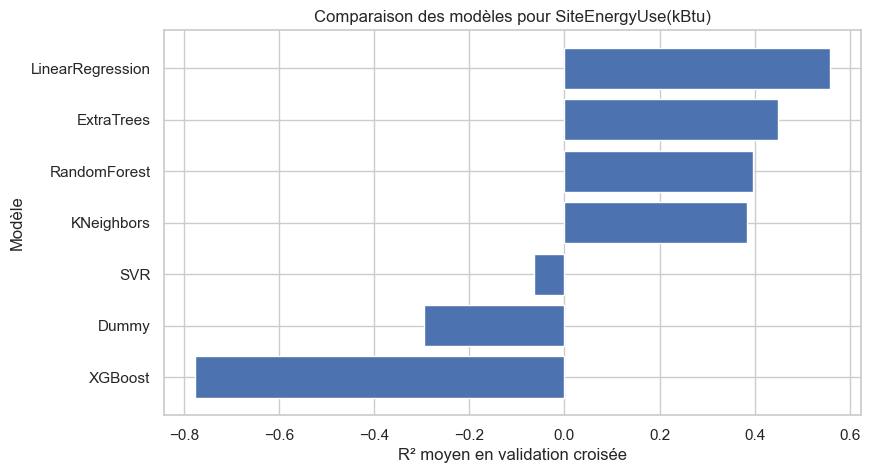

In [115]:
plt.figure(figsize=(9, 5))
plt.barh(
    energy_results["Modèle"],
    energy_results["CV_R2_moyen"]
)
plt.title("Comparaison des modèles pour SiteEnergyUse(kBtu)")
plt.xlabel("R² moyen en validation croisée")
plt.ylabel("Modèle")
plt.gca().invert_yaxis()  # meilleur modèle en haut
plt.show()

**Interprétation :**

La visualisation des scores \(R^2\) confirme clairement la hiérarchie observée dans le tableau précédent.

`LinearRegression` apparaît comme le modèle le plus performant sur la cible brute `SiteEnergyUse(kBtu)`, suivi par `ExtraTrees`, `RandomForest` puis `KNeighbors`, qui restent tous au-dessus de zéro et donc meilleurs qu’une approche naïve.

En revanche, `SVR` obtient un score légèrement négatif, ce qui traduit des performances insuffisantes dans cette configuration. La baseline `Dummy` reste naturellement faible, tandis que `XGBoost` se distingue par des résultats particulièrement mauvais sur la cible brute.

Cette première comparaison montre donc que, sans transformation de la cible, un modèle simple comme `LinearRegression` constitue déjà une base solide pour prédire `SiteEnergyUse(kBtu)`, alors que les modèles plus complexes ne sont pas systématiquement meilleurs.

### 15.4. Le logarithme de la cible est-il utile ?

Comme la variable `SiteEnergyUse(kBtu)` présente une forte asymétrie, nous testons ici l’effet d’une transformation logarithmique de la cible.

L’objectif est de vérifier si les performances des modèles s’améliorent lorsque l’apprentissage est réalisé sur `log1p(SiteEnergyUse(kBtu))`.

In [116]:
y_energy_log = np.log1p(y_energy)

energy_results_log = evaluate_regression_models(X, y_energy_log, cv=5)
energy_results_log.round(3)

,Modèle,CV_R2_moyen,CV_MAE_moyen,CV_RMSE_moyen
0,LinearRegression,0.674,0.459,0.629
1,XGBoost,0.659,0.469,0.644
2,RandomForest,0.643,0.481,0.661
3,SVR,0.635,0.485,0.667
4,ExtraTrees,0.629,0.489,0.672
5,KNeighbors,0.543,0.553,0.746
6,Dummy,-0.577,1.137,1.388


**Interprétation :**

La transformation logarithmique de `SiteEnergyUse(kBtu)` améliore nettement les performances de presque tous les modèles utiles.

Le meilleur score \(R^2\) est à nouveau obtenu par `LinearRegression` (**0.674**), mais il est désormais suivi de très près par `XGBoost` (**0.659**), `RandomForest` (**0.643**), `SVR` (**0.635**) et `ExtraTrees` (**0.629**). `KNeighbors` progresse également et atteint un score correct de **0.543**.

Cette amélioration globale confirme que la cible brute était fortement pénalisée par son asymétrie et par la présence de valeurs extrêmes. La transformation `log1p` rend donc le problème plus stable, plus régulier et plus favorable à l’apprentissage, y compris pour des modèles qui échouaient auparavant sur la cible brute.

Le cas de `SVR` et surtout de `XGBoost` est particulièrement révélateur : tous deux étaient peu performants, voire très mauvais, sur la cible brute, mais deviennent ici parmi les meilleurs modèles après transformation. Cela montre que leur apprentissage était fortement perturbé par l’échelle initiale de la variable cible.

La transformation logarithmique apparaît donc très pertinente pour la modélisation de `SiteEnergyUse(kBtu)`.

In [117]:
# comparaison directe

comparison_energy_log = pd.DataFrame({
    "Sans log (R2)": energy_results.set_index("Modèle")["CV_R2_moyen"],
    "Avec log (R2)": energy_results_log.set_index("Modèle")["CV_R2_moyen"]
}).sort_values(by="Sans log (R2)", ascending=False)

comparison_energy_log.round(3)

,Sans log (R2),Avec log (R2)
Modèle,,
LinearRegression,0.558,0.674
ExtraTrees,0.450,0.629
RandomForest,0.397,0.643
KNeighbors,0.383,0.543
SVR,-0.064,0.635
Dummy,-0.296,-0.577
XGBoost,-0.776,0.659


**Interprétation :**

La comparaison directe des scores \(R^2\) avant et après transformation logarithmique montre que `log1p(SiteEnergyUse(kBtu))` améliore les performances de tous les modèles prédictifs, à l’exception de la baseline `Dummy`, qui reste négative.

L’amélioration est modérée pour `LinearRegression`, qui passe de **0.558** à **0.674**, mais elle est beaucoup plus marquée pour plusieurs modèles non linéaires. `ExtraTrees` progresse de **0.450** à **0.629**, `RandomForest` de **0.397** à **0.643**, et `KNeighbors` de **0.383** à **0.543**.

Les gains les plus spectaculaires concernent `SVR` et `XGBoost`. `SVR` passe d’un score négatif (**-0.064**) à un score élevé (**0.635**), tandis que `XGBoost` passe de **-0.776** à **0.659**. Cela confirme que ces modèles étaient particulièrement sensibles à l’asymétrie et aux valeurs extrêmes présentes dans la cible brute.

Cette comparaison justifie donc clairement l’usage de `log1p(SiteEnergyUse(kBtu))` dans la suite de la modélisation. La transformation logarithmique ne se contente pas d’améliorer légèrement les résultats : elle modifie profondément les conditions d’apprentissage et permet à plusieurs modèles de révéler leur potentiel prédictif.

**Conclusion :**

La comparaison des modèles supervisés sur `SiteEnergyUse(kBtu)` montre d’abord que les variables explicatives retenues permettent d’obtenir des performances prédictives significativement supérieures à une baseline naïve.

Sur la cible brute, `LinearRegression` obtient les meilleurs résultats, devant `ExtraTrees`, `RandomForest` et `KNeighbors`. Cela indique qu’une structure linéaire explique déjà une partie importante de la variabilité de la consommation énergétique.

Cependant, la transformation logarithmique de la cible améliore nettement la qualité prédictive de l’ensemble des modèles utiles. Après transformation, `LinearRegression` reste le meilleur modèle (**R² = 0.674**), mais il est désormais talonné par `XGBoost`, `RandomForest`, `SVR` et `ExtraTrees`, qui atteignent eux aussi des niveaux de performance élevés.

Ces résultats montrent que la modélisation de `SiteEnergyUse(kBtu)` gagne fortement à être réalisée sur la cible transformée `log1p(SiteEnergyUse(kBtu))`. La transformation logarithmique réduit l’effet de l’asymétrie et des valeurs extrêmes, stabilise le problème d’apprentissage et rend les modèles plus performants et plus comparables.

## 16. Comparaison de plusieurs modèles supervisés — prédiction de `TotalGHGEmissions`

Nous appliquons maintenant la même démarche à la seconde cible du projet : `TotalGHGEmissions`.

L’objectif est de comparer plusieurs modèles de régression afin d’identifier ceux qui prédisent le mieux les émissions de CO₂ à partir des variables explicatives retenues.

### 16.1. Évaluation des modèles sur `TotalGHGEmissions`

Nous commençons par tester les mêmes modèles que précédemment sur la cible brute `TotalGHGEmissions`, afin de comparer leurs performances moyennes en validation croisée.

In [118]:
ghg_results = evaluate_regression_models(X, y_ghg, cv=5)
ghg_results.round(3)

,Modèle,CV_R2_moyen,CV_MAE_moyen,CV_RMSE_moyen
0,ExtraTrees,0.482,127.527,429.288
1,KNeighbors,0.368,144.083,528.687
2,RandomForest,0.349,149.695,518.250
3,XGBoost,0.121,146.698,522.678
4,LinearRegression,0.108,221.131,606.399
5,SVR,0.042,153.462,665.185
6,Dummy,-0.123,237.926,688.665


**Interprétation :**

Sur la cible brute `TotalGHGEmissions`, plusieurs modèles obtiennent des performances supérieures à la baseline `Dummy`, ce qui montre que les variables explicatives contiennent bien une information utile pour prédire les émissions de CO₂.

Le meilleur score \(R^2\) est obtenu par `ExtraTrees` (**0.482**), devant `KNeighbors` (**0.368**) et `RandomForest` (**0.349**). Cela suggère que, sur la cible brute, les relations entre variables explicatives et émissions de CO₂ sont mieux captées par des modèles flexibles ou non paramétriques que par un modèle strictement linéaire.

`XGBoost` obtient un score positif mais plus modeste (**0.121**), tout comme `LinearRegression` (**0.108**) et `SVR` (**0.042**), qui restent au-dessus de la baseline sans pour autant rivaliser avec les meilleurs modèles. La baseline `Dummy`, quant à elle, reste négative (**-0.123**), ce qui confirme que les modèles précédents exploitent bien une structure prédictive réelle.

Les métriques MAE et RMSE confirment globalement ce classement : `ExtraTrees` est le modèle le plus performant sur la cible brute, tandis que `KNeighbors` et `RandomForest` constituent également des candidats solides à ce stade.

### 16.2. Visualisation comparative des performances

Nous représentons les scores `R²` moyens obtenus sur `TotalGHGEmissions` afin de comparer visuellement les performances des différents modèles.

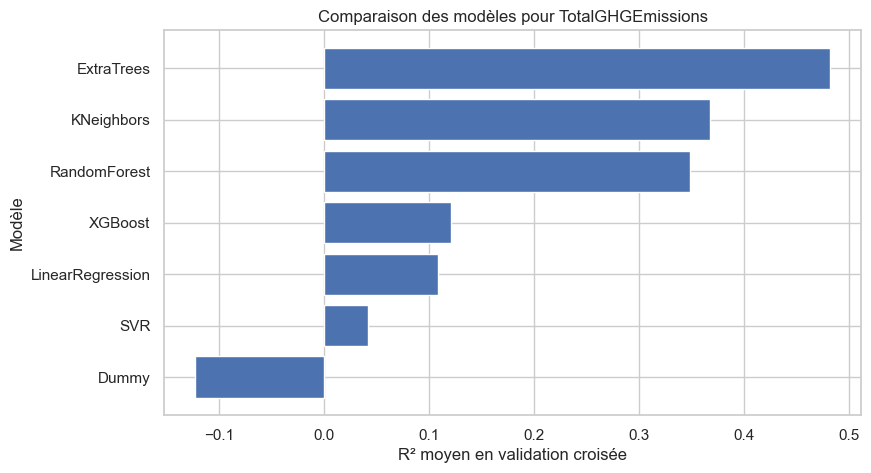

In [120]:
plt.figure(figsize=(9, 5))
plt.barh(
    ghg_results["Modèle"],
    ghg_results["CV_R2_moyen"]
)
plt.title("Comparaison des modèles pour TotalGHGEmissions")
plt.xlabel("R² moyen en validation croisée")
plt.ylabel("Modèle")
plt.gca().invert_yaxis()  # meilleur modèle en haut
plt.show()

**Interprétation :**

La visualisation des scores \(R^2\) confirme clairement la hiérarchie observée dans le tableau précédent.

`ExtraTrees` apparaît comme le modèle le plus performant sur la cible brute `TotalGHGEmissions`, suivi par `KNeighbors` puis `RandomForest`. Ces trois modèles se détachent nettement des autres et montrent qu’une approche non linéaire ou fondée sur des voisinages locaux semble mieux adaptée à la prédiction des émissions de CO₂ à l’échelle brute.

`XGBoost`, `LinearRegression` et `SVR` obtiennent des scores positifs mais plus faibles, ce qui indique qu’ils captent une partie de l’information sans atteindre le niveau des meilleurs modèles. La baseline `Dummy` reste négative, comme attendu.

Cette première comparaison montre donc que, contrairement à ce qui avait été observé pour `SiteEnergyUse(kBtu)` sur la cible brute, ce ne sont pas ici les modèles linéaires qui dominent, mais plutôt les approches plus flexibles.

### 16.3. Le logarithme de la cible est-il utile ?

Comme `TotalGHGEmissions` présente également une forte asymétrie, nous testons ici l’effet d’une transformation logarithmique de la cible.

L’objectif est de vérifier si les performances des modèles s’améliorent lorsque l’apprentissage est réalisé sur `log1p(TotalGHGEmissions)`.

In [121]:
y_ghg_log = np.log1p(y_ghg)

ghg_results_log = evaluate_regression_models(X, y_ghg_log, cv=5)
ghg_results_log.round(3)

,Modèle,CV_R2_moyen,CV_MAE_moyen,CV_RMSE_moyen
0,LinearRegression,0.466,0.764,0.957
1,XGBoost,0.432,0.782,0.988
2,RandomForest,0.417,0.792,1.001
3,SVR,0.390,0.792,1.023
4,ExtraTrees,0.378,0.808,1.032
5,KNeighbors,0.309,0.863,1.091
6,Dummy,-0.341,1.205,1.508


**Interprétation :**

Après transformation logarithmique de `TotalGHGEmissions`, la hiérarchie des modèles évolue sensiblement.

Le meilleur score \(R^2\) est désormais obtenu par `LinearRegression` (**0.466**), suivie de `XGBoost` (**0.432**), `RandomForest` (**0.417**), `SVR` (**0.390**) et `ExtraTrees` (**0.378**). `KNeighbors` reste correct avec un score de **0.309**, tandis que la baseline `Dummy` demeure négative (**-0.341**).

Ces résultats montrent que la transformation logarithmique rend le problème plus favorable à certains modèles, en particulier `LinearRegression`, `XGBoost` et `SVR`, qui progressent nettement par rapport à la cible brute. Cela suggère que l’asymétrie et les valeurs extrêmes de la variable initiale perturbaient fortement leur apprentissage.

En revanche, la transformation logarithmique ne bénéficie pas à tous les modèles de la même façon. `ExtraTrees` et `KNeighbors`, qui figuraient parmi les meilleurs sur la cible brute, voient ici leurs performances diminuer. La transformation modifie donc non seulement le niveau de performance, mais aussi la nature des modèles les mieux adaptés au problème.

Ainsi, le logarithme de `TotalGHGEmissions` stabilise visiblement l’apprentissage pour certains modèles, mais son intérêt est moins uniforme que pour `SiteEnergyUse(kBtu)`.

### 16.4. Comparaison directe avec et sans transformation logarithmique

Nous comparons maintenant, avec prudence, les scores obtenus sur la cible brute et sur la cible log-transformée, afin d’observer comment la transformation logarithmique modifie les performances relatives des modèles pour la prédiction des émissions de CO₂.

In [122]:
comparison_ghg_log = pd.DataFrame({
    "Sans log (R2)": ghg_results.set_index("Modèle")["CV_R2_moyen"],
    "Avec log (R2)": ghg_results_log.set_index("Modèle")["CV_R2_moyen"]
}).sort_values(by="Sans log (R2)", ascending=False)

comparison_ghg_log.round(3)

,Sans log (R2),Avec log (R2)
Modèle,,
ExtraTrees,0.482,0.378
KNeighbors,0.368,0.309
RandomForest,0.349,0.417
XGBoost,0.121,0.432
LinearRegression,0.108,0.466
SVR,0.042,0.390
Dummy,-0.123,-0.341


**Interprétation :**

La comparaison entre les résultats obtenus sur la cible brute et sur la cible log-transformée montre que l’effet du logarithme sur `TotalGHGEmissions` est contrasté selon les modèles.

La transformation logarithmique améliore nettement les performances de `LinearRegression`, qui passe de **0.108** à **0.466**, de `XGBoost`, qui progresse de **0.121** à **0.432**, de `SVR`, qui passe de **0.042** à **0.390**, ainsi que de `RandomForest`, qui s’améliore de **0.349** à **0.417**. Ces gains montrent que plusieurs modèles étaient pénalisés par l’asymétrie et les valeurs extrêmes de la cible brute.

En revanche, `ExtraTrees` et `KNeighbors` voient leurs performances diminuer après transformation : `ExtraTrees` passe de **0.482** à **0.378**, et `KNeighbors` de **0.368** à **0.309**. Cela indique que ces deux modèles exploitaient relativement bien la structure de la cible brute et ne bénéficient pas du même effet de stabilisation que les autres.

La transformation logarithmique ne constitue donc pas ici une amélioration universelle. Elle change la hiérarchie des modèles et favorise surtout les approches linéaires ou sensibles à la structure globale des données, alors que certains modèles plus locaux ou basés sur des ensembles d’arbres perdaient moins d’information sur la cible brute.

Ainsi, pour `TotalGHGEmissions`, l’intérêt du logarithme est réel, mais il dépend du modèle considéré. Il ne s’impose pas aussi clairement que pour `SiteEnergyUse(kBtu)`.

**Conclusion :**

La comparaison des modèles supervisés sur `TotalGHGEmissions` montre que les variables explicatives retenues permettent bien d’obtenir de meilleures performances qu’une baseline naïve.

Sur la cible brute, `ExtraTrees` est le modèle le plus performant, devant `KNeighbors` et `RandomForest`, ce qui suggère que la prédiction des émissions de CO₂ repose en partie sur des relations non linéaires ou locales.

Après transformation logarithmique, la hiérarchie change : `LinearRegression` devient le meilleur modèle, suivie de `XGBoost` et `RandomForest`. Cela montre que la transformation logarithmique rend la cible plus favorable à certains modèles en réduisant l’effet de l’asymétrie et des valeurs extrêmes.

Cependant, contrairement à ce qui avait été observé pour `SiteEnergyUse(kBtu)`, la transformation logarithmique n’améliore pas tous les modèles. `ExtraTrees` et `KNeighbors`, notamment, obtiennent de meilleurs résultats sur la cible brute.

Ces résultats montrent donc que, pour `TotalGHGEmissions`, le choix entre cible brute et cible transformée doit être guidé par le modèle retenu. Le logarithme est utile pour plusieurs approches, mais il ne constitue pas ici un choix aussi évident et universel que pour la consommation énergétique.

## 17. Modèle multi-output

Après avoir évalué séparément plusieurs modèles pour chacune des deux cibles, nous testons maintenant une approche multi-output.

L’objectif est de construire un modèle unique capable de prédire simultanément :

- `SiteEnergyUse(kBtu)`
- `TotalGHGEmissions`

Cette démarche permet de vérifier si une modélisation conjointe des deux sorties est pertinente, ce qui répond directement au problème posé.

### 17.1. Définition d’une fonction d’évaluation multi-output

Afin de comparer plusieurs modèles capables de prédire simultanément les deux cibles, nous définissons une fonction d’évaluation spécifique au cadre multi-output.

Cette fonction :

- construit un pipeline complet ;
- applique le prétraitement adapté à chaque modèle ;
- effectue une validation croisée ;
- et calcule des métriques de performance globales sur l’ensemble des sorties.

Les modèles testés incluent une baseline, un modèle linéaire, des modèles d’arbres, un modèle de voisinage et un modèle à noyau.

In [123]:
def evaluate_multioutput_models(X, y, cv=5):
    results = []

    models = {
        "Dummy": Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", DummyRegressor(strategy="mean"))
        ]),

        "LinearRegression": Pipeline(steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", LinearRegression())
        ]),

        "RandomForest": Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "ExtraTrees": Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", ExtraTreesRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "KNeighbors": Pipeline(steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", KNeighborsRegressor(
                n_neighbors=8,
                weights="distance"
            ))
        ]),

        "SVR": Pipeline(steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", MultiOutputRegressor(
                SVR(
                    kernel="rbf",
                    C=10,
                    epsilon=0.1
                )
            ))
        ])
    }

    if XGBOOST_AVAILABLE:
        models["XGBoost"] = Pipeline(steps=[
            ("preprocessor", preprocessor_unscaled),
            ("model", MultiOutputRegressor(
                XGBRegressor(
                    n_estimators=200,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    random_state=42,
                    n_jobs=-1
                )
            ))
        ])

    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    }

    for model_name, pipeline in models.items():
        cv_results = cross_validate(
            pipeline,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        results.append({
            "Modèle": model_name,
            "CV_R2_moyen": cv_results["test_r2"].mean(),
            "CV_MAE_moyen": -cv_results["test_mae"].mean(),
            "CV_RMSE_moyen": -cv_results["test_rmse"].mean()
        })

    return pd.DataFrame(results).sort_values(by="CV_R2_moyen", ascending=False).reset_index(drop=True)

### 17.2. Évaluation des modèles multi-output sur les cibles brutes

Nous commençons par comparer plusieurs modèles multi-output sur les deux cibles dans leur forme brute :

- `SiteEnergyUse(kBtu)`
- `TotalGHGEmissions`

L’objectif est de voir si un modèle unique peut obtenir des performances satisfaisantes sur les deux sorties simultanément.

In [124]:
multi_results = evaluate_multioutput_models(X, y_multi, cv=5)
multi_results.round(3)

,Modèle,CV_R2_moyen,CV_MAE_moyen,CV_RMSE_moyen
0,ExtraTrees,0.469,2126291.111,9.799895e+06
1,RandomForest,0.386,2430242.440,1.036725e+07
2,KNeighbors,0.376,2467211.033,1.055370e+07
3,LinearRegression,0.333,2949763.809,6.928174e+06
4,SVR,-0.011,3913313.077,1.353914e+07
5,Dummy,-0.209,5153338.738,1.372718e+07
6,XGBoost,-0.328,2518585.338,1.162733e+07


**Interprétation :**

Sur les deux cibles brutes prises simultanément, plusieurs modèles multi-output obtiennent des performances supérieures à la baseline `Dummy`, ce qui montre qu’un apprentissage conjoint de `SiteEnergyUse(kBtu)` et de `TotalGHGEmissions` est bien possible.

Le meilleur score \(R^2\) moyen est obtenu par `ExtraTrees` (**0.469**), devant `RandomForest` (**0.386**), `KNeighbors` (**0.376**) et `LinearRegression` (**0.333**). Cela indique que, dans le cadre multi-output sur les cibles brutes, les approches flexibles fondées sur des arbres ou sur la proximité locale capturent mieux la structure conjointe des deux variables que les modèles plus simples.

`SVR` obtient un score légèrement négatif (**-0.011**), ce qui signifie qu’il ne parvient pas ici à dépasser une prédiction naïve de manière satisfaisante. `XGBoost` présente même un score plus faible encore (**-0.328**), ce qui montre qu’il n’est pas adapté dans cette configuration sur les cibles brutes. La baseline `Dummy`, quant à elle, reste négative (**-0.209**), comme attendu.

Dans l’ensemble, ces résultats montrent qu’un modèle multi-output peut déjà fournir des performances correctes sur les variables brutes, mais que tous les algorithmes ne sont pas également capables d’exploiter ce cadre conjoint.

### 17.3. Visualisation comparative des performances multi-output

Nous représentons les scores `R²` moyens obtenus en validation croisée afin de comparer visuellement les différents modèles multi-output testés.

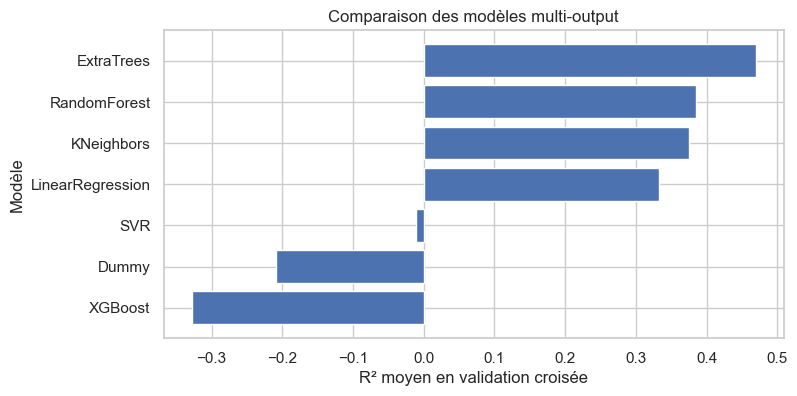

In [125]:
plt.figure(figsize=(8, 4))
plt.barh(
    multi_results["Modèle"],
    multi_results["CV_R2_moyen"]
)
plt.title("Comparaison des modèles multi-output")
plt.xlabel("R² moyen en validation croisée")
plt.ylabel("Modèle")
plt.gca().invert_yaxis()  
plt.show()

**Interprétation :**

La visualisation des scores \(R^2\) confirme la hiérarchie observée dans le tableau précédent.

`ExtraTrees` apparaît comme le modèle multi-output le plus performant sur les cibles brutes, suivi par `RandomForest`, `KNeighbors` et `LinearRegression`, qui obtiennent tous des scores positifs. Ces résultats montrent que plusieurs approches sont capables de prédire simultanément les deux sorties avec une qualité raisonnable.

En revanche, `SVR` reste légèrement en dessous de zéro, ce qui traduit une performance insuffisante dans cette configuration. La baseline `Dummy` demeure négative, tandis que `XGBoost` obtient ici les résultats les plus faibles parmi les modèles testés.

Cette première comparaison montre donc que, sur les cibles brutes, les modèles d’arbres restent les plus efficaces dans le cadre multi-output, alors que les modèles plus sensibles à l’échelle ou à la structure de la cible semblent davantage pénalisés.

### 17.4. Le logarithme des deux cibles est-il utile en multi-output ?

Comme les deux variables cibles présentent une forte asymétrie, nous testons également une version multi-output sur les cibles transformées par `log1p`.

L’objectif est de vérifier si cette transformation améliore les performances globales d’un modèle unique prédisisant simultanément l’énergie et les émissions de CO₂.

In [126]:
y_multi_log = np.log1p(y_multi)

multi_results_log = evaluate_multioutput_models(X, y_multi_log, cv=5)
multi_results_log.round(3)

,Modèle,CV_R2_moyen,CV_MAE_moyen,CV_RMSE_moyen
0,LinearRegression,0.570,0.612,0.793
1,XGBoost,0.545,0.625,0.816
2,RandomForest,0.523,0.642,0.837
3,SVR,0.512,0.638,0.845
4,ExtraTrees,0.507,0.650,0.850
5,KNeighbors,0.426,0.708,0.918
6,Dummy,-0.459,1.171,1.448


**Interprétation :**

La transformation logarithmique simultanée des deux cibles améliore nettement les performances de l’ensemble des modèles utiles dans le cadre multi-output.

Le meilleur score \(R^2\) moyen est désormais obtenu par `LinearRegression` (**0.570**), suivie de `XGBoost` (**0.545**), `RandomForest` (**0.523**), `SVR` (**0.512**) et `ExtraTrees` (**0.507**). `KNeighbors` progresse également et atteint un score correct de **0.426**, tandis que la baseline `Dummy` reste négative (**-0.459**).

Ces résultats montrent que la transformation `log1p` rend le problème multi-output beaucoup plus stable et plus favorable à l’apprentissage. Les modèles qui étaient faibles ou négatifs sur les cibles brutes, en particulier `SVR` et `XGBoost`, deviennent ici parmi les meilleurs. Cela confirme que l’asymétrie et les valeurs extrêmes des variables initiales perturbaient fortement leur capacité d’apprentissage.

La hiérarchie des modèles évolue également : alors que `ExtraTrees` dominait sur les cibles brutes, c’est désormais `LinearRegression` qui obtient le meilleur résultat moyen, ce qui suggère que la structure conjointe des deux cibles devient plus régulière et plus proche d’un comportement linéaire après transformation logarithmique.

Ainsi, dans le cadre multi-output, la transformation logarithmique des deux cibles apparaît particulièrement bénéfique.

### 17.5. Comparaison directe avec et sans transformation logarithmique

Nous comparons maintenant les scores `R²` obtenus en multi-output sur les cibles brutes et sur les cibles log-transformées, afin d’évaluer l’intérêt global du logarithme dans ce cadre.

In [127]:
comparison_multi_log = pd.DataFrame({
    "Sans log (R2)": multi_results.set_index("Modèle")["CV_R2_moyen"],
    "Avec log (R2)": multi_results_log.set_index("Modèle")["CV_R2_moyen"]
}).sort_values(by="Sans log (R2)", ascending=False)

comparison_multi_log.round(3)

,Sans log (R2),Avec log (R2)
Modèle,,
ExtraTrees,0.469,0.507
RandomForest,0.386,0.523
KNeighbors,0.376,0.426
LinearRegression,0.333,0.570
SVR,-0.011,0.512
Dummy,-0.209,-0.459
XGBoost,-0.328,0.545


**Interprétation :**

La comparaison directe entre les scores obtenus sur les cibles brutes et sur les cibles log-transformées montre que la transformation logarithmique améliore nettement les performances de tous les modèles prédictifs en multi-output, à l’exception de la baseline `Dummy`, qui reste négative.

L’amélioration est visible pour les modèles déjà performants sur les cibles brutes : `ExtraTrees` passe de **0.469** à **0.507**, `RandomForest` de **0.386** à **0.523**, `KNeighbors` de **0.376** à **0.426**, et `LinearRegression` de **0.333** à **0.570**.

Les gains les plus spectaculaires concernent `SVR` et `XGBoost`. `SVR` passe d’un score légèrement négatif (**-0.011**) à un score élevé (**0.512**), tandis que `XGBoost` progresse de **-0.328** à **0.545**. Ces évolutions montrent que ces modèles étaient fortement pénalisés par l’asymétrie et les valeurs extrêmes présentes dans les cibles brutes.

Cette comparaison indique donc que, dans le cadre multi-output, la transformation logarithmique améliore non seulement le niveau global de performance, mais aussi la robustesse de la comparaison entre modèles. Elle rend les deux cibles plus homogènes et facilite leur apprentissage conjoint.

**Conclusion :**

L’évaluation des modèles multi-output montre qu’il est possible de prédire simultanément `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` avec des performances satisfaisantes.

Sur les cibles brutes, `ExtraTrees` obtient le meilleur score moyen, devant `RandomForest`, `KNeighbors` et `LinearRegression`. Cela montre que les modèles d’arbres sont capables d’exploiter efficacement la structure conjointe des deux variables dans leur échelle initiale.

Après transformation logarithmique des deux cibles, les performances progressent nettement pour l’ensemble des modèles utiles. `LinearRegression` devient alors le meilleur modèle (**R² = 0.570**), suivie de `XGBoost`, `RandomForest`, `SVR` et `ExtraTrees`, tous à un niveau relativement proche.

Ces résultats confirment que la transformation logarithmique est particulièrement bénéfique dans le cadre multi-output. Elle réduit l’effet de l’asymétrie et des valeurs extrêmes, stabilise l’apprentissage et permet à plusieurs modèles de mieux exploiter l’information commune portée par les deux cibles.

Ainsi, si l’objectif est de construire un modèle unique prédisant simultanément la consommation énergétique et les émissions de CO₂, la stratégie la plus pertinente parmi celles testées consiste à travailler sur les cibles transformées par `log1p`.

### Comparaison de différents modèles supervisés

**FAIT**

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

## 18. Optimisation du meilleur modèle pour `SiteEnergyUse(kBtu)`

D’après la comparaison précédente, le meilleur modèle obtenu pour la prédiction de `SiteEnergyUse(kBtu)` est `LinearRegression` appliquée à la cible transformée `log1p(SiteEnergyUse(kBtu))`.

Nous cherchons maintenant à améliorer ou à confirmer cette performance à l’aide d’une recherche d’hyperparamètres de petite taille. Comme `LinearRegression` ne fait pas partie de la famille des modèles à arbres, nous utiliserons ensuite la méthode de `Permutation Importance` pour identifier les variables les plus influentes.

### 18.1. Définition du pipeline à optimiser

Nous construisons un pipeline complet avec :

- le prétraitement adapté aux variables numériques et catégorielles ;
- un modèle `LinearRegression` ;
- puis une petite grille de paramètres permettant de tester plusieurs variantes du pipeline.

In [128]:
linear_energy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", LinearRegression())
])

### 18.2. Définition d’une grille d’hyperparamètres raisonnable

Nous utilisons une grille volontairement limitée afin de respecter la consigne tout en gardant un coût de calcul faible. Les paramètres testés portent à la fois sur le modèle linéaire et sur une partie du prétraitement.

In [129]:
param_grid_linear_energy = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "model__fit_intercept": [True, False],
    "model__positive": [False, True]
}

### 18.3. Recherche d’hyperparamètres par validation croisée

Nous lançons maintenant une `GridSearchCV` afin d’identifier la meilleure combinaison de paramètres pour `LinearRegression` sur `log1p(SiteEnergyUse(kBtu))`.

In [130]:
grid_linear_energy = GridSearchCV(
    estimator=linear_energy_pipeline,
    param_grid=param_grid_linear_energy,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_linear_energy.fit(X, y_energy_log)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['PropertyGFATotal',
                                                                          'NumberofFloors',
                                                                          'ENERGYSTARScore',
                                                                          'LargestPropertyUseTypeGFA',
                                                                          'BuildingAge',
                                                                          'GFA_per_floor',
                                                                          'LogPropertyGFATotal',
                                                                          'LogLargestPropertyUseTyp...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['PrimaryPropertyType',
                                                                          'Neighborhood',
                                                                          'BuildingType'])])),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'model__fit_intercept': [True, False],
                         'model__positive': [False, True],
                         'preprocessor__num__imputer__strategy': ['mean',
                                                                  'median']},
             scoring='r2', verbose=1)

**Interprétation :**

La recherche d’hyperparamètres a été réalisée sur une grille de petite taille, comportant **8 combinaisons** évaluées par validation croisée à **5 folds**, soit **40 entraînements** au total.

Cette stratégie reste volontairement simple, ce qui est cohérent avec le choix de `LinearRegression`, un modèle peu paramétrique. L’objectif ici n’était pas de transformer profondément le modèle, mais de vérifier si quelques réglages du pipeline — à la fois sur le modèle et sur le prétraitement — pouvaient encore apporter un gain mesurable sur `log1p(SiteEnergyUse(kBtu))`.

La recherche est donc bien adaptée à la consigne : elle explore plusieurs variantes raisonnables tout en gardant un coût de calcul faible.

### 18.4. Meilleure configuration trouvée

Nous affichons maintenant les meilleurs paramètres trouvés par la recherche, ainsi que le meilleur score moyen obtenu en validation croisée.

In [131]:
print("Meilleurs paramètres :", grid_linear_energy.best_params_)
print("Meilleur score CV (R2) :", grid_linear_energy.best_score_)

Meilleurs paramètres : {'model__fit_intercept': True, 'model__positive': False, 'preprocessor__num__imputer__strategy': 'mean'}
Meilleur score CV (R2) : 0.6768732437879649


**Interprétation :**

La meilleure configuration trouvée correspond aux paramètres suivants :

- `fit_intercept = True`
- `positive = False`
- `preprocessor__num__imputer__strategy = "mean"`

Le meilleur score moyen obtenu en validation croisée est de **0.6769**.

Ce résultat est très cohérent avec la nature du problème. Le fait de conserver `fit_intercept=True` indique qu’un terme constant reste utile pour modéliser correctement la cible. Le paramètre `positive=False` montre qu’imposer des coefficients strictement positifs n’améliore pas les performances : le modèle a donc besoin de conserver toute sa liberté d’ajustement. Enfin, la stratégie d’imputation par la moyenne (`mean`) apparaît ici légèrement plus favorable que l’imputation par la médiane.

Dans l’ensemble, cette meilleure configuration confirme que le pipeline initial était déjà bien adapté, et que les meilleurs réglages restent proches des choix par défaut.

### 18.5. Comparaison avant / après optimisation

Nous comparons maintenant les performances de `LinearRegression` dans sa version initiale avec celles de la meilleure version obtenue après recherche d’hyperparamètres.

In [132]:
linear_default_r2 = energy_results_log.loc[
    energy_results_log["Modèle"] == "LinearRegression", "CV_R2_moyen"
].values[0]

comparison_linear_energy = pd.DataFrame({
    "Version": ["LinearRegression par défaut", "LinearRegression optimisée"],
    "CV_R2_moyen": [
        linear_default_r2,
        grid_linear_energy.best_score_
    ]
})

comparison_linear_energy

,Version,CV_R2_moyen
0,LinearRegression par défaut,0.673770
1,LinearRegression optimisée,0.676873


**Interprétation :**

La comparaison avant / après optimisation montre que `LinearRegression` passe d’un score \(R^2\) moyen de **0.6738** à **0.6769** après recherche d’hyperparamètres.

Le gain observé est donc faible, de l’ordre de **0.0031 point de \(R^2\)**. Cette amélioration reste réelle, mais elle demeure marginale. Cela signifie que `LinearRegression` était déjà très proche de sa meilleure configuration dans la version utilisée précédemment.

Autrement dit, la GridSearch ne révèle pas ici un changement majeur de performance, mais elle permet de confirmer de manière rigoureuse que le modèle linéaire retenu est déjà quasiment optimal dans ce cadre.

### 18.6. Visualisation du gain d’optimisation

Nous représentons visuellement le score \(R^2\) moyen obtenu avant et après optimisation, afin d’évaluer si la recherche d’hyperparamètres apporte un gain réel.

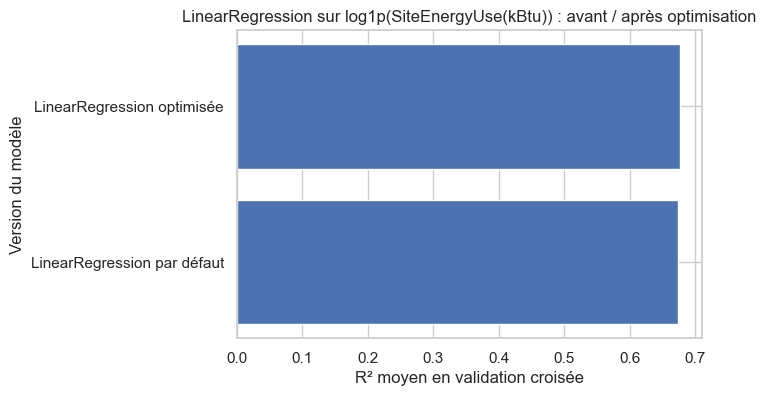

In [133]:
plt.figure(figsize=(6, 4))
plt.barh(
    comparison_linear_energy["Version"],
    comparison_linear_energy["CV_R2_moyen"]
)
plt.title("LinearRegression sur log1p(SiteEnergyUse(kBtu)) : avant / après optimisation")
plt.xlabel("R² moyen en validation croisée")
plt.ylabel("Version du modèle")
plt.show()

**Interprétation :**

La visualisation avant / après optimisation confirme que la recherche d’hyperparamètres n’apporte qu’un gain très limité sur `LinearRegression` pour la prédiction de `log1p(SiteEnergyUse(kBtu))`.

Les deux barres sont presque de même longueur, ce qui traduit visuellement la faible différence entre le modèle par défaut et le modèle optimisé. Cette observation est cohérente avec les résultats numériques : l’amélioration existe, mais elle reste marginale.

Cette étape reste néanmoins utile, car elle permet de valider que le meilleur modèle observé précédemment n’était pas dû à un simple hasard de paramétrage et qu’il conserve sa pertinence après vérification.

### 18.7. Importance des variables par permutation

Comme `LinearRegression` n’appartient pas à la famille des modèles à arbres, nous utilisons la méthode de `Permutation Importance` pour identifier les variables les plus influentes dans la prédiction de `log1p(SiteEnergyUse(kBtu))`.

Cette méthode mesure la baisse de performance du modèle lorsque les valeurs d’une variable sont mélangées aléatoirement.

In [134]:
from sklearn.inspection import permutation_importance

best_linear_energy = grid_linear_energy.best_estimator_
best_linear_energy.fit(X, y_energy_log)

perm_importance_energy = permutation_importance(
    best_linear_energy,
    X,
    y_energy_log,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df_energy = pd.DataFrame({
    "Variable": X.columns,
    "Importance_moyenne": perm_importance_energy.importances_mean,
    "Importance_ecart_type": perm_importance_energy.importances_std
}).sort_values(by="Importance_moyenne", ascending=False)

importance_df_energy.head(15)

,Variable,Importance_moyenne,Importance_ecart_type
6,LogPropertyGFATotal,0.665079,0.026465
8,PrimaryPropertyType,0.256170,0.013035
2,ENERGYSTARScore,0.101294,0.006055
7,LogLargestPropertyUseTypeGFA,0.080872,0.006351
0,PropertyGFATotal,0.063710,0.004839
3,LargestPropertyUseTypeGFA,0.050274,0.003909
10,BuildingType,0.010646,0.001187
9,Neighborhood,0.004272,0.000904
1,NumberofFloors,0.000776,0.000528
4,BuildingAge,0.000428,0.000373


**Interprétation :**

Comme `LinearRegression` ne fait pas partie de la famille des modèles à arbres, l’importance des variables a été étudiée à l’aide de la **Permutation Importance**.

Les résultats montrent très clairement que **`LogPropertyGFATotal`** est de loin la variable la plus influente sur la prédiction de `log1p(SiteEnergyUse(kBtu))`, avec une importance moyenne d’environ **0.665**. Cela signifie que lorsqu’on perturbe cette variable, les performances du modèle se dégradent fortement. Cette domination est cohérente sur le plan métier : la surface totale du bâtiment, exprimée ici sous forme logarithmique, constitue un facteur central de la consommation énergétique.

La deuxième variable la plus importante est **`PrimaryPropertyType`** (**0.256**), ce qui montre que la nature fonctionnelle du bâtiment joue également un rôle majeur. Tous les bâtiments ne consomment pas l’énergie de la même façon selon qu’il s’agit, par exemple, de bureaux, d’hôtels, d’écoles ou de commerces.

Viennent ensuite **`ENERGYSTARScore`** (**0.101**) et **`LogLargestPropertyUseTypeGFA`** (**0.081**), qui apportent aussi une contribution significative. Le score ENERGY STAR semble donc contenir une information utile sur l’efficacité énergétique, tandis que la surface du principal usage du bâtiment reste logiquement liée à la consommation.

À un niveau plus secondaire, on retrouve **`PropertyGFATotal`**, **`LargestPropertyUseTypeGFA`** et **`BuildingType`**, dont l’influence est positive mais nettement plus faible. En revanche, des variables comme **`Neighborhood`**, **`NumberofFloors`**, **`BuildingAge`** ou **`GFA_per_floor`** semblent avoir un impact limité dans ce modèle précis.

Dans l’ensemble, cette analyse montre que la prédiction de `SiteEnergyUse(kBtu)` repose avant tout sur des variables de **taille**, de **type d’usage** et, dans une moindre mesure, de **performance énergétique**.

### 18.8. Visualisation des variables les plus importantes

Nous représentons les variables les plus influentes selon la permutation importance.

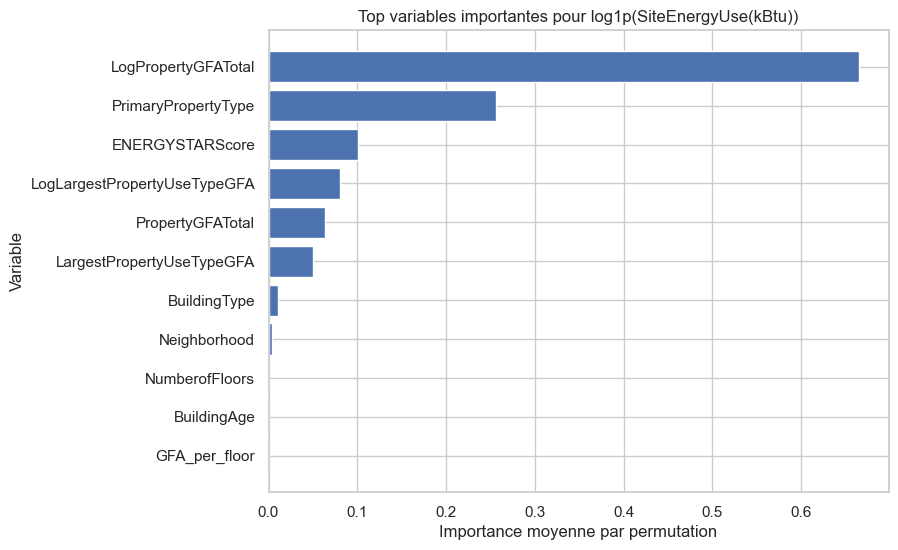

In [136]:
top_n = 15
top_features_energy = importance_df_energy.head(top_n).sort_values(by="Importance_moyenne", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features_energy["Variable"],
    top_features_energy["Importance_moyenne"]
)
plt.title("Top variables importantes pour log1p(SiteEnergyUse(kBtu))")
plt.xlabel("Importance moyenne par permutation")
plt.ylabel("Variable")
plt.show()

**Interprétation :**

Le graphique confirme visuellement la domination de `LogPropertyGFATotal`, très nettement devant toutes les autres variables. `PrimaryPropertyType` occupe également une place importante, tandis que les variables restantes jouent un rôle plus secondaire.

La hiérarchie des importances reste cohérente avec l’intuition métier : la consommation énergétique dépend d’abord de la taille du bâtiment et de son usage principal.

**Conclusion :**

L’optimisation de `LinearRegression` sur `log1p(SiteEnergyUse(kBtu))` confirme que ce modèle constitue un excellent choix pour cette cible.

La GridSearch met en évidence une légère amélioration des performances, avec un score \(R^2\) moyen qui passe de **0.6738** à **0.6769**. Ce gain reste faible, ce qui montre surtout que le modèle était déjà très bien configuré avant optimisation.

L’analyse par permutation importance complète utilement cette étape en montrant que les variables les plus déterminantes sont principalement liées à la **taille du bâtiment** (`LogPropertyGFATotal`, `PropertyGFATotal`, `LogLargestPropertyUseTypeGFA`) et à son **usage** (`PrimaryPropertyType`), avec une contribution notable de `ENERGYSTARScore`.

Ainsi, pour `SiteEnergyUse(kBtu)`, le meilleur modèle retenu reste `LinearRegression` appliquée à la cible transformée `log1p`, et son comportement apparaît à la fois performant, stable et interprétable.

## 19. Optimisation du meilleur modèle pour `TotalGHGEmissions`

D’après la comparaison précédente, le meilleur modèle obtenu pour la prédiction de `TotalGHGEmissions` est `ExtraTreesRegressor` appliqué à la cible brute.

Nous cherchons maintenant à améliorer ou à confirmer cette performance à l’aide d’une recherche d’hyperparamètres de petite taille. Comme `ExtraTreesRegressor` appartient à la famille des modèles à arbres, nous utiliserons ensuite la fonctionnalité de **feature importance** afin d’identifier les variables les plus influentes dans la prédiction des émissions de CO₂.

### 19.1. Définition du pipeline à optimiser

Nous construisons un pipeline complet avec :

- le prétraitement adapté aux variables numériques et catégorielles ;
- un modèle `ExtraTreesRegressor` ;
- puis une grille de paramètres raisonnable pour rechercher une meilleure configuration.

In [137]:
extra_trees_ghg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_unscaled),
    ("model", ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

### 19.2. Définition d’une grille d’hyperparamètres raisonnable

Nous utilisons ici une grille volontairement limitée afin de garder un temps de calcul raisonnable, tout en testant plusieurs réglages utiles du modèle.

In [138]:
param_grid_extra_trees_ghg = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

### 19.3. Recherche d’hyperparamètres par validation croisée

Nous lançons maintenant une `GridSearchCV` afin d’identifier la meilleure combinaison d’hyperparamètres pour `ExtraTreesRegressor` sur la cible `TotalGHGEmissions`.

In [140]:
grid_extra_trees_ghg = GridSearchCV(
    estimator=extra_trees_ghg_pipeline,
    param_grid=param_grid_extra_trees_ghg,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_extra_trees_ghg.fit(X, y_ghg)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['PropertyGFATotal',
                                                                          'NumberofFloors',
                                                                          'ENERGYSTARScore',
                                                                          'LargestPropertyUseTypeGFA',
                                                                          'BuildingAge',
                                                                          'GFA_per_floor',
                                                                          'LogPropertyGFATotal',
                                                                          'LogLargestPropertyUseTypeGFA']),
                                                                        ('cat',
                                                                         Pipeline(step...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['PrimaryPropertyType',
                                                                          'Neighborhood',
                                                                          'BuildingType'])])),
                                       ('model',
                                        ExtraTreesRegressor(n_jobs=-1,
                                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2', verbose=1)

**Interprétation :**

La recherche d’hyperparamètres a été réalisée sur une grille de taille raisonnable, comportant **48 combinaisons** évaluées par validation croisée à **5 folds**, soit **240 entraînements** au total.

Cette stratégie permet d’explorer plusieurs réglages importants de `ExtraTreesRegressor` tout en gardant un coût de calcul maîtrisé. Les paramètres testés portent sur le nombre d’arbres, leur profondeur maximale, les contraintes de découpage (`min_samples_split`, `min_samples_leaf`) ainsi que le nombre de variables considérées à chaque séparation (`max_features`).

La démarche respecte donc pleinement la consigne : elle reprend le meilleur modèle sécurisé précédemment et cherche à l’améliorer via une GridSearch de petite taille, mais suffisamment riche pour tester plusieurs configurations pertinentes.

### 19.4. Meilleure configuration trouvée

Nous affichons maintenant les meilleurs hyperparamètres trouvés par la recherche, ainsi que le meilleur score moyen obtenu en validation croisée.

In [141]:
print("Meilleurs paramètres :", grid_extra_trees_ghg.best_params_)
print("Meilleur score CV (R2) :", grid_extra_trees_ghg.best_score_)

Meilleurs paramètres : {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Meilleur score CV (R2) : 0.6136374756032016


**Interprétation :**

La meilleure configuration trouvée est la suivante :

- `max_depth = None`
- `max_features = "log2"`
- `min_samples_leaf = 1`
- `min_samples_split = 2`
- `n_estimators = 100`

Le meilleur score moyen obtenu en validation croisée est de **0.6136**.

Cette configuration conserve un modèle relativement flexible : les arbres ne sont pas limités en profondeur (`max_depth=None`) et les contraintes sur les divisions restent faibles (`min_samples_split=2`, `min_samples_leaf=1`). En revanche, le choix de `max_features="log2"` montre que le modèle gagne en robustesse en ne considérant qu’un sous-ensemble restreint de variables à chaque séparation. Enfin, le fait que **100 arbres** suffisent indique qu’une forêt de taille modérée permet déjà d’obtenir d’excellentes performances.

Dans l’ensemble, ces hyperparamètres suggèrent que la prédiction de `TotalGHGEmissions` bénéficie d’un modèle suffisamment souple pour capturer des relations complexes, tout en limitant une partie du risque de surapprentissage grâce à une sélection plus restrictive des variables à chaque nœud.

### 19.5. Comparaison avant / après optimisation

Nous comparons maintenant les performances de `ExtraTreesRegressor` dans sa version initiale avec celles de la meilleure version obtenue après recherche d’hyperparamètres.

In [142]:
extra_trees_default_r2_ghg = ghg_results.loc[
    ghg_results["Modèle"] == "ExtraTrees", "CV_R2_moyen"
].values[0]

comparison_extra_trees_ghg = pd.DataFrame({
    "Version": ["ExtraTrees par défaut", "ExtraTrees optimisé"],
    "CV_R2_moyen": [
        extra_trees_default_r2_ghg,
        grid_extra_trees_ghg.best_score_
    ]
})

comparison_extra_trees_ghg

,Version,CV_R2_moyen
0,ExtraTrees par défaut,0.481687
1,ExtraTrees optimisé,0.613637


**Interprétation :**

La comparaison avant / après optimisation montre que `ExtraTreesRegressor` passe d’un score \(R^2\) moyen de **0.4817** à **0.6136** après recherche d’hyperparamètres.

Le gain observé est donc d’environ **0.132 point de \(R^2\)**, ce qui constitue une amélioration nette et significative. Contrairement à ce qui avait été observé pour `LinearRegression` sur `SiteEnergyUse(kBtu)`, l’optimisation ne se contente pas ici de confirmer un bon réglage initial : elle apporte une progression réelle des performances du modèle.

Cela signifie que `ExtraTreesRegressor` disposait encore d’une marge d’amélioration importante sur `TotalGHGEmissions`, et que les paramètres par défaut n’étaient pas les plus adaptés à cette cible.

### 19.6. Visualisation du gain d’optimisation

Nous représentons visuellement le score \(R^2\) moyen obtenu avant et après optimisation, afin d’évaluer si la recherche d’hyperparamètres apporte un gain réel.

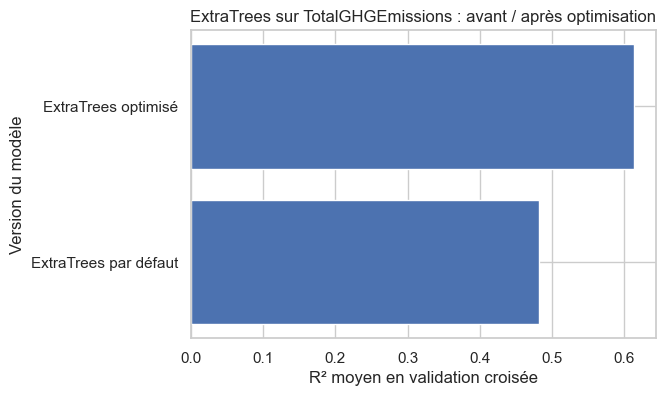

In [143]:
plt.figure(figsize=(6, 4))
plt.barh(
    comparison_extra_trees_ghg["Version"],
    comparison_extra_trees_ghg["CV_R2_moyen"]
)
plt.title("ExtraTrees sur TotalGHGEmissions : avant / après optimisation")
plt.xlabel("R² moyen en validation croisée")
plt.ylabel("Version du modèle")
plt.show()

**Interprétation :**

La visualisation avant / après optimisation confirme clairement que la recherche d’hyperparamètres améliore les performances de `ExtraTreesRegressor` sur `TotalGHGEmissions`.

L’écart entre les deux barres est visuellement marqué, ce qui traduit bien le gain déjà observé numériquement. Le modèle optimisé se situe nettement au-dessus du modèle par défaut, ce qui renforce l’idée que la phase d’optimisation a apporté une amélioration concrète et utile.

Cette étape valide donc pleinement l’intérêt d’une recherche d’hyperparamètres sur le meilleur modèle sécurisé pour cette cible.

### 19.7. Importance des variables du modèle optimisé

Comme `ExtraTreesRegressor` appartient à la famille des modèles à arbres, nous utilisons ici la fonctionnalité de **feature importance** pour identifier les variables les plus influentes dans la prédiction de `TotalGHGEmissions`.

In [144]:
best_extra_trees_ghg = grid_extra_trees_ghg.best_estimator_
best_extra_trees_ghg.fit(X, y_ghg)

# Récupération du préprocesseur et du modèle
preprocessor_fitted = best_extra_trees_ghg.named_steps["preprocessor"]
model_fitted = best_extra_trees_ghg.named_steps["model"]

# Noms des variables après transformation
feature_names_ghg = preprocessor_fitted.get_feature_names_out()

# Importances
importance_df_ghg = pd.DataFrame({
    "Variable": feature_names_ghg,
    "Importance": model_fitted.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df_ghg.head(15)

,Variable,Importance
9,cat__PrimaryPropertyType_Hospital,0.164242
3,num__LargestPropertyUseTypeGFA,0.139082
0,num__PropertyGFATotal,0.099591
7,num__LogLargestPropertyUseTypeGFA,0.082078
2,num__ENERGYSTARScore,0.075325
6,num__LogPropertyGFATotal,0.072039
16,cat__PrimaryPropertyType_Mixed Use Property,0.049717
48,cat__BuildingType_Campus,0.046481
5,num__GFA_per_floor,0.043853
4,num__BuildingAge,0.034821


**Interprétation :**

L’analyse des `feature importances` permet d’identifier les variables qui contribuent le plus aux prédictions du modèle `ExtraTreesRegressor` optimisé.

La variable la plus importante est **`cat__PrimaryPropertyType_Hospital`** avec une importance d’environ **0.164**. Cela indique que le fait d’appartenir à la catégorie *Hospital* joue un rôle particulièrement marqué dans l’estimation des émissions de CO₂. Ce résultat est cohérent sur le plan métier : les hôpitaux sont des bâtiments très spécifiques, souvent très énergivores et fortement émetteurs.

Viennent ensuite plusieurs variables liées à la **taille** et à la **structure d’usage** du bâtiment :  
- **`num__LargestPropertyUseTypeGFA`** (**0.139**)  
- **`num__PropertyGFATotal`** (**0.100**)  
- **`num__LogLargestPropertyUseTypeGFA`** (**0.082**)  
- **`num__LogPropertyGFATotal`** (**0.072**)

Ces résultats montrent que la surface totale du bâtiment et la surface associée à son usage principal jouent un rôle central dans la prédiction des émissions de CO₂.

On retrouve également **`num__ENERGYSTARScore`** (**0.075**), qui apparaît comme une variable importante. Cela suggère que le niveau d’efficacité énergétique du bâtiment influence aussi sensiblement les émissions observées.

D’autres variables catégorielles ressortent également, comme **`cat__PrimaryPropertyType_Mixed Use Property`**, **`cat__BuildingType_Campus`**, ou encore certains quartiers tels que **`cat__Neighborhood_EAST`** et **`cat__Neighborhood_DOWNTOWN`**. Leur contribution est plus modérée, mais elle montre que le contexte d’usage et de localisation apporte une information complémentaire utile au modèle.

Dans l’ensemble, cette analyse met en évidence une combinaison de facteurs liés :
- à la **nature du bâtiment**,
- à sa **taille**,
- à son **usage principal**,
- et, dans une moindre mesure, à sa **localisation**.

### 19.8. Visualisation des variables les plus importantes

Nous représentons maintenant les variables les plus importantes selon `ExtraTreesRegressor`.

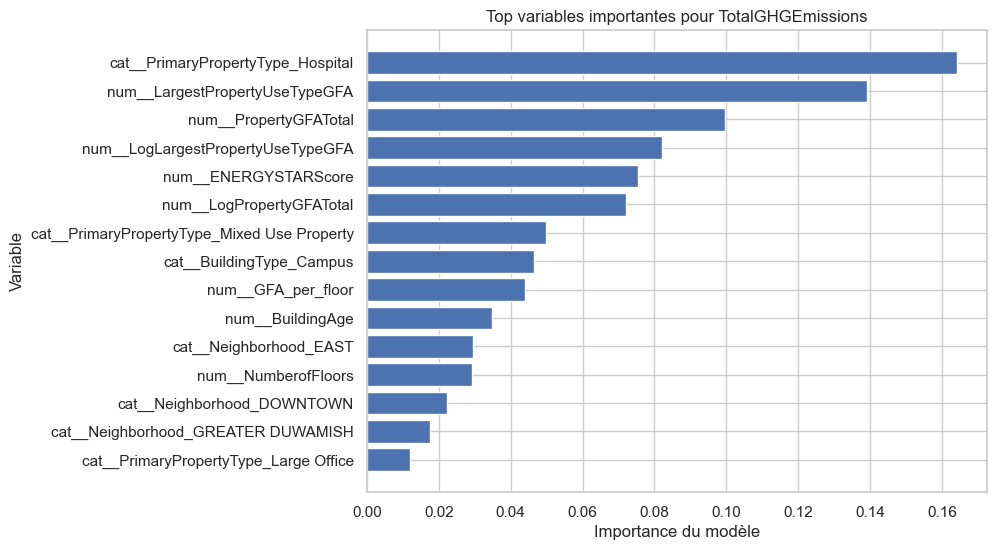

In [145]:
top_n = 15
top_features_ghg = importance_df_ghg.head(top_n).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features_ghg["Variable"],
    top_features_ghg["Importance"]
)
plt.title("Top variables importantes pour TotalGHGEmissions")
plt.xlabel("Importance du modèle")
plt.ylabel("Variable")
plt.show()

**Interprétation :**

Le graphique confirme visuellement la domination de quelques variables dans le fonctionnement du modèle.

La catégorie **Hospital** se détache nettement comme la variable la plus importante, devant plusieurs mesures de surface comme `LargestPropertyUseTypeGFA` et `PropertyGFATotal`. Les variables liées à la taille du bâtiment et à son usage principal occupent donc une place centrale dans la prédiction de `TotalGHGEmissions`.

Les autres variables importantes, comme `ENERGYSTARScore`, `BuildingAge`, `Neighborhood` ou certaines catégories de type de propriété, jouent un rôle complémentaire mais plus secondaire. La hiérarchie observée reste cohérente avec l’intuition métier : les émissions de CO₂ dépendent fortement du type de bâtiment, de son gabarit et de la manière dont ses surfaces sont utilisées.

**Conclusion :**

L’optimisation de `ExtraTreesRegressor` sur `TotalGHGEmissions` conduit à une amélioration nette des performances, avec un score \(R^2\) moyen qui passe de **0.4817** à **0.6136**.

Cette progression confirme que `ExtraTreesRegressor` constituait un très bon candidat à optimiser et que la recherche d’hyperparamètres apporte ici un gain réel, bien plus marqué que dans le cas de `LinearRegression` sur `SiteEnergyUse(kBtu)`.

L’analyse des `feature importances` montre par ailleurs que les variables les plus influentes sont principalement liées :
- au **type de bâtiment**,
- à la **taille totale du bâtiment**,
- à la **surface associée à l’usage principal**,
- et à certaines caractéristiques de **performance énergétique** ou de **localisation**.

Ainsi, pour `TotalGHGEmissions`, le modèle final retenu peut être décrit comme un `ExtraTreesRegressor` optimisé, performant et capable de mettre en évidence des facteurs explicatifs cohérents avec l’intuition métier.

On observe donc deux situations différentes : pour `SiteEnergyUse(kBtu)`, l’optimisation confirme surtout la robustesse du modèle retenu, tandis que pour `TotalGHGEmissions`, elle permet un gain de performance substantiel.

## 20. Optimisation du meilleur modèle multi-output

D’après la comparaison précédente, le meilleur modèle obtenu dans le cadre multi-output est `LinearRegression` appliquée aux deux cibles transformées par `log1p`.

Nous cherchons maintenant à vérifier si ce modèle peut encore être légèrement amélioré à l’aide d’une recherche d’hyperparamètres de petite taille. Comme `LinearRegression` n’appartient pas à la famille des modèles à arbres, nous utiliserons ensuite la méthode de **Permutation Importance** pour identifier les variables les plus influentes sur la performance globale du modèle.

### 20.1. Définition du pipeline à optimiser

Nous construisons un pipeline complet avec :

- le prétraitement adapté aux variables numériques et catégorielles ;
- un modèle `LinearRegression` ;
- puis une petite grille de paramètres permettant de tester plusieurs variantes raisonnables du pipeline.

In [146]:
linear_multi_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", LinearRegression())
])

### 20.2. Définition d’une grille d’hyperparamètres raisonnable

Nous utilisons ici une grille volontairement réduite afin de respecter la consigne tout en gardant un coût de calcul faible. Les paramètres testés portent à la fois sur le modèle linéaire et sur une partie du prétraitement.

In [147]:
param_grid_linear_multi = {
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "model__fit_intercept": [True, False],
    "model__positive": [False, True]
}

### 20.3. Recherche d’hyperparamètres par validation croisée

Nous lançons maintenant une `GridSearchCV` afin d’identifier la meilleure combinaison de paramètres pour `LinearRegression` dans le cadre multi-output sur les deux cibles transformées.

In [148]:
grid_linear_multi = GridSearchCV(
    estimator=linear_multi_pipeline,
    param_grid=param_grid_linear_multi,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_linear_multi.fit(X, y_multi_log)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['PropertyGFATotal',
                                                                          'NumberofFloors',
                                                                          'ENERGYSTARScore',
                                                                          'LargestPropertyUseTypeGFA',
                                                                          'BuildingAge',
                                                                          'GFA_per_floor',
                                                                          'LogPropertyGFATotal',
                                                                          'LogLargestPropertyUseTyp...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['PrimaryPropertyType',
                                                                          'Neighborhood',
                                                                          'BuildingType'])])),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'model__fit_intercept': [True, False],
                         'model__positive': [False, True],
                         'preprocessor__num__imputer__strategy': ['mean',
                                                                  'median']},
             scoring='r2', verbose=1)

**Interprétation :**

La recherche d’hyperparamètres a été menée sur une grille volontairement réduite, comportant **8 combinaisons** évaluées par validation croisée à **5 folds**, soit **40 entraînements** au total.

Cette stratégie est cohérente avec le choix de `LinearRegression`, un modèle peu paramétrique. L’objectif n’était pas ici de modifier profondément la nature du modèle, mais de vérifier si quelques réglages simples du pipeline — à la fois sur le prétraitement et sur le modèle — pouvaient encore améliorer les performances dans le cadre multi-output sur les deux cibles transformées.

La démarche respecte donc pleinement la consigne, tout en gardant un coût de calcul très raisonnable.

### 20.4. Meilleure configuration trouvée

Nous affichons maintenant les meilleurs paramètres trouvés par la recherche, ainsi que le meilleur score moyen obtenu en validation croisée.

In [149]:
print("Meilleurs paramètres :", grid_linear_multi.best_params_)
print("Meilleur score CV (R2) :", grid_linear_multi.best_score_)

Meilleurs paramètres : {'model__fit_intercept': True, 'model__positive': False, 'preprocessor__num__imputer__strategy': 'mean'}
Meilleur score CV (R2) : 0.5727570438399223


**Interprétation :**

La meilleure configuration trouvée correspond aux paramètres suivants :

- `fit_intercept = True`
- `positive = False`
- `preprocessor__num__imputer__strategy = "mean"`

Le meilleur score moyen obtenu en validation croisée est de **0.5728**.

Ce résultat est très proche de celui obtenu pour `SiteEnergyUse(kBtu)` seul, ce qui montre une certaine stabilité du modèle linéaire dans différents cadres de prédiction. Le paramètre `fit_intercept=True` indique qu’un terme constant reste utile pour modéliser correctement les deux cibles simultanément. Le choix `positive=False` montre qu’il n’est pas pertinent d’imposer des coefficients tous positifs, et l’imputation par la moyenne (`mean`) semble ici légèrement plus favorable que l’imputation par la médiane.

Dans l’ensemble, cette meilleure configuration confirme que le pipeline initial était déjà bien adapté au problème multi-output, et que les réglages optimaux restent très proches des choix par défaut.

### 20.5. Comparaison avant / après optimisation

Nous comparons maintenant les performances de `LinearRegression` dans sa version initiale avec celles de la meilleure version obtenue après recherche d’hyperparamètres.

In [150]:
linear_multi_default_r2 = multi_results_log.loc[
    multi_results_log["Modèle"] == "LinearRegression", "CV_R2_moyen"
].values[0]

comparison_linear_multi = pd.DataFrame({
    "Version": ["LinearRegression par défaut", "LinearRegression optimisée"],
    "CV_R2_moyen": [
        linear_multi_default_r2,
        grid_linear_multi.best_score_
    ]
})

comparison_linear_multi

,Version,CV_R2_moyen
0,LinearRegression par défaut,0.569844
1,LinearRegression optimisée,0.572757


**Interprétation :**

La comparaison avant / après optimisation montre que `LinearRegression` passe d’un score \(R^2\) moyen de **0.5698** à **0.5728** après recherche d’hyperparamètres.

Le gain observé est donc faible, de l’ordre de **0.0029 point de \(R^2\)**. Cette amélioration reste réelle, mais elle demeure marginale. Comme pour la cible énergétique seule, cela signifie que `LinearRegression` était déjà très proche de sa meilleure configuration dans sa version initiale.

Autrement dit, la GridSearch ne transforme pas ici les performances du modèle, mais elle permet de confirmer rigoureusement que le meilleur modèle multi-output retenu est déjà quasiment optimal dans ce cadre.

### 20.6. Visualisation du gain d’optimisation

Nous représentons visuellement le score \(R^2\) moyen obtenu avant et après optimisation, afin d’évaluer si la recherche d’hyperparamètres apporte un gain réel.

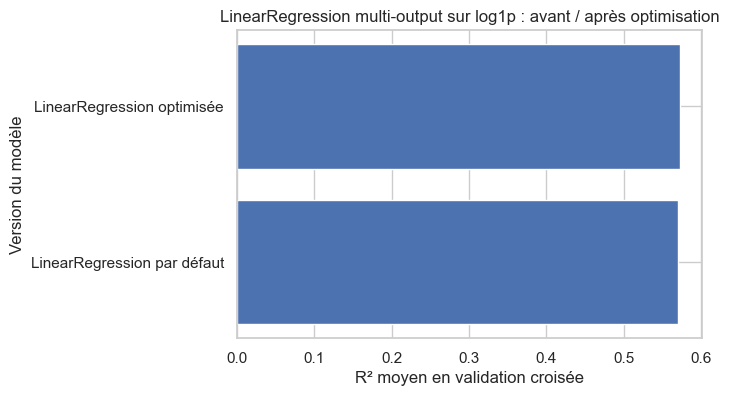

In [151]:
plt.figure(figsize=(6, 4))
plt.barh(
    comparison_linear_multi["Version"],
    comparison_linear_multi["CV_R2_moyen"]
)
plt.title("LinearRegression multi-output sur log1p : avant / après optimisation")
plt.xlabel("R² moyen en validation croisée")
plt.ylabel("Version du modèle")
plt.show()

**Interprétation :**

La visualisation avant / après optimisation confirme que la recherche d’hyperparamètres n’apporte qu’un gain très limité sur `LinearRegression` dans le cadre multi-output.

Les deux barres sont presque de même longueur, ce qui traduit visuellement la faible différence entre le modèle par défaut et le modèle optimisé. Cette observation est cohérente avec les résultats numériques : l’amélioration existe, mais elle reste marginale.

Cette étape reste néanmoins utile, car elle permet de valider que le bon niveau de performance du modèle multi-output n’est pas dû à un réglage accidentel, mais qu’il se maintient après vérification systématique.

### 20.7. Importance des variables par permutation

Comme `LinearRegression` n’appartient pas à la famille des modèles à arbres, nous utilisons la **Permutation Importance** pour identifier les variables les plus influentes sur la performance globale du modèle multi-output.

Cette méthode mesure la baisse de performance lorsque les valeurs d’une variable sont mélangées aléatoirement, toutes choses égales par ailleurs.

In [152]:
best_linear_multi = grid_linear_multi.best_estimator_
best_linear_multi.fit(X, y_multi_log)

perm_importance_multi = permutation_importance(
    best_linear_multi,
    X,
    y_multi_log,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df_multi = pd.DataFrame({
    "Variable": X.columns,
    "Importance_moyenne": perm_importance_multi.importances_mean,
    "Importance_ecart_type": perm_importance_multi.importances_std
}).sort_values(by="Importance_moyenne", ascending=False)

importance_df_multi.head(15)

,Variable,Importance_moyenne,Importance_ecart_type
6,LogPropertyGFATotal,0.583321,0.023076
8,PrimaryPropertyType,0.273748,0.016571
2,ENERGYSTARScore,0.086153,0.005971
0,PropertyGFATotal,0.071546,0.005568
7,LogLargestPropertyUseTypeGFA,0.064531,0.005488
3,LargestPropertyUseTypeGFA,0.057687,0.004349
10,BuildingType,0.014754,0.001392
9,Neighborhood,0.007748,0.000931
4,BuildingAge,0.002682,0.000639
5,GFA_per_floor,0.000548,0.000246


**Interprétation :**

Comme `LinearRegression` n’appartient pas à la famille des modèles à arbres, l’importance des variables a été étudiée à l’aide de la **Permutation Importance**.

Les résultats montrent très clairement que **`LogPropertyGFATotal`** est la variable la plus influente sur la performance globale du modèle multi-output, avec une importance moyenne d’environ **0.583**. Cela signifie que la perturbation de cette variable dégrade fortement la capacité du modèle à prédire conjointement la consommation énergétique et les émissions de CO₂. Ce résultat est cohérent sur le plan métier : la taille totale du bâtiment constitue un déterminant central pour les deux cibles.

La deuxième variable la plus importante est **`PrimaryPropertyType`** (**0.274**), ce qui montre que la nature fonctionnelle du bâtiment influence fortement la prédiction simultanée des deux sorties. Le type de bâtiment joue donc un rôle structurant, aussi bien pour l’énergie consommée que pour les émissions générées.

Viennent ensuite **`ENERGYSTARScore`** (**0.086**), **`PropertyGFATotal`** (**0.072**), **`LogLargestPropertyUseTypeGFA`** (**0.065**) et **`LargestPropertyUseTypeGFA`** (**0.058**). Ces variables apportent une contribution significative, mais plus secondaire. Elles confirment que la performance énergétique et la structure d’usage du bâtiment jouent un rôle complémentaire dans la modélisation conjointe des deux cibles.

En revanche, des variables comme **`BuildingType`**, **`Neighborhood`**, **`BuildingAge`**, **`GFA_per_floor`** ou **`NumberofFloors`** présentent des importances beaucoup plus faibles. Leur contribution existe, mais elle reste limitée dans ce modèle précis.

Dans l’ensemble, cette analyse montre que la prédiction conjointe de `SiteEnergyUse(kBtu)` et de `TotalGHGEmissions` repose principalement sur des variables de **taille**, de **type d’usage** et, dans une moindre mesure, de **performance énergétique**.

### 20.8. Visualisation des variables les plus importantes

Nous représentons les variables les plus influentes selon la permutation importance dans le cadre du modèle multi-output.

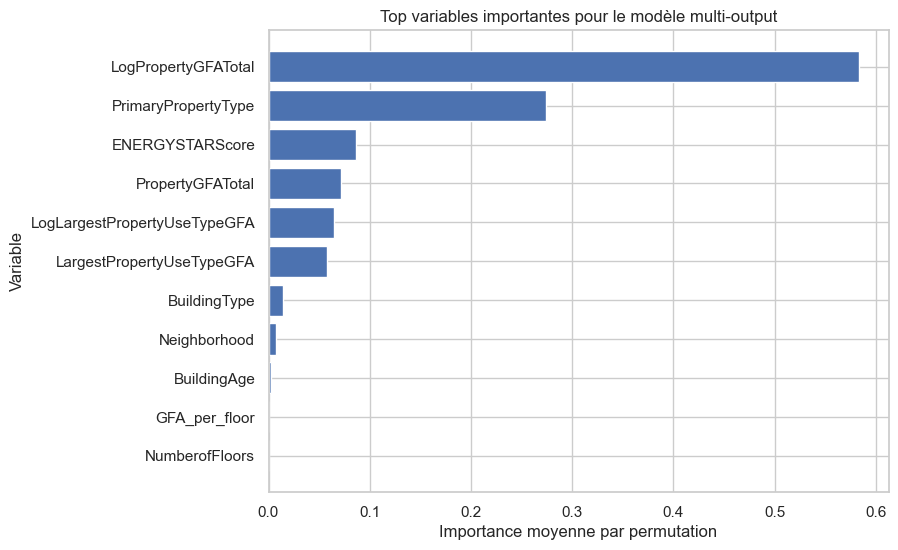

In [153]:
top_n = 15
top_features_multi = importance_df_multi.head(top_n).sort_values(by="Importance_moyenne", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features_multi["Variable"],
    top_features_multi["Importance_moyenne"]
)
plt.title("Top variables importantes pour le modèle multi-output")
plt.xlabel("Importance moyenne par permutation")
plt.ylabel("Variable")
plt.show()

**Interprétation :**

Le graphique confirme visuellement la domination de `LogPropertyGFATotal`, très nettement devant toutes les autres variables. `PrimaryPropertyType` occupe également une place importante, tandis que les variables restantes jouent un rôle plus secondaire.

La hiérarchie des importances reste cohérente avec l’intuition métier : lorsqu’on cherche à prédire simultanément la consommation énergétique et les émissions de CO₂, la taille du bâtiment et son usage principal apparaissent comme les facteurs les plus structurants.

**Conclusion :**

L’optimisation de `LinearRegression` dans le cadre multi-output confirme que ce modèle constitue un très bon choix pour la prédiction conjointe de `SiteEnergyUse(kBtu)` et de `TotalGHGEmissions` après transformation logarithmique.

La GridSearch met en évidence une légère amélioration des performances, avec un score \(R^2\) moyen qui passe de **0.5698** à **0.5728**. Ce gain reste faible, ce qui montre surtout que le modèle était déjà très bien configuré avant optimisation.

L’analyse par permutation importance complète utilement cette étape en montrant que les variables les plus déterminantes sont principalement liées à la **taille du bâtiment** (`LogPropertyGFATotal`, `PropertyGFATotal`, `LogLargestPropertyUseTypeGFA`) et à son **usage** (`PrimaryPropertyType`), avec une contribution notable de `ENERGYSTARScore`.

Ainsi, dans le cadre multi-output, le modèle final retenu reste `LinearRegression` appliquée aux deux cibles transformées par `log1p`, avec un comportement à la fois performant, stable et interprétable.

Ainsi, l’objectif initial du projet est atteint : il est possible de prédire de manière satisfaisante la consommation énergétique et les émissions de CO₂ à partir des caractéristiques structurelles et fonctionnelles des bâtiments.

## 21. Conclusion générale

Ce projet avait pour objectif de prédire deux indicateurs environnementaux majeurs pour les bâtiments non résidentiels de Seattle :

- la consommation énergétique totale (`SiteEnergyUse(kBtu)`) ;
- les émissions totales de CO₂ (`TotalGHGEmissions`).

Pour répondre à ce problème, nous avons suivi une démarche complète de data science, allant du nettoyage des données à l’évaluation puis à l’optimisation de plusieurs modèles supervisés. Le travail réalisé a notamment inclus :

- la sélection d’un périmètre cohérent de bâtiments non résidentiels ;
- le traitement des valeurs incohérentes ou atypiques ;
- une analyse exploratoire univariée et bivariée ;
- la création de nouvelles variables par *feature engineering* ;
- l’étude des corrélations ;
- la comparaison de plusieurs modèles de régression ;
- l’analyse de l’effet de la transformation logarithmique des cibles ;
- l’étude d’un cadre multi-output ;
- puis l’optimisation ciblée des meilleurs modèles retenus.

### Principaux enseignements sur les deux cibles

L’analyse exploratoire a montré que `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` présentent des caractéristiques statistiques très proches : distributions fortement asymétriques à droite, présence de nombreuses valeurs extrêmes et forte dispersion. Ces observations ont justifié l’étude systématique d’une transformation logarithmique des cibles.

Pour `SiteEnergyUse(kBtu)`, les résultats ont montré que le meilleur modèle parmi ceux testés est `LinearRegression` appliquée à la cible transformée `log1p(SiteEnergyUse(kBtu))`. Ce résultat est particulièrement intéressant, car il suggère qu’une fois l’asymétrie réduite, une structure globalement linéaire permet déjà de capturer une part importante de la variabilité de la consommation énergétique. L’optimisation de ce modèle n’apporte qu’un gain marginal, ce qui confirme que la configuration initiale était déjà très proche de l’optimum.

Pour `TotalGHGEmissions`, la situation est plus nuancée. Le meilleur score global observé est obtenu avec `ExtraTreesRegressor` sur la cible brute. Contrairement au cas précédent, l’optimisation par `GridSearchCV` améliore ici nettement les performances du modèle, avec un score \(R^2\) moyen passant d’environ **0.482** à **0.614**. Ce résultat montre qu’un modèle à arbres flexible est particulièrement bien adapté à la prédiction des émissions de CO₂ dans leur échelle initiale.

### Apport de la transformation logarithmique

L’un des résultats les plus importants du projet concerne l’effet de la transformation logarithmique.

Pour `SiteEnergyUse(kBtu)`, cette transformation améliore nettement les performances de tous les modèles prédictifs utiles. Elle réduit l’effet des très grandes consommations, stabilise le problème d’apprentissage et rend les modèles plus performants, plus comparables et plus robustes.

Pour `TotalGHGEmissions`, l’effet du logarithme est plus contrasté. Certains modèles, comme `LinearRegression`, `XGBoost`, `SVR` ou `RandomForest`, en bénéficient clairement, tandis que d’autres, comme `ExtraTrees` et `KNeighbors`, obtiennent de meilleurs résultats sur la cible brute. Le logarithme reste donc utile, mais son intérêt dépend davantage du modèle considéré.

Dans le cadre multi-output, la transformation logarithmique des deux cibles se révèle en revanche très bénéfique. Elle améliore les performances de tous les modèles prédictifs utiles testés, et permet à `LinearRegression` de devenir le meilleur modèle conjoint.

### Intérêt de la modélisation multi-output

La modélisation multi-output constituait une étape importante du projet, car les deux cibles étudiées sont fortement liées sur le plan métier. Un bâtiment très consommateur d’énergie a en général aussi tendance à être plus émetteur de CO₂.

Les résultats montrent qu’un modèle unique peut effectivement prédire simultanément `SiteEnergyUse(kBtu)` et `TotalGHGEmissions` avec des performances satisfaisantes. Sur les cibles brutes, `ExtraTrees` obtient les meilleurs résultats. Après transformation logarithmique des deux sorties, `LinearRegression` devient le meilleur modèle multi-output, avec un score moyen supérieur à celui observé avant transformation.

Cette approche conjointe apparaît donc pertinente, car elle répond directement au problème posé tout en confirmant que les deux variables partagent une structure commune exploitable par les modèles.

### Interprétation des variables importantes

L’analyse des importances de variables apporte également des enseignements utiles.

Pour la consommation énergétique, la permutation importance montre que les variables les plus influentes sont principalement liées à la **taille du bâtiment** (`LogPropertyGFATotal`, `PropertyGFATotal`, `LogLargestPropertyUseTypeGFA`) et à son **usage** (`PrimaryPropertyType`), avec une contribution notable de `ENERGYSTARScore`.

Pour les émissions de CO₂, l’analyse des `feature importances` du modèle `ExtraTreesRegressor` optimisé met en évidence le rôle majeur :
- de certaines catégories de type de propriété, notamment **Hospital** ;
- des surfaces liées au bâtiment et à son usage principal ;
- ainsi que de certaines variables de performance énergétique et de contexte.

Ces résultats sont cohérents avec l’intuition métier : la consommation énergétique et les émissions dépendent d’abord de la nature du bâtiment, de son gabarit et de la manière dont ses surfaces sont utilisées.

### Bilan global des modèles retenus

À l’issue du projet, les modèles les plus pertinents à retenir sont donc :

- pour `SiteEnergyUse(kBtu)` : **`LinearRegression` sur `log1p(SiteEnergyUse(kBtu))`** ;
- pour `TotalGHGEmissions` : **`ExtraTreesRegressor` optimisé sur la cible brute** ;
- pour une approche conjointe : **`LinearRegression` multi-output sur les deux cibles transformées par `log1p`**.

Ce résultat est intéressant car il montre qu’il n’existe pas un seul modèle universellement meilleur dans tous les cas : le choix dépend de la cible, de son échelle et du cadre de modélisation retenu.

### Limites du travail

Ce projet présente néanmoins plusieurs limites.

Certaines variables, comme `ENERGYSTARScore`, comportent un nombre important de valeurs manquantes. Par ailleurs, plusieurs variables explicatives restent fortement corrélées entre elles, ce qui soulève la question de la redondance d’information. Les performances des modèles dépendent aussi fortement du choix de la transformation de la cible, ce qui rappelle que la qualité prédictive observée reste sensible au cadre de modélisation adopté.

Enfin, les mesures d’importance de variables ne doivent pas être interprétées comme des relations causales. Elles renseignent sur le rôle prédictif des features dans les modèles testés, mais non sur un lien de causalité direct.

### Pistes d’amélioration

Plusieurs prolongements pourraient être envisagés pour aller plus loin :

- affiner la sélection de variables afin de limiter les redondances ;
- approfondir l’optimisation d’autres modèles, notamment en multi-output ;
- tester d’autres méthodes d’interprétation, comme les valeurs de Shapley ;
- explorer des modèles supplémentaires ou des approches d’ensemble ;
- enrichir le jeu de données avec des variables contextuelles complémentaires si elles deviennent disponibles.

### Conclusion finale

En définitive, ce projet a permis de construire des modèles prédictifs cohérents pour deux indicateurs environnementaux importants des bâtiments non résidentiels de Seattle. Il a également mis en évidence l’importance du prétraitement, du choix de l’échelle de travail et de la comparaison rigoureuse entre plusieurs familles de modèles.

Au-delà des performances obtenues, le projet montre surtout qu’une démarche méthodique — combinant analyse exploratoire, transformation raisonnée des variables, comparaison de modèles, optimisation ciblée et interprétation — permet d’aboutir à des résultats à la fois utiles, robustes et compréhensibles.

### Optimisation et interprétation du modèle                                                                 

**FAIT**

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.